In [ ]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
from Bio import SeqIO
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request  # Добавлено для скачивания файла
from scipy.sparse import csr_matrix, vstack

# --- Параметры ---
DATA_DIR = 'data'
# Обновляем путь: файл будет лежать внутри папки data
GENOME_FASTA_PATH = os.path.join(DATA_DIR, 'U00096.3.fasta')
CSV_FILE_PATH = os.path.join(DATA_DIR, 'mmc4.csv')

UPSTREAM_WINDOW_SIZE = 500
RANDOM_STATE = 42
N_SPLITS_CV = 5

# --- 0. Подготовка окружения и скачивание данных ---
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    print(f"Создана директория: {DATA_DIR}")

def download_genome_if_needed(filepath):
    """
    Скачивает референсный геном E. coli K-12 (U00096.3) из NCBI,
    если файл не найден по указанному пути.
    """
    if not os.path.exists(filepath):
        print(f"Файл генома не найден: {filepath}")
        print("Начинаю скачивание E. coli str. K-12 substr. MG1655 (U00096.3) из NCBI...")
        
        # URL API NCBI для скачивания полного генома в формате FASTA
        url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=U00096.3&rettype=fasta&retmode=text"
        
        try:
            urllib.request.urlretrieve(url, filepath)
            print(f"Геном успешно скачан и сохранен в: {filepath}")
        except Exception as e:
            print(f"ОШИБКА при скачивании генома: {e}")
            exit()
    else:
        print(f"Файл генома уже существует: {filepath}")

# Запуск проверки и скачивания
download_genome_if_needed(GENOME_FASTA_PATH)

# --- 1. Загрузка и подготовка данных (CSV) ---
try:
    df = pd.read_csv(CSV_FILE_PATH)
    if 'Unnamed: 0' in df.columns:
        df = df.rename(columns={'Unnamed: 0': 'original_index'})
except FileNotFoundError:
    print(f"Ошибка: Файл данных CSV не найден по пути {CSV_FILE_PATH}")
    print("Убедитесь, что файл mmc4.csv находится в папке data.")
    exit()
except Exception as e:
    print(f"Произошла ошибка при загрузке CSV: {e}")
    exit()

# Удалим строки с пропущенными значениями в целевой переменной
df.dropna(subset=['Avrg_500_med_win_propensity'], inplace=True)

# Удалим столбцы, которые могут вызвать утечку данных
columns_to_drop = ['raw_propensity1', 'raw_propensity2', '500_med_win_propensity1', '500_med_win_propensity2']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

df.reset_index(drop=True, inplace=True)

print(f"Загружено {len(df)} строк из CSV.")
print("Первые 5 строк данных:")
print(df.head())
print("\nИнформация о DataFrame:")
df.info()

# --- 2. Загрузка референсного генома ---
genome_sequence = None
genome_load_success = False
try:
    with open(GENOME_FASTA_PATH, "r") as handle:
        genome_record = next(SeqIO.parse(handle, "fasta"))
    genome_sequence = str(genome_record.seq).upper()
    print(f"\nРеференсный геном '{genome_record.id}' загружен, длина: {len(genome_sequence)} п.о.")
    genome_load_success = True
except FileNotFoundError:
    print(f"ОШИБКА: Файл референсного генома не найден по пути '{GENOME_FASTA_PATH}' даже после попытки скачивания.")
    exit()
except StopIteration:
    print(f"ОШИБКА: Файл '{GENOME_FASTA_PATH}' пуст или поврежден.")
    exit()
except Exception as e:
    print(f"Произошла ошибка при загрузке или обработке генома: {e}")
    exit()

# --- Определение функции get_upstream_context ---
def get_upstream_context(row, genome_seq, window_size):
    pos_1_indexed = row['pos']
    strand = row['strand']
    pos_0_indexed = pos_1_indexed - 1
    
    upstream_seq_list = []
    if strand == '+':
        start_index_genome = pos_0_indexed - window_size
        end_index_genome = pos_0_indexed
        # Обработка границ генома (если позиция в самом начале)
        for i in range(start_index_genome, end_index_genome):
            if 0 <= i < len(genome_seq):
                upstream_seq_list.append(genome_seq[i])
            else:
                upstream_seq_list.append('N') # Паддинг, если вышли за границы
    elif strand == '-':
        start_index_genome = pos_0_indexed
        end_index_genome = pos_0_indexed + window_size
        temp_seq_list = []
        for i in range(start_index_genome, end_index_genome):
            if 0 <= i < len(genome_seq):
                temp_seq_list.append(genome_seq[i])
            else:
                temp_seq_list.append('N')
        complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N'}
        # Переворачиваем и берем комплемент
        upstream_seq_list = [complement.get(base, 'N') for base in reversed(temp_seq_list)]
    else:
        upstream_seq_list = ['N'] * window_size
    return "".join(upstream_seq_list)

# --- 3. Дополнение таблицы контекстным окном ---
models_can_be_trained = False
X_encoded = None
y = np.array([])

if genome_load_success and genome_sequence is not None:
    print("\nИзвлечение контекста из генома...")
    df['upstream_context'] = df.apply(lambda row: get_upstream_context(row, genome_sequence, UPSTREAM_WINDOW_SIZE), axis=1)
    
    print("Таблица с добавленным контекстом (первые 5 строк):")
    print(df[['pos', 'strand', 'Avrg_500_med_win_propensity', 'upstream_context']].head())
    
    context_lengths = df['upstream_context'].apply(len)
    if not all(context_lengths == UPSTREAM_WINDOW_SIZE):
        print(f"ВНИМАНИЕ: Не все извлеченные контексты имеют длину {UPSTREAM_WINDOW_SIZE}!")
    else:
        print(f"Все {len(df)} извлеченных контекстов имеют корректную длину {UPSTREAM_WINDOW_SIZE}.")
    
    # --- 4. One-Hot Encoding с использованием разреженной матрицы ---
    BASES = ['A', 'C', 'G', 'T', 'N']
    def one_hot_encode_sequence(sequence, bases=BASES):
        encoding_map = {base: i for i, base in enumerate(bases)}
        indices = []
        for i, char_base in enumerate(sequence):
            if char_base in encoding_map:
                indices.append(i * len(bases) + encoding_map[char_base])
            else:
                indices.append(i * len(bases) + encoding_map['N'])
        data = np.ones(len(indices), dtype=np.int8)
        row_indices = np.zeros(len(indices), dtype=np.int32)
        col_indices = np.array(indices, dtype=np.int32)
        return csr_matrix((data, (row_indices, col_indices)), shape=(1, len(sequence) * len(bases)))
    
    print("\nOne-hot encoding последовательностей...")
    df.dropna(subset=['upstream_context'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    if df.empty:
        print("DataFrame пуст после обработки upstream_context. Модели не будут обучаться.")
    else:
        # Применяем кодирование
        encoded_features_list = [one_hot_encode_sequence(seq) for seq in df['upstream_context']]
        X_encoded = vstack(encoded_features_list)
        print(f"Размер матрицы признаков X_encoded (разреженная): {X_encoded.shape}")
        y = df['Avrg_500_med_win_propensity'].values
        
        if X_encoded.shape[0] > 0 and len(y) > 0 and X_encoded.shape[0] == len(y):
            models_can_be_trained = True
        else:
            print("Ошибка: проблемы с формированием X_encoded или y.")

else:
    print("\nОБРАБОТКА ОСТАНОВЛЕНА: Контекстное окно не может быть добавлено.")
    exit()

# --- 5. Построение моделей машинного обучения ---
# (Код далее остается без изменений, так как данные подготовлены)
results = {}
trained_models = {}

if models_can_be_trained:
    print("\nПродолжение с обучением моделей...")
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=RANDOM_STATE)
    
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=50, max_depth=10, min_samples_leaf=10, random_state=RANDOM_STATE, n_jobs=-1
        ),
        # Gradient Boosting плохо работает с разреженными матрицами напрямую в некоторых версиях, 
        # но в новых sklearn должен работать. Если ошибка, можно убрать.
        "Gradient Boosting Regressor": GradientBoostingRegressor(
            n_estimators=50, max_depth=5, min_samples_leaf=10, learning_rate=0.1, random_state=RANDOM_STATE
        ),
    }
    cv = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE)
    
    for model_name, model in models.items():
        print(f"Обучение модели: {model_name}")
        try:
            # Для кросс-валидации
            cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
            
            model.fit(X_train, y_train)
            trained_models[model_name] = model
            y_pred = model.predict(X_test)
            
            r2 = r2_score(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            
            results[model_name] = {
                "CV R2": np.mean(cv_r2),
                "Test R2": r2, 
                "Test RMSE": rmse
            }
            print(f"  Test R2: {r2:.3f}, Test RMSE: {rmse:.3f}")
        except Exception as e:
            print(f"  ОШИБКА при обучении {model_name}: {e}")

    # Вывод результатов
    if results:
        res_df = pd.DataFrame(results).T.sort_values("Test R2", ascending=False)
        print("\n--- Итоговые результаты ---")
        print(res_df)

Файл генома уже существует: data/U00096.3.fasta
Загружено 142383 строк из CSV.
Первые 5 строк данных:
   original_index  t1_cDNA  t1_gDNA  t2_cDNA  t2_gDNA  pos strand  \
0               0      200       52      247       96  302      +   
1               1       35        3       71       24  320      +   
2               2       79       11      133       30  367      -   
3               3       85       35      120       38  381      -   
4               4      164       34      198       64  383      +   

   gc_fraction  Avrg_500_med_win_propensity  
0     0.266667                     3.490950  
1     0.533333                     3.574075  
2     0.600000                     3.699702  
3     0.400000                     3.699702  
4     0.266667                     3.699702  

Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142383 entries, 0 to 142382
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------  

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tqdm.notebook import tqdm  # Для красивых прогресс-баров в Jupyter

# Импорты для нейронной сети
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Включаем поддержку прогресс-баров для pandas
tqdm.pandas()

# === 4. Улучшенный One-Hot Encoding (создаем 3D тензор для CNN) ===
BASES = ['A', 'C', 'G', 'T', 'N']
SEQ_LENGTH = 500
NUM_BASES = len(BASES)

def one_hot_encode_3d(sequence):
    """Преобразует строку в матрицу (500, 5)"""
    encoding_map = {base: i for i, base in enumerate(BASES)}
    seq_matrix = np.zeros((SEQ_LENGTH, NUM_BASES), dtype=np.int8)
    for i, char in enumerate(sequence):
        # Если нуклеотид неизвестен или обрезка, ставим 'N'
        idx = encoding_map.get(char, 4) 
        seq_matrix[i, idx] = 1
    return seq_matrix

print("\nВыполняем One-Hot Encoding (3D формат для CNN)...")
# Используем progress_apply для визуализации
X_3d_list = df['upstream_context'].progress_apply(one_hot_encode_3d).tolist()

# Превращаем список матриц в один большой 3D numpy массив
X_3d = np.array(X_3d_list, dtype=np.int8) 
y = df['Avrg_500_med_win_propensity'].values

print(f"Размерность 3D матрицы (для CNN): {X_3d.shape}")

# Для классических моделей (Random Forest, Linear Reg) нужно 2D (сплющиваем 500x5 в 2500)
X_2d = X_3d.reshape(X_3d.shape[0], -1)
print(f"Размерность 2D матрицы (для Sklearn): {X_2d.shape}")

# === Разбиение на выборки ===
# Разбиваем сразу 3D данные, а 2D получим из них, чтобы индексы совпадали
X_train_3d, X_test_3d, y_train, y_test = train_test_split(X_3d, y, test_size=0.2, random_state=42)

X_train_2d = X_train_3d.reshape(X_train_3d.shape[0], -1)
X_test_2d = X_test_3d.reshape(X_test_3d.shape[0], -1)

results = {}

# === 5. Обучение классических моделей (с отображением прогресса) ===

# 1. Линейная регрессия
print("\n--- Обучение Linear Regression ---")
lr = LinearRegression()
lr.fit(X_train_2d, y_train)
y_pred_lr = lr.predict(X_test_2d)
results['Linear Regression'] = {
    "Test R2": r2_score(y_test, y_pred_lr),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr))
}
print(f"LR завершена. R2: {results['Linear Regression']['Test R2']:.3f}")

# 2. Random Forest
# ВНИМАНИЕ: Для 142к строк убрана кросс-валидация для ускорения!
# Параметр verbose=2 покажет процесс построения деревьев
print("\n--- Обучение Random Forest (Ожидайте, это займет время!) ---")
rf = RandomForestRegressor(
    n_estimators=50, 
    max_depth=10, 
    min_samples_leaf=10, 
    random_state=42, 
    n_jobs=-1,      # Используем все ядра процессора
    verbose=2       # ПОКАЗЫВАТЬ ПРОГРЕСС!
)
rf.fit(X_train_2d, y_train)
y_pred_rf = rf.predict(X_test_2d)
results['Random Forest'] = {
    "Test R2": r2_score(y_test, y_pred_rf),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf))
}
print(f"RF завершен. R2: {results['Random Forest']['Test R2']:.3f}")


# === 6. Обучение сверточной нейронной сети (1D CNN) ===
print("\n--- Создание и обучение 1D CNN ---")

# Строим архитектуру сети
model_cnn = Sequential([
    # Первый сверточный слой ищет короткие мотивы (длина 8 нуклеотидов)
    Conv1D(filters=32, kernel_size=8, activation='relu', input_shape=(SEQ_LENGTH, NUM_BASES)),
    MaxPooling1D(pool_size=2),
    
    # Второй сверточный слой комбинирует мотивы
    Conv1D(filters=64, kernel_size=4, activation='relu'),
    MaxPooling1D(pool_size=2),
    
    # Сплющиваем данные для полносвязной сети
    Flatten(),
    
    # Полносвязный слой
    Dense(64, activation='relu'),
    Dropout(0.3), # Защита от переобучения
    
    # Выходной слой (один нейрон без активации для регрессии)
    Dense(1)
])

# Компиляция модели
model_cnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_cnn.summary()

# Настраиваем раннюю остановку: если loss на валидации не падает 3 эпохи подряд - стоп
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Обучаем (Keras сам покажет красивый прогресс-бар по эпохам)
history = model_cnn.fit(
    X_train_3d, y_train,
    epochs=20, # Максимум 20 эпох
    batch_size=128, # Обрабатываем по 128 последовательностей за раз
    validation_split=0.2, # 20% от трейна отложим для валидации на лету
    callbacks=[early_stop],
    verbose=1
)

# Оценка CNN
y_pred_cnn = model_cnn.predict(X_test_3d).flatten()
results['1D CNN'] = {
    "Test R2": r2_score(y_test, y_pred_cnn),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_cnn))
}
print(f"CNN завершена. R2: {results['1D CNN']['Test R2']:.3f}")


# === 7. Вывод и сравнение результатов ===
res_df = pd.DataFrame(results).T.sort_values("Test R2", ascending=False)
print("\n=== ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(res_df)

# График истории обучения CNN
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Обучающая выборка (Loss)')
plt.plot(history.history['val_loss'], label='Валидационная выборка (Val Loss)')
plt.title('График ошибки CNN (MSE) по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

2026-02-20 18:52:30.019254: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Выполняем One-Hot Encoding (3D формат для CNN)...


NameError: name 'df' is not defined

Загрузка данных...
Загрузка референсного генома...

Извлечение 500bp контекста для 142383 строк...



100%|██████████████████████████████████████████████████████████████████████████| 142383/142383 [00:03<00:00, 45032.76it/s]



Выполняем One-Hot Encoding (создание 3D матриц)...



100%|██████████████████████████████████████████████████████████████████████████| 142383/142383 [00:11<00:00, 12220.67it/s]



--- Обучение Linear Regression ---
LR завершена. R2: 0.253

--- Обучение Random Forest (Ожидайте, строятся 50 деревьев) ---


...

711/712 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.9026 - mae: 0.6938

2026-02-20 20:10:33.451917: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng20{k2=2,k4=0,k5=0,k6=0,k7=0,k19=0} for conv (f32[116,32,1,493]{3,2,1,0}, u8[0]{0}) custom-call(f32[116,5,1,500]{3,2,1,0}, f32[32,5,1,8]{3,2,1,0}, f32[32]{0}), window={size=1x8}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-20 20:10:35.522742: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 3.071312525s
Trying algorithm eng20{k2=2,k4=0,k5=0,k6=0,k7=0,k19=0} for conv (f32[116,32,1,493]{3,2,1,0}, u8[0]{0}) custom-call(f32[116,5,1,500]{3,2,1,0}, f32[32,5,1,8]{3,2,1,0}, f32[32]{0}), window={size=1x8}, dim_labels=bf01_oi01->bf01, custom_call_tar

712/712 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.9025 - mae: 0.6938

2026-02-20 20:14:03.294864: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng20{k2=2,k4=0,k5=0,k6=0,k7=0,k19=0} for conv (f32[128,32,1,493]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,5,1,500]{3,2,1,0}, f32[32,5,1,8]{3,2,1,0}, f32[32]{0}), window={size=1x8}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-20 20:14:05.910754: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 3.616008002s
Trying algorithm eng20{k2=2,k4=0,k5=0,k6=0,k7=0,k19=0} for conv (f32[128,32,1,493]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,5,1,500]{3,2,1,0}, f32[32,5,1,8]{3,2,1,0}, f32[32]{0}), window={size=1x8}, dim_labels=bf01_oi01->bf01, custom_call_tar

712/712 ━━━━━━━━━━━━━━━━━━━━ 3921s 5s/step - loss: 0.7880 - mae: 0.6506 - val_loss: 0.5637 - val_mae: 0.5357
Epoch 2/15
712/712 ━━━━━━━━━━━━━━━━━━━━ 1602s 2s/step - loss: 0.6985 - mae: 0.6096 - val_loss: 0.5444 - val_mae: 0.5258
Epoch 3/15
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - loss: 0.6444 - mae: 0.5790 - val_loss: 0.5563 - val_mae: 0.5205
Epoch 4/15
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.5900 - mae: 0.5512 - val_loss: 0.5234 - val_mae: 0.5083
Epoch 5/15
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.5438 - mae: 0.5256 - val_loss: 0.5059 - val_mae: 0.5067
Epoch 6/15
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.5116 - mae: 0.5080 - val_loss: 0.5438 - val_mae: 0.5060
Epoch 7/15
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.4808 - mae: 0.4897 - val_loss: 0.4963 - val_mae: 0.4972
Epoch 8/15
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.4471 - mae: 0.4708 - val_loss: 0.4979 - val_mae: 0.4975
Epoch 9/15
712/712 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/st

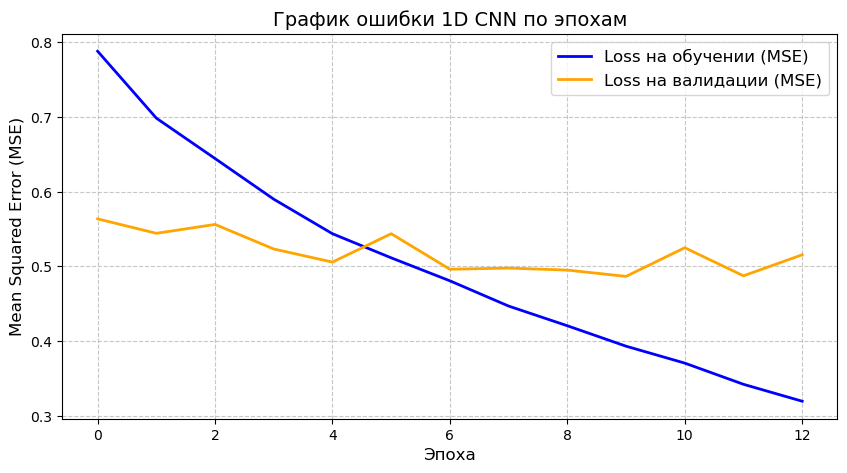

In [6]:
# === 1. ИМПОРТЫ ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Включаем красивые прогресс-бары для pandas
tqdm.pandas()

# Ограничиваем вывод логов TensorFlow (чтобы не спамил предупреждениями про AVX2)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

# === 2. ПАРАМЕТРЫ И ПУТИ ===
DATA_DIR = 'data'
GENOME_FASTA_PATH = os.path.join(DATA_DIR, 'U00096.3.fasta')
CSV_FILE_PATH = os.path.join(DATA_DIR, 'mmc4.csv')
UPSTREAM_WINDOW_SIZE = 500
RANDOM_STATE = 42
BASES = ['A', 'C', 'G', 'T', 'N']
NUM_BASES = len(BASES)

# === 3. ЗАГРУЗКА ДАННЫХ И ГЕНОМА ===
print("Загрузка данных...")
df = pd.read_csv(CSV_FILE_PATH)
df.dropna(subset=['Avrg_500_med_win_propensity'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Загрузка референсного генома...")
with open(GENOME_FASTA_PATH, "r") as handle:
    genome_record = next(SeqIO.parse(handle, "fasta"))
genome_sequence = str(genome_record.seq).upper()

# === 4. ИЗВЛЕЧЕНИЕ КОНТЕКСТА ИЗ ГЕНОМА ===
def get_upstream_context(row, genome_seq, window_size):
    pos = row['pos'] - 1
    strand = row['strand']
    if strand == '+':
        seq = genome_seq[max(0, pos - window_size) : pos]
        return seq.rjust(window_size, 'N')
    elif strand == '-':
        seq = genome_seq[pos : min(len(genome_seq), pos + window_size)]
        seq = seq.ljust(window_size, 'N')
        complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N'}
        return "".join([complement.get(base, 'N') for base in reversed(seq)])
    return 'N' * window_size

print(f"\nИзвлечение {UPSTREAM_WINDOW_SIZE}bp контекста для {len(df)} строк...")
df['upstream_context'] = df.progress_apply(
    lambda row: get_upstream_context(row, genome_sequence, UPSTREAM_WINDOW_SIZE), axis=1
)

# === 5. ONE-HOT ENCODING (3D ФОРМАТ) ===
def one_hot_encode_3d(sequence):
    encoding_map = {base: i for i, base in enumerate(BASES)}
    seq_matrix = np.zeros((UPSTREAM_WINDOW_SIZE, NUM_BASES), dtype=np.int8)
    for i, char in enumerate(sequence):
        idx = encoding_map.get(char, 4) # 4 это индекс 'N'
        seq_matrix[i, idx] = 1
    return seq_matrix

print("\nВыполняем One-Hot Encoding (создание 3D матриц)...")
X_3d_list = df['upstream_context'].progress_apply(one_hot_encode_3d).tolist()

X_3d = np.array(X_3d_list, dtype=np.int8) 
y = df['Avrg_500_med_win_propensity'].values

# Для классических моделей (Sklearn) сплющиваем 3D в 2D (500*5 = 2500 признаков)
X_2d = X_3d.reshape(X_3d.shape[0], -1)

# === 6. РАЗБИЕНИЕ НА TRAIN И TEST ===
X_train_3d, X_test_3d, y_train, y_test = train_test_split(X_3d, y, test_size=0.2, random_state=RANDOM_STATE)
X_train_2d = X_train_3d.reshape(X_train_3d.shape[0], -1)
X_test_2d = X_test_3d.reshape(X_test_3d.shape[0], -1)

results = {}

# === 7. ОБУЧЕНИЕ МОДЕЛЕЙ ===

# 1. Линейная регрессия
print("\n--- Обучение Linear Regression ---")
lr = LinearRegression()
lr.fit(X_train_2d, y_train)
y_pred_lr = lr.predict(X_test_2d)
results['Linear Regression'] = {
    "Test R2": r2_score(y_test, y_pred_lr),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr))
}
print(f"LR завершена. R2: {results['Linear Regression']['Test R2']:.3f}")

# 2. Random Forest
print("\n--- Обучение Random Forest (Ожидайте, строятся 50 деревьев) ---")
rf = RandomForestRegressor(
    n_estimators=50, 
    max_depth=10, 
    min_samples_leaf=10, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,      # Использовать все ядра
    verbose=2       # Показывать прогресс
)
rf.fit(X_train_2d, y_train)
y_pred_rf = rf.predict(X_test_2d)
results['Random Forest'] = {
    "Test R2": r2_score(y_test, y_pred_rf),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf))
}
print(f"RF завершен. R2: {results['Random Forest']['Test R2']:.3f}")

# 3. Convolutional Neural Network (1D CNN)
print("\n--- Создание и обучение 1D CNN ---")
model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=8, activation='relu', input_shape=(UPSTREAM_WINDOW_SIZE, NUM_BASES)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=4, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1) # Регрессия (1 выход, без функции активации)
])

model_cnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Обучение сети
history = model_cnn.fit(
    X_train_3d, y_train,
    epochs=15, 
    batch_size=128, 
    validation_split=0.2, 
    callbacks=[early_stop],
    verbose=1
)

y_pred_cnn = model_cnn.predict(X_test_3d).flatten()
results['1D CNN'] = {
    "Test R2": r2_score(y_test, y_pred_cnn),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_cnn))
}
print(f"CNN завершена. R2: {results['1D CNN']['Test R2']:.3f}")

# === 8. ИТОГОВЫЕ РЕЗУЛЬТАТЫ И ГРАФИКИ ===
res_df = pd.DataFrame(results).T.sort_values("Test R2", ascending=False)
print("\n=== ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(res_df)

# Отрисовка графика обучения CNN
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss на обучении (MSE)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Loss на валидации (MSE)', color='orange', linewidth=2)
plt.title('График ошибки 1D CNN по эпохам', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

def residual_block(x, filters, kernel_size):
    """
    Создает один Residual Block. 
    Если вход и выход не совпадают по числу фильтров, используем 1x1 свертку для выравнивания.
    """
    shortcut = x
    
    # Первая свертка в блоке
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # Вторая свертка
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    
    # Выравнивание размерностей (если нужно)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)
        
    # Сложение (Skip connection)
    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    
    # Spatial Dropout выключает целые фильтры, заставляя сеть учить независимые мотивы
    x = SpatialDropout1D(0.2)(x)
    return x

# === Сборка архитектуры ===
# Входной слой (Длина окна 500, 5 нуклеотидов)
inputs = Input(shape=(500, 5))

# "Ствол" сети (Stem) - ищет базовые короткие мотивы (длина 10)
x = Conv1D(64, kernel_size=10, padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# Добавляем 3 Residual блока. С каждым блоком сеть видит более сложные комбинации мотивов
x = residual_block(x, filters=64, kernel_size=8)
x = residual_block(x, filters=128, kernel_size=5)  # Увеличиваем число фильтров
x = residual_block(x, filters=128, kernel_size=3)

# Переход от последовательности к одному вектору (усредняем наличие мотивов по всей длине)
x = GlobalAveragePooling1D()(x)

# Полносвязная голова для финального предсказания
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1)(x) # Выход (регрессия)

model_resnet = Model(inputs=inputs, outputs=outputs)

# === Компиляция и Коллбеки ===
# Используем Huber Loss - он менее чувствителен к выбросам, чем MSE
model_resnet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                     loss=tf.keras.losses.Huber(), 
                     metrics=['mse', 'mae'])

# ReduceLROnPlateau: Уменьшает скорость обучения, если валидация перестала улучшаться
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
early_stop_resnet = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("--- Обучение Advanced DNA ResNet ---")
history_resnet = model_resnet.fit(
    X_train_3d, y_train,
    epochs=30, # Можно поставить больше, так как есть ранняя остановка
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop_resnet, reduce_lr],
    verbose=1
)

# === Оценка модели ===
y_pred_resnet = model_resnet.predict(X_test_3d).flatten()
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

resnet_r2 = r2_score(y_test, y_pred_resnet)
resnet_rmse = np.sqrt(mean_squared_error(y_test, y_pred_resnet))

print(f"\n--- Результаты Advanced ResNet ---")
print(f"Test R2:   {resnet_r2:.3f}")
print(f"Test RMSE: {resnet_rmse:.3f}")

# === Отрисовка графиков ===
plt.figure(figsize=(10, 5))
plt.plot(history_resnet.history['loss'], label='Loss на обучении (Huber)', color='blue', linewidth=2)
plt.plot(history_resnet.history['val_loss'], label='Loss на валидации (Huber)', color='orange', linewidth=2)
plt.title(f'Обучение Advanced ResNet (Test R2: {resnet_r2:.3f})', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Huber Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

--- Обучение Advanced DNA ResNet ---
Epoch 1/30


2026-02-20 20:49:53.156096: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-20 20:49:53.156207: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-20 20:49:53.156249: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-20 20:49:53.156272: I external/l

711/712 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.3205 - mae: 0.6536 - mse: 0.8203

2026-02-20 20:51:51.331188: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-20 20:51:51.331341: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-20 20:51:51.331363: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-20 20:51:51.331382: I external/l

712/712 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.3204 - mae: 0.6535 - mse: 0.8201

2026-02-20 20:52:10.796150: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-20 20:52:11.898731: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_252', 116 bytes spill stores, 116 bytes spill loads

2026-02-20 20:52:21.531736: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-20 20:52:21.531856: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were f

712/712 ━━━━━━━━━━━━━━━━━━━━ 165s 189ms/step - loss: 0.2728 - mae: 0.5913 - mse: 0.6902 - val_loss: 0.6046 - val_mae: 1.0298 - val_mse: 1.6367 - learning_rate: 0.0010
Epoch 2/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 107s 150ms/step - loss: 0.1962 - mae: 0.4731 - mse: 0.5051 - val_loss: 0.4954 - val_mae: 0.8985 - val_mse: 1.3074 - learning_rate: 0.0010
Epoch 3/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 107s 150ms/step - loss: 0.1575 - mae: 0.4078 - mse: 0.4092 - val_loss: 0.5689 - val_mae: 1.0009 - val_mse: 1.4742 - learning_rate: 0.0010
Epoch 4/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 107s 150ms/step - loss: 0.1341 - mae: 0.3689 - mse: 0.3469 - val_loss: 0.4904 - val_mae: 0.9033 - val_mse: 1.2486 - learning_rate: 0.0010
Epoch 5/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 107s 150ms/step - loss: 0.1153 - mae: 0.3390 - mse: 0.2991 - val_loss: 0.3912 - val_mae: 0.7677 - val_mse: 0.9847 - learning_rate: 0.0010
Epoch 6/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 107s 150ms/step - loss: 0.1027 - mae: 0.3174 - mse: 0.2650 - val_loss: 0.4042 - v

KeyboardInterrupt: 

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 500, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 500, 64)   │      1,024 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 500, 64)   │      2,304 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 500, 64)   │      3,584 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 500, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 500, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 500, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 500, 192)  │          0 │ activation_7[0][… │
│ (Concatenate)       │                   │            │ activation_8[0][… │
│                     │                   │            │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 250, 192)  │          0 │ concatenate[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 250, 128)  │     24,704 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 250, 128)  │    131,584 │ max_pooling1d_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 250, 128)  │          0 │ conv1d_13[0][0],  │
│                     │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 250, 128)  │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_10[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ global_average_p

 Total params: 213,185 (832.75 KB)

 Trainable params: 212,801 (831.25 KB)

 Non-trainable params: 384 (1.50 KB)


--- Обучение модели CBR-KAN ---
Epoch 1/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 188s 256ms/step - loss: 0.7752 - mae: 0.6471 - val_loss: 0.5771 - val_mae: 0.5753 - learning_rate: 0.0010
Epoch 2/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 180s 253ms/step - loss: 0.6848 - mae: 0.6102 - val_loss: 0.5644 - val_mae: 0.5550 - learning_rate: 0.0010
Epoch 3/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 185s 260ms/step - loss: 0.6561 - mae: 0.5951 - val_loss: 0.6399 - val_mae: 0.5470 - learning_rate: 0.0010
Epoch 4/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 184s 258ms/step - loss: 0.6438 - mae: 0.5865 - val_loss: 0.5445 - val_mae: 0.5395 - learning_rate: 0.0010
Epoch 5/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 183s 257ms/step - loss: 0.6224 - mae: 0.5729 - val_loss: 0.5528 - val_mae: 0.5700 - learning_rate: 0.0010
Epoch 6/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 194s 273ms/step - loss: 0.6055 - mae: 0.5621 - val_loss: 0.5135 - val_mae: 0.5110 - learning_rate: 0.0010
Epoch 7/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 185s 261ms/step - loss: 0.5794 - mae: 0.5446 - val_

Exception ignored in: <function tqdm.__del__ at 0x73c60c2fb520>
Traceback (most recent call last):
  File "/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


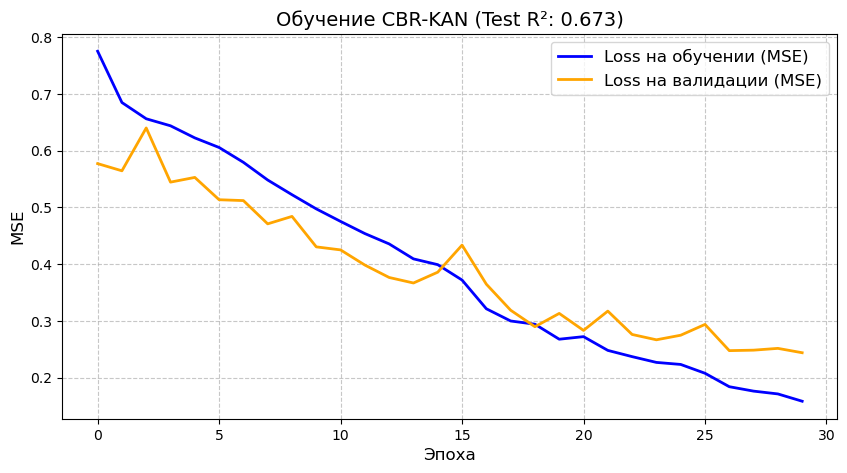

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, Activation, 
                                     MaxPooling1D, Concatenate, Bidirectional, LSTM, 
                                     GlobalAveragePooling1D, Dense, Dropout, Add, Layer)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# === 1. Кастомный слой KAN (Kolmogorov-Arnold Network Approximation) ===
class SimpleKANLayer(Layer):
    """
    Легковесная аппроксимация KAN-слоя для Keras.
    Вместо линейного умножения W*x, использует сумму базовой активации (SiLU) 
    и разложения по базисным функциям (гауссовым RBF), имитируя B-сплайны.
    """
    def __init__(self, units, grid_size=5, **kwargs):
        super(SimpleKANLayer, self).__init__(**kwargs)
        self.units = units
        self.grid_size = grid_size

    def build(self, input_shape):
        self.in_features = input_shape[-1]
        # Базовые веса (аналог обычного Dense слоя)
        self.base_weight = self.add_weight(
            shape=(self.in_features, self.units), initializer="glorot_uniform", trainable=True, name="base_weight"
        )
        # Веса для сплайнов/базисных функций
        self.spline_weight = self.add_weight(
            shape=(self.in_features, self.units, self.grid_size), initializer="random_normal", trainable=True, name="spline_weight"
        )
        # Сетка для базисных функций
        self.grid = tf.cast(tf.linspace(-2.0, 2.0, self.grid_size), dtype=tf.float32)

    def call(self, inputs):
        # 1. Базовая часть (Linear + SiLU)
        base_output = tf.matmul(tf.nn.silu(inputs), self.base_weight)
        
        # 2. Сплайновая часть (RBF аппроксимация)
        x_expanded = tf.expand_dims(inputs, -1) # (batch, in_features, 1)
        # Вычисляем расстояние до узлов сетки
        basis = tf.exp(-tf.square(x_expanded - self.grid)) # (batch, in_features, grid_size)
        # Умножаем базисы на обучаемые веса сплайнов
        spline_output = tf.einsum('big,iog->bo', basis, self.spline_weight)
        
        return base_output + spline_output


# === 2. Построение архитектуры CBR-KAN ===
def build_cbr_kan(seq_length=500, num_bases=5):
    inputs = Input(shape=(seq_length, num_bases))
    
    # --- Блок C (Multi-scale CNN) ---
    # Параллельные свертки с разным размером ядра (как ConvBlock 1, 2, 3 в статье)
    conv_small = Conv1D(64, kernel_size=3, padding='same')(inputs)
    conv_small = Activation('relu')(BatchNormalization()(conv_small))
    
    conv_medium = Conv1D(64, kernel_size=7, padding='same')(inputs)
    conv_medium = Activation('relu')(BatchNormalization()(conv_medium))
    
    conv_large = Conv1D(64, kernel_size=11, padding='same')(inputs)
    conv_large = Activation('relu')(BatchNormalization()(conv_large))
    
    # Объединяем разномасштабные признаки
    cnn_concat = Concatenate()([conv_small, conv_medium, conv_large])
    cnn_pooled = MaxPooling1D(pool_size=2)(cnn_concat) # Уменьшаем размерность
    
    # --- Блок B (BiLSTM) ---
    # Читаем последовательность в обе стороны для понимания грамматики мотивов
    # return_sequences=True, чтобы вернуть тензор 3D, совместимый с CNN
    bilstm_out = Bidirectional(LSTM(64, return_sequences=True))(cnn_pooled)
    
    # --- Блок R (Residual Fusion) ---
    # Чтобы сложить выходы CNN и BiLSTM, их размерности должны совпадать.
    # Пропускаем выход CNN через 1x1 свертку, чтобы уровнять число каналов с BiLSTM (64*2=128)
    cnn_aligned = Conv1D(128, kernel_size=1, padding='same')(cnn_pooled)
    
    # Остаточное сложение (Fusion)
    fused_features = Add()([cnn_aligned, bilstm_out])
    fused_features = Activation('relu')(fused_features)
    
    # Переводим в 1D вектор перед полносвязными/KAN слоями
    pooled_vector = GlobalAveragePooling1D()(fused_features)
    pooled_vector = Dropout(0.4)(pooled_vector)
    
    # --- Блок KAN ---
    # Заменяем традиционные Dense(MLP) слои на наш кастомный KAN
    kan_out = SimpleKANLayer(64, grid_size=5)(pooled_vector)
    kan_out = Dropout(0.3)(kan_out)
    
    # Финальный выход для задачи регрессии
    outputs = Dense(1)(kan_out)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Создаем модель
model_cbr_kan = build_cbr_kan()

# Компиляция
# Используем MSE, так как модель сложная и нам нужен точный градиент для сплайнов
model_cbr_kan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_cbr_kan.summary()

# === 3. Обучение модели ===
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n--- Обучение модели CBR-KAN ---")
history_cbr_kan = model_cbr_kan.fit(
    X_train_3d, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# === 4. Оценка и визуализация ===
y_pred_kan = model_cbr_kan.predict(X_test_3d).flatten()

kan_r2 = r2_score(y_test, y_pred_kan)
kan_rmse = np.sqrt(mean_squared_error(y_test, y_pred_kan))

print(f"\n--- Итоговые результаты CBR-KAN ---")
print(f"Test R2:   {kan_r2:.3f}")
print(f"Test RMSE: {kan_rmse:.3f}")

# Отрисовка
plt.figure(figsize=(10, 5))
plt.plot(history_cbr_kan.history['loss'], label='Loss на обучении (MSE)', color='blue', linewidth=2)
plt.plot(history_cbr_kan.history['val_loss'], label='Loss на валидации (MSE)', color='orange', linewidth=2)
plt.title(f'Обучение CBR-KAN (Test R²: {kan_r2:.3f})', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Поиск лучшей последовательности в тестовой выборке...
Индекс: 2076
Истинное значение: 23.482
Предсказание CBR-KAN: 8.898

Выполняем предсказания для 1500 мутантных последовательностей...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step


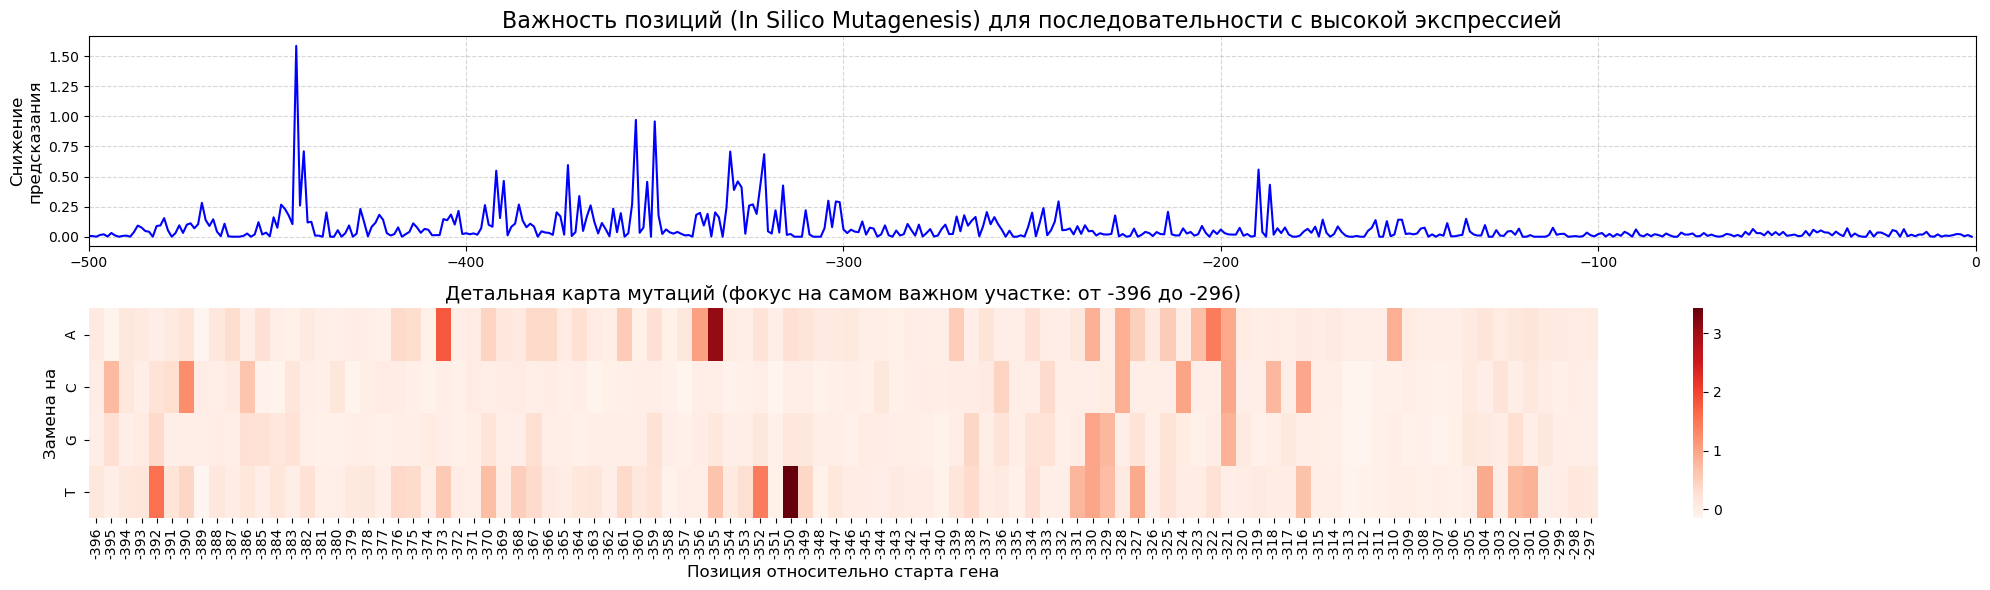

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Поиск лучшей последовательности в тестовой выборке...")
# Находим индекс последовательности с самым высоким реальным значением
best_idx = np.argmax(y_test)
original_seq_3d = X_test_3d[best_idx]
original_propensity = y_test[best_idx]
predicted_propensity = model_cbr_kan.predict(np.expand_dims(original_seq_3d, axis=0), verbose=0)[0][0]

print(f"Индекс: {best_idx}")
print(f"Истинное значение: {original_propensity:.3f}")
print(f"Предсказание CBR-KAN: {predicted_propensity:.3f}")

# Подготовка к мутагенезу
SEQ_LENGTH = 500
BASES = ['A', 'C', 'G', 'T', 'N']
# Создаем пустую матрицу для результатов (4 нуклеотида x 500 позиций)
# Мы игнорируем 'N', нас интересуют только осмысленные мутации
mutagenesis_matrix = np.zeros((4, SEQ_LENGTH)) 

# Делаем предсказания батчами (чтобы было быстро)
batch_seqs = []
mut_indices = []

# Генерируем все возможные точечные мутации
for pos in range(SEQ_LENGTH):
    original_base_idx = np.argmax(original_seq_3d[pos])
    
    for new_base_idx in range(4): # 0:A, 1:C, 2:G, 3:T
        if new_base_idx != original_base_idx: # Если это мутация
            mutated_seq = original_seq_3d.copy()
            # Зануляем старый нуклеотид
            mutated_seq[pos] = 0 
            # Ставим новый
            mutated_seq[pos, new_base_idx] = 1 
            
            batch_seqs.append(mutated_seq)
            mut_indices.append((new_base_idx, pos))

print(f"\nВыполняем предсказания для {len(batch_seqs)} мутантных последовательностей...")
batch_seqs = np.array(batch_seqs)
# Предсказываем сразу весь батч
mutated_predictions = model_cbr_kan.predict(batch_seqs, batch_size=512, verbose=1).flatten()

# Заполняем матрицу мутагенеза
# Значение = Оригинальное предсказание - Предсказание после мутации
# (Чем больше положительное число, тем сильнее мутация "сломала" экспрессию)
for i, (new_base_idx, pos) in enumerate(mut_indices):
    delta = predicted_propensity - mutated_predictions[i]
    mutagenesis_matrix[new_base_idx, pos] = delta

# Для визуализации: считаем "общую важность" позиции (усредняем эффект всех мутаций в этой точке)
position_importance = np.mean(np.maximum(mutagenesis_matrix, 0), axis=0)

# === ВИЗУАЛИЗАЦИЯ ===
plt.figure(figsize=(20, 6))

# Верхний график: общая важность позиции
plt.subplot(2, 1, 1)
plt.plot(range(-500, 0), position_importance, color='blue')
plt.title(f'Важность позиций (In Silico Mutagenesis) для последовательности с высокой экспрессией', fontsize=16)
plt.ylabel('Снижение\nпредсказания', fontsize=12)
plt.xlim(-500, 0)
plt.grid(True, linestyle='--', alpha=0.5)

# Нижний график: Тепловая карта эффекта каждой конкретной замены
plt.subplot(2, 1, 2)
# Покажем только участок с наибольшей активностью (чтобы было видно глазами)
# Найдем окно в 100 пар нуклеотидов с самой высокой суммарной важностью
window_size = 100
max_importance_start = np.argmax([np.sum(position_importance[i:i+window_size]) for i in range(SEQ_LENGTH - window_size)])
end_pos = max_importance_start + window_size

sns.heatmap(mutagenesis_matrix[:, max_importance_start:end_pos], 
            cmap='Reds', 
            yticklabels=['A', 'C', 'G', 'T'], 
            xticklabels=range(-500 + max_importance_start, -500 + end_pos))
plt.title(f'Детальная карта мутаций (фокус на самом важном участке: от {-500+max_importance_start} до {-500+end_pos})', fontsize=14)
plt.xlabel('Позиция относительно старта гена', fontsize=12)
plt.ylabel('Замена на', fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, Activation, 
                                     GlobalAveragePooling1D, Dense, Dropout, Add, Layer,
                                     MultiHeadAttention, LayerNormalization)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# === 0. Трансформация целевой переменной (Log1p) ===
# Это фундаментально улучшит предсказание экстремальных значений (выбросов)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# === 1. Кастомный слой KAN (Оставляем без изменений) ===
class SimpleKANLayer(Layer):
    def __init__(self, units, grid_size=5, **kwargs):
        super(SimpleKANLayer, self).__init__(**kwargs)
        self.units = units
        self.grid_size = grid_size

    def build(self, input_shape):
        self.in_features = input_shape[-1]
        self.base_weight = self.add_weight(shape=(self.in_features, self.units), initializer="glorot_uniform", trainable=True)
        self.spline_weight = self.add_weight(shape=(self.in_features, self.units, self.grid_size), initializer="random_normal", trainable=True)
        self.grid = tf.cast(tf.linspace(-2.0, 2.0, self.grid_size), dtype=tf.float32)

    def call(self, inputs):
        base_output = tf.matmul(tf.nn.silu(inputs), self.base_weight)
        x_expanded = tf.expand_dims(inputs, -1)
        basis = tf.exp(-tf.square(x_expanded - self.grid))
        spline_output = tf.einsum('big,iog->bo', basis, self.spline_weight)
        return base_output + spline_output

# === 2. Блок Трансформера (Self-Attention) ===
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    # Внимание (Self-Attention)
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Add()([x, inputs]) # Residual

    # Feed Forward
    res = x
    x = LayerNormalization(epsilon=1e-6)(x)
    x = Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = Add()([x, res]) # Residual
    return x

# === 3. Построение Архитектуры (Enformer-style) ===
def build_ultimate_dna_model(seq_length=500, num_bases=5):
    inputs = Input(shape=(seq_length, num_bases))
    
    # 1. Поиск базовых мотивов (Обычная свертка)
    x = Conv1D(128, kernel_size=7, padding='same')(inputs)
    x = Activation('gelu')(BatchNormalization()(x))
    
    # 2. Башня расширенных сверток (Dilated Convolutions)
    # Увеличиваем радиус обзора (2, 4, 8, 16) без потери разрешения!
    for rate in [2, 4, 8, 16]:
        residual = x
        x = Conv1D(128, kernel_size=5, padding='same', dilation_rate=rate)(x)
        x = Activation('gelu')(BatchNormalization()(x))
        x = SpatialDropout1D(0.1)(x) # Выключаем случайные карты признаков
        x = Add()([x, residual])
        
    # Сжимаем размерность перед Трансформером (чтобы не кончилась память GPU)
    x = Conv1D(64, kernel_size=1, padding='same')(x)
    
    # 3. Блок Трансформера (Поиск связей между мотивами)
    # Позволяет мотиву на позиции -400 "поговорить" с мотивом на позиции -10
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)
    
    # 4. Агрегация и KAN
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)
    x = SimpleKANLayer(64, grid_size=5)(x)
    x = Dropout(0.2)(x)
    
    # Выход
    outputs = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Импортируем недостающий слой
from tensorflow.keras.layers import SpatialDropout1D

model_ultimate = build_ultimate_dna_model()

# Компиляция с Huber Loss (защита от оставшихся выбросов)
model_ultimate.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Уменьшили базовый LR для Трансформера
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

# === 4. Обучение модели ===
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

print("\n--- Обучение Ultimate DNA Transformer-KAN ---")
history_ult = model_ultimate.fit(
    X_train_3d, y_train_log, # ОБУЧАЕМ НА ЛОГАРИФМАХ!
    epochs=40,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# === 5. Оценка и визуализация ===
# Предсказываем логарифмы
y_pred_log = model_ultimate.predict(X_test_3d).flatten()

# ВОЗВРАЩАЕМ В ИСХОДНУЮ ШКАЛУ (Экспонента минус 1)
y_pred_real = np.expm1(y_pred_log)

ult_r2 = r2_score(y_test, y_pred_real)
ult_rmse = np.sqrt(mean_squared_error(y_test, y_pred_real))

print(f"\n--- Итоговые результаты Ultimate Model ---")
print(f"Test R2 (в реальной шкале):   {ult_r2:.3f}")
print(f"Test RMSE (в реальной шкале): {ult_rmse:.3f}")

# Отрисовка
plt.figure(figsize=(10, 5))
plt.plot(history_ult.history['loss'], label='Loss на обучении (Huber)', color='blue', linewidth=2)
plt.plot(history_ult.history['val_loss'], label='Loss на валидации (Huber)', color='orange', linewidth=2)
plt.title(f'Обучение Transformer-KAN (Test R²: {ult_r2:.3f})', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss (на логарифмах)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Дополнительный график: Scatter plot Истинные vs Предсказанные
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_real, alpha=0.3, s=5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинные значения (Propensity)", fontsize=12)
plt.ylabel("Предсказанные значения", fontsize=12)
plt.title("Корреляция предсказаний Ultimate модели", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- Обучение Ultimate DNA Transformer-KAN ---
Epoch 1/40


2026-02-21 01:13:07.379170: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 01:13:07.379642: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 01:13:07.379666: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 01:13:07.379926: I external/l

ResourceExhaustedError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/runpy.py", line 86, in _run_code

  File "/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/home/shestun/miniconda3/envs/gnn-env/lib/python


--- Обучение Ultimate DNA Transformer-KAN ---
Epoch 1/40


2026-02-21 01:20:49.584060: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 01:20:49.584136: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 01:20:49.584151: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 01:20:49.584166: I external/l

1423/1424 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - loss: 0.1731 - mae: 0.3911

2026-02-21 01:26:19.368043: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 01:26:19.368132: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 01:26:19.368149: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 01:26:19.368164: I external/l

1424/1424 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.1731 - mae: 0.3910

...

1424/1424 ━━━━━━━━━━━━━━━━━━━━ 398s 255ms/step - loss: 0.0607 - mae: 0.2451 - val_loss: 0.0493 - val_mae: 0.2553 - learning_rate: 5.0000e-04
Epoch 2/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 322s 226ms/step - loss: 0.0277 - mae: 0.1863 - val_loss: 0.0620 - val_mae: 0.3019 - learning_rate: 5.0000e-04
Epoch 3/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 325s 229ms/step - loss: 0.0236 - mae: 0.1710 - val_loss: 0.0680 - val_mae: 0.3227 - learning_rate: 5.0000e-04
Epoch 4/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 327s 229ms/step - loss: 0.0212 - mae: 0.1615 - val_loss: 0.0215 - val_mae: 0.1628 - learning_rate: 5.0000e-04
Epoch 5/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 327s 229ms/step - loss: 0.0177 - mae: 0.1440 - val_loss: 0.0236 - val_mae: 0.1827 - learning_rate: 5.0000e-04
Epoch 6/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 326s 229ms/step - loss: 0.0141 - mae: 0.1258 - val_loss: 0.0178 - val_mae: 0.1540 - learning_rate: 5.0000e-04
Epoch 7/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 326s 229ms/step - loss: 0.0120 - mae: 0.1149 - val_loss: 

2026-02-21 02:37:11.594009: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 02:37:14.042743: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8', 8 bytes spill stores, 8 bytes spill loads



889/890 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

2026-02-21 02:37:46.558869: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 02:37:47.997561: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 12 bytes spill stores, 12 bytes spill loads

2026-02-21 02:37:48.302006: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8', 8 bytes spill stores, 8 bytes spill loads

2026-02-21 02:37:48.306691: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_971', 16 bytes spill

890/890 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step

--- Итоговые результаты Ultimate Model ---
Test R2 (в реальной шкале):   0.499
Test RMSE (в реальной шкале): 0.645


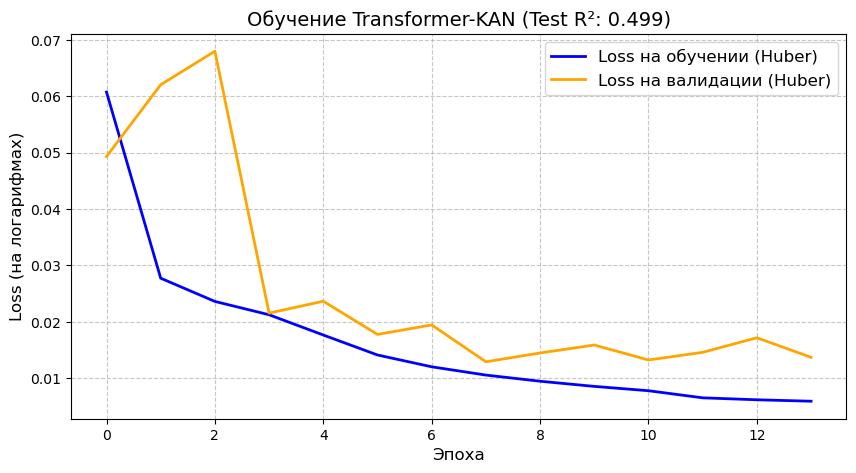

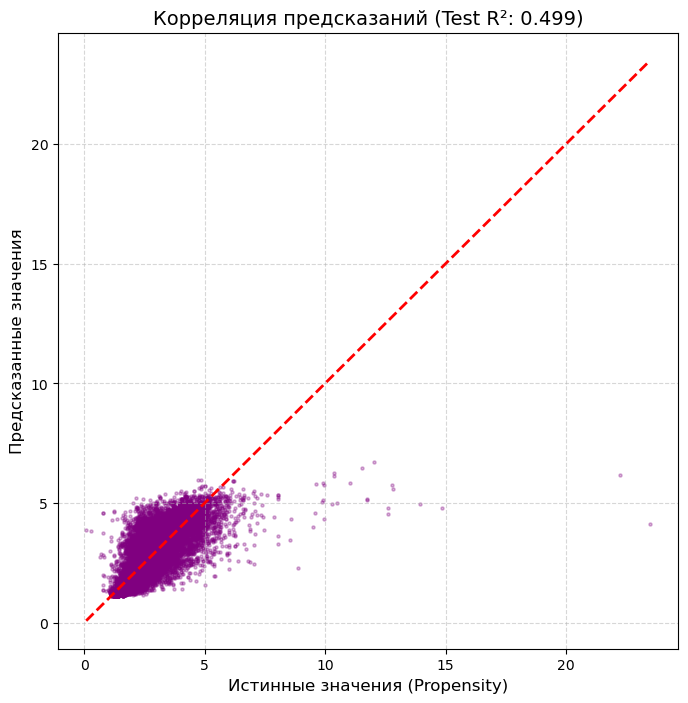

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, Activation, 
                                     GlobalAveragePooling1D, Dense, Dropout, Add, Layer,
                                     MultiHeadAttention, LayerNormalization, SpatialDropout1D,
                                     MaxPooling1D) # Добавили MaxPooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Очистка памяти Keras перед новым запуском
tf.keras.backend.clear_session()

# === 0. Трансформация целевой переменной (Log1p) ===
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# === 1. Кастомный слой KAN ===
class SimpleKANLayer(Layer):
    def __init__(self, units, grid_size=5, **kwargs):
        super(SimpleKANLayer, self).__init__(**kwargs)
        self.units = units
        self.grid_size = grid_size

    def build(self, input_shape):
        self.in_features = input_shape[-1]
        self.base_weight = self.add_weight(shape=(self.in_features, self.units), initializer="glorot_uniform", trainable=True)
        self.spline_weight = self.add_weight(shape=(self.in_features, self.units, self.grid_size), initializer="random_normal", trainable=True)
        self.grid = tf.cast(tf.linspace(-2.0, 2.0, self.grid_size), dtype=tf.float32)

    def call(self, inputs):
        base_output = tf.matmul(tf.nn.silu(inputs), self.base_weight)
        x_expanded = tf.expand_dims(inputs, -1)
        basis = tf.exp(-tf.square(x_expanded - self.grid))
        spline_output = tf.einsum('big,iog->bo', basis, self.spline_weight)
        return base_output + spline_output

# === 2. Блок Трансформера ===
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Add()([x, inputs]) 

    res = x
    x = LayerNormalization(epsilon=1e-6)(x)
    x = Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = Add()([x, res]) 
    return x

# === 3. Построение Архитектуры ===
def build_ultimate_dna_model(seq_length=500, num_bases=5):
    inputs = Input(shape=(seq_length, num_bases))
    
    # 1. Поиск базовых мотивов 
    x = Conv1D(64, kernel_size=7, padding='same')(inputs) # Уменьшили число фильтров до 64
    x = Activation('gelu')(BatchNormalization()(x))
    
    # 2. Башня расширенных сверток (Dilated Convolutions)
    for rate in [2, 4, 8]: # Убрали rate=16 для экономии памяти
        residual = x
        x = Conv1D(64, kernel_size=5, padding='same', dilation_rate=rate)(x)
        x = Activation('gelu')(BatchNormalization()(x))
        x = SpatialDropout1D(0.1)(x) 
        x = Add()([x, residual])
        
    # СПАСАЕМ ПАМЯТЬ: Сжимаем длину последовательности в 2 раза (до 250)
    # Это уменьшит потребление памяти Трансформером в 4 раза!
    x = MaxPooling1D(pool_size=2)(x)
    
    # Сжимаем каналы
    x = Conv1D(64, kernel_size=1, padding='same')(x)
    
    # 3. Блок Трансформера 
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)
    
    # 4. Агрегация и KAN
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)
    x = SimpleKANLayer(64, grid_size=5)(x)
    x = Dropout(0.2)(x)
    
    # Выход
    outputs = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model


model_ultimate = build_ultimate_dna_model()

model_ultimate.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

# === 4. Обучение модели ===
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

print("\n--- Обучение Ultimate DNA Transformer-KAN ---")
history_ult = model_ultimate.fit(
    X_train_3d, y_train_log, 
    epochs=40,
    batch_size=64, # УМЕНЬШИЛИ БАТЧ СО 128 ДО 64
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# === 5. Оценка и визуализация ===
y_pred_log = model_ultimate.predict(X_test_3d).flatten()

# Возвращаем из логарифма в реальную шкалу
y_pred_real = np.expm1(y_pred_log)

ult_r2 = r2_score(y_test, y_pred_real)
ult_rmse = np.sqrt(mean_squared_error(y_test, y_pred_real))

print(f"\n--- Итоговые результаты Ultimate Model ---")
print(f"Test R2 (в реальной шкале):   {ult_r2:.3f}")
print(f"Test RMSE (в реальной шкале): {ult_rmse:.3f}")

# Отрисовка
plt.figure(figsize=(10, 5))
plt.plot(history_ult.history['loss'], label='Loss на обучении (Huber)', color='blue', linewidth=2)
plt.plot(history_ult.history['val_loss'], label='Loss на валидации (Huber)', color='orange', linewidth=2)
plt.title(f'Обучение Transformer-KAN (Test R²: {ult_r2:.3f})', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss (на логарифмах)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Дополнительный график: Scatter plot Истинные vs Предсказанные
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_real, alpha=0.3, s=5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинные значения (Propensity)", fontsize=12)
plt.ylabel("Предсказанные значения", fontsize=12)
plt.title(f"Корреляция предсказаний (Test R²: {ult_r2:.3f})", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- Обучение финальной модели CBR-Attention-KAN ---
Epoch 1/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 312s 216ms/step - loss: 0.3346 - mae: 0.6333 - val_loss: 0.2527 - val_mae: 0.5534 - learning_rate: 0.0010
Epoch 2/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 306s 215ms/step - loss: 0.2841 - mae: 0.5777 - val_loss: 0.2409 - val_mae: 0.5377 - learning_rate: 0.0010
Epoch 3/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 306s 215ms/step - loss: 0.2557 - mae: 0.5380 - val_loss: 0.2162 - val_mae: 0.4798 - learning_rate: 0.0010
Epoch 4/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 306s 215ms/step - loss: 0.2292 - mae: 0.4962 - val_loss: 0.1937 - val_mae: 0.4441 - learning_rate: 0.0010
Epoch 5/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 306s 215ms/step - loss: 0.2027 - mae: 0.4554 - val_loss: 0.1933 - val_mae: 0.4422 - learning_rate: 0.0010
Epoch 6/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 306s 215ms/step - loss: 0.1804 - mae: 0.4252 - val_loss: 0.1808 - val_mae: 0.4347 - learning_rate: 0.0010
Epoch 7/40
1424/1424 ━━━━━━━━━━━━━━━━━━━━ 306s 215ms/step -

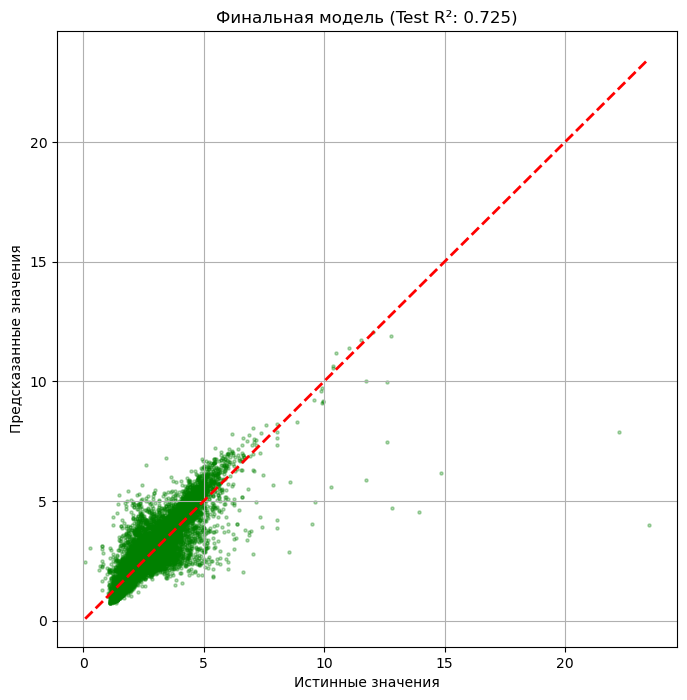

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, Activation, 
                                     GlobalAveragePooling1D, Dense, Dropout, Add, Layer,
                                     MultiHeadAttention, LayerNormalization, Bidirectional, LSTM, 
                                     Concatenate, MaxPooling1D)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Очистка памяти
tf.keras.backend.clear_session()

# === 1. Кастомный слой KAN (Без изменений) ===
class SimpleKANLayer(Layer):
    def __init__(self, units, grid_size=5, **kwargs):
        super(SimpleKANLayer, self).__init__(**kwargs)
        self.units = units
        self.grid_size = grid_size
    def build(self, input_shape):
        self.in_features = input_shape[-1]
        self.base_weight = self.add_weight(shape=(self.in_features, self.units), initializer="glorot_uniform", trainable=True)
        self.spline_weight = self.add_weight(shape=(self.in_features, self.units, self.grid_size), initializer="random_normal", trainable=True)
        self.grid = tf.cast(tf.linspace(-2.0, 2.0, self.grid_size), dtype=tf.float32)
    def call(self, inputs):
        base_output = tf.matmul(tf.nn.silu(inputs), self.base_weight)
        x_expanded = tf.expand_dims(inputs, -1)
        basis = tf.exp(-tf.square(x_expanded - self.grid))
        spline_output = tf.einsum('big,iog->bo', basis, self.spline_weight)
        return base_output + spline_output

# === 2. Построение гибридной архитектуры (CBR-Attention-KAN) ===
def build_final_model(seq_length=500, num_bases=5):
    inputs = Input(shape=(seq_length, num_bases))
    
    # Слой 1: Multi-scale CNN (Захват мотивов разной длины)
    c1 = Conv1D(48, kernel_size=3, padding='same')(inputs)
    c1 = Activation('relu')(BatchNormalization()(c1))
    
    c2 = Conv1D(48, kernel_size=11, padding='same')(inputs)
    c2 = Activation('relu')(BatchNormalization()(c2))
    
    x = Concatenate()([c1, c2]) # 96 фильтров
    x = MaxPooling1D(2)(x) # Сжимаем до 250 для BiLSTM
    
    # Слой 2: BiLSTM (Контекст и грамматика)
    x = Bidirectional(LSTM(64, return_sequences=True))(x) # 128 признаков
    
    # Слой 3: Multi-Head Attention (Связи между найденными мотивами)
    # Здесь мы не теряем разрешение дальше, а смотрим на "взаимоотношения"
    attention_out = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = Add()([x, attention_out]) # Residual connection
    x = LayerNormalization()(x)
    
    # Слой 4: Свертки для финализации пространственных признаков
    x = Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = GlobalAveragePooling1D()(x) # Превращаем в вектор 128
    
    # Слой 5: KAN + Выход
    x = Dropout(0.4)(x)
    x = SimpleKANLayer(64, grid_size=5)(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1)(x) # ПРЕДСКАЗЫВАЕМ В РЕАЛЬНОЙ ШКАЛЕ!
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

model_final = build_final_model()

# Компиляция: Huber Loss идеален для работы в реальной шкале с выбросами
model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(delta=1.5), # delta=1.5 дает баланс между MSE и MAE
    metrics=['mae']
)

# Обучение на ОРИГИНАЛЬНОМ y_train (не логарифмы!)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n--- Обучение финальной модели CBR-Attention-KAN ---")
history_final = model_final.fit(
    X_train_3d, y_train, # РЕАЛЬНАЯ ШКАЛА
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Оценка
y_pred_final = model_final.predict(X_test_3d).flatten()
final_r2 = r2_score(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f"\n--- Итоговые результаты Финальной Модели ---")
print(f"Test R2:   {final_r2:.3f}")
print(f"Test RMSE: {final_rmse:.3f}")

# Визуализация Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_final, alpha=0.3, s=5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Финальная модель (Test R²: {final_r2:.3f})")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.grid(True)
plt.show()

Загрузка CSV и Генома...
Извлечение последовательностей (500 bp)...



Извлечение: 100%|██████████████████████████████████████████████████████████████| 142383/142383 [00:07<00:00, 20148.28it/s]

Кодирование: 100%|█████████████████████████████████████████████████████████████| 142383/142383 [00:11<00:00, 12931.32it/s]
I0000 00:00:1771658846.919498   15980 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6



Старт обучения Bio-ConvNeXt...
Epoch 1/50


2026-02-21 10:27:34.017067: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ae5e4002c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-21 10:27:34.017161: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-02-21 10:27:34.211286: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-21 10:27:35.180671: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301
2026-02-21 10:27:35.474875: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 10:27:35.

1512/1513 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.3094 - mae: 0.6062

...

1513/1513 ━━━━━━━━━━━━━━━━━━━━ 403s 223ms/step - loss: 0.2800 - mae: 0.5772 - val_loss: 0.2530 - val_mae: 0.5383 - learning_rate: 0.0010
Epoch 2/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 262s 173ms/step - loss: 0.2376 - mae: 0.5167 - val_loss: 0.1799 - val_mae: 0.4147 - learning_rate: 0.0010
Epoch 3/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 261s 173ms/step - loss: 0.1570 - mae: 0.3864 - val_loss: 0.1129 - val_mae: 0.3133 - learning_rate: 0.0010
Epoch 4/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 261s 173ms/step - loss: 0.1048 - mae: 0.3091 - val_loss: 0.0857 - val_mae: 0.2668 - learning_rate: 0.0010
Epoch 5/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 261s 173ms/step - loss: 0.0790 - mae: 0.2681 - val_loss: 0.0943 - val_mae: 0.3020 - learning_rate: 0.0010
Epoch 6/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 261s 172ms/step - loss: 0.0662 - mae: 0.2457 - val_loss: 0.0757 - val_mae: 0.2581 - learning_rate: 0.0010
Epoch 7/50
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 261s 172ms/step - loss: 0.0583 - mae: 0.2311 - val_loss: 0.0800 - val_mae: 0.2701

2026-02-21 12:44:40.134622: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 12:44:42.346601: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[64,96,1,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,96,1,256]{3,2,1,0}, f32[96,1,1,7]{3,2,1,0}), window={size=1x7}, dim_labels=bf01_oi01->bf01, feature_group_count=96, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-21 12:44:43.607239: E external/local_xla/xla/service/slow_operat

888/890 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

2026-02-21 12:45:13.979894: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 12:45:16.152509: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[58,96,1,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[58,96,1,256]{3,2,1,0}, f32[96,1,1,7]{3,2,1,0}), window={size=1x7}, dim_labels=bf01_oi01->bf01, feature_group_count=96, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-21 12:45:17.233192: E external/local_xla/xla/service/slow_operat

890/890 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step

ФИНАЛЬНЫЙ ТЕСТОВЫЙ R2: 0.875
ФИНАЛЬНЫЙ ТЕСТОВЫЙ RMSE: 0.322


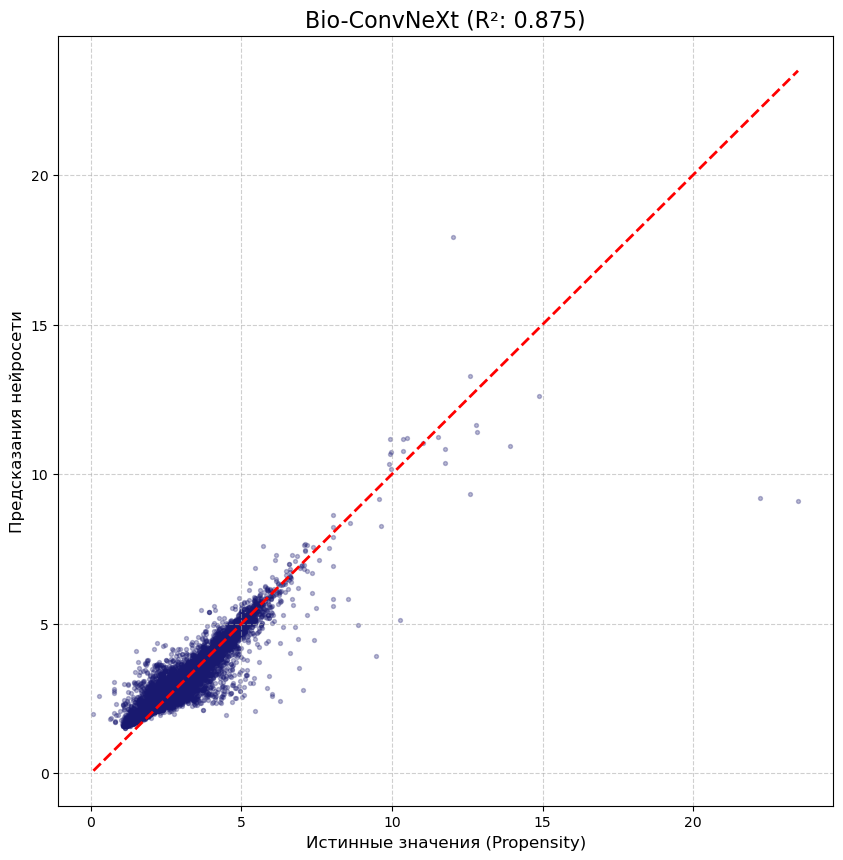

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from tqdm import tqdm # Используем стандартный tqdm вместо notebook

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, Activation, 
                                     GlobalAveragePooling1D, Dense, Dropout, Add, Layer,
                                     Multiply, DepthwiseConv1D, LayerNormalization)

# --- ПАРАМЕТРЫ ---
DATA_DIR = 'data'
GENOME_FASTA_PATH = os.path.join(DATA_DIR, 'U00096.3.fasta')
CSV_FILE_PATH = os.path.join(DATA_DIR, 'mmc4.csv')
WINDOW_SIZE = 500
BASES = ['A', 'C', 'G', 'T', 'N']

# --- 1. ЗАГРУЗКА ДАННЫХ ---
print("Загрузка CSV и Генома...")
df = pd.read_csv(CSV_FILE_PATH)
df.dropna(subset=['Avrg_500_med_win_propensity'], inplace=True)
df.reset_index(drop=True, inplace=True)

with open(GENOME_FASTA_PATH, "r") as handle:
    genome_record = next(SeqIO.parse(handle, "fasta"))
genome_seq = str(genome_record.seq).upper()

# --- 2. ИЗВЛЕЧЕНИЕ КОНТЕКСТА ---
def get_context(row, g_seq, win):
    pos = row['pos'] - 1
    if row['strand'] == '+':
        s = g_seq[max(0, pos - win) : pos].rjust(win, 'N')
    else:
        s = g_seq[pos : min(len(g_seq), pos + win)].ljust(win, 'N')
        comp = {'A':'T','T':'A','C':'G','G':'C','N':'N'}
        s = "".join([comp.get(b, 'N') for b in reversed(s)])
    return s

print(f"Извлечение последовательностей ({WINDOW_SIZE} bp)...")
# Ручной цикл вместо progress_apply для надежности
contexts = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Извлечение"):
    contexts.append(get_context(row, genome_seq, WINDOW_SIZE))
df['upstream_context'] = contexts

# --- 3. КОМПАКТНЫЙ ONE-HOT ENCODING (int8 экономит RAM) ---
def fast_encode(sequences):
    mapping = {b: i for i, b in enumerate(BASES)}
    X = np.zeros((len(sequences), WINDOW_SIZE, 5), dtype=np.int8)
    for i, seq in enumerate(tqdm(sequences, desc="Кодирование")):
        for j, char in enumerate(seq):
            X[i, j, mapping.get(char, 4)] = 1
    return X

X_3d = fast_encode(df['upstream_context'].values)
y = df['Avrg_500_med_win_propensity'].values

# Чистим память: удаляем таблицу и вызываем сборщик мусора
del df
import gc
gc.collect()

# --- 4. АРХИТЕКТУРА BIO-CONVNEXT ---

class BioFeatureExtractor(Layer):
    """Слой, считающий термодинамику и позицию прямо в GPU"""
    def __init__(self, seq_len=500, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        # Ядро для GC-контента (окно 11)
        kernel = np.zeros((11, 5, 1))
        kernel[:, 1, 0] = 1.0/11.0 # C
        kernel[:, 2, 0] = 1.0/11.0 # G
        self.gc_kernel = tf.constant(kernel, dtype=tf.float32)

    def call(self, inputs):
        inputs_f = tf.cast(inputs, tf.float32)
        # GC профиль
        gc_prof = tf.nn.conv1d(inputs_f, self.gc_kernel, stride=1, padding='SAME')
        # Позиция
        pos = tf.linspace(-1.0, 1.0, self.seq_len)
        pos = tf.cast(pos, tf.float32)
        pos = tf.tile(pos[None, :, None], [tf.shape(inputs)[0], 1, 1])
        return tf.concat([inputs_f, gc_prof, pos], axis=-1)

def convnext_glu_block(x, filters, dilation):
    """Блок с глубокой сверткой и вентильной активацией SwiGLU"""
    shortcut = x
    x = DepthwiseConv1D(kernel_size=7, padding='same', dilation_rate=dilation)(x)
    x = LayerNormalization()(x)
    
    # Ветвь SwiGLU
    gate = Conv1D(filters, 1, activation='sigmoid')(x)
    lin = Conv1D(filters, 1, activation='swish')(x)
    x = Multiply()([lin, gate])
    
    return Add()([shortcut, x])

def build_model():
    inputs = Input(shape=(WINDOW_SIZE, 5))
    # Вход: One-hot (5 каналов) -> Выход: Физика (7 каналов)
    x = BioFeatureExtractor(seq_len=WINDOW_SIZE)(inputs) 
    
    # Начальная свертка
    x = Conv1D(96, kernel_size=7, padding='same')(x)
    x = BatchNormalization()(x)
    
    # Каскад блоков с увеличивающимся охватом (Dilation)
    for d in [1, 2, 4, 8, 16]:
        x = convnext_glu_block(x, 96, d)
        
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='swish')(x)
    outputs = Dense(1)(x)
    return Model(inputs, outputs)

# --- 5. ОБУЧЕНИЕ ---
X_train, X_test, y_train, y_test = train_test_split(X_3d, y, test_size=0.2, random_state=42)

# Очистка сессии Keras перед созданием модели
tf.keras.backend.clear_session()

model = build_model()
# Huber Loss с дельтой 1.5 лучше всего работает на реальной шкале пропенсити
model.compile(optimizer=tf.keras.optimizers.Adam(0.001), 
              loss=tf.keras.losses.Huber(delta=1.5), 
              metrics=['mae'])

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
]

print("\nСтарт обучения Bio-ConvNeXt...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

# --- 6. РЕЗУЛЬТАТЫ ---
y_pred = model.predict(X_test).flatten()
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nФИНАЛЬНЫЙ ТЕСТОВЫЙ R2: {r2:.3f}")
print(f"ФИНАЛЬНЫЙ ТЕСТОВЫЙ RMSE: {rmse:.3f}")

# Визуализация результатов
plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred, alpha=0.3, s=8, color='midnightblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title(f"Bio-ConvNeXt (R²: {r2:.3f})", fontsize=16)
plt.xlabel("Истинные значения (Propensity)", fontsize=12)
plt.ylabel("Предсказания нейросети", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [4]:
model.save('bio_convnext_final_r875.keras')
print("Лучшая модель сохранена!")

Лучшая модель сохранена!


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from sklearn.metrics import r2_score, mean_squared_error
from tqdm import tqdm
import gc

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, Activation, 
                                     GlobalAveragePooling1D, Dense, Dropout, Add, Layer,
                                     Multiply, DepthwiseConv1D, LayerNormalization, 
                                     Concatenate, MultiHeadAttention, MaxPooling1D)

# Очистка памяти
tf.keras.backend.clear_session()

# --- 1. ПАРАМЕТРЫ ---
DATA_DIR = 'data'
GENOME_FASTA_PATH = os.path.join(DATA_DIR, 'U00096.3.fasta')
CSV_FILE_PATH = os.path.join(DATA_DIR, 'mmc4.csv')
WINDOW_SIZE = 500
BASES = ['A', 'C', 'G', 'T', 'N']

# --- 2. ПОДГОТОВКА ДАННЫХ (ЧЕСТНЫЙ СПЛИТ) ---
print("Загрузка и подготовка данных...")
df = pd.read_csv(CSV_FILE_PATH)
df['raw_target'] = (df['raw_propensity1'] + df['raw_propensity2']) / 2.0
df.dropna(subset=['raw_target'], inplace=True)
df['target_log'] = np.log1p(df['raw_target'])

with open(GENOME_FASTA_PATH, "r") as handle:
    genome_record = next(SeqIO.parse(handle, "fasta"))
genome_seq = str(genome_record.seq).upper()

def get_context(row, g_seq, win):
    pos = row['pos'] - 1
    if row['strand'] == '+':
        s = g_seq[max(0, pos - win) : pos].rjust(win, 'N')
    else:
        s = g_seq[pos : min(len(g_seq), pos + win)].ljust(win, 'N')
        comp = {'A':'T','T':'A','C':'G','G':'C','N':'N'}
        s = "".join([comp.get(b, 'N') for b in reversed(s)])
    return s

contexts = [get_context(row, genome_seq, WINDOW_SIZE) for _, row in tqdm(df.iterrows(), total=len(df), desc="Извлечение")]
df['upstream_context'] = contexts

# Региональный сплит (80/20) - НИКАКИХ УТЕЧЕК
split_point = int(len(genome_seq) * 0.8)
train_df = df[df['pos'] <= split_point]
test_df = df[df['pos'] > split_point]

def fast_encode(sequences):
    mapping = {b: i for i, b in enumerate(BASES)}
    X = np.zeros((len(sequences), WINDOW_SIZE, 5), dtype=np.int8)
    for i, seq in enumerate(sequences):
        for j, char in enumerate(seq):
            X[i, j, mapping.get(char, 4)] = 1
    return X

X_train = fast_encode(train_df['upstream_context'].values)
y_train = train_df['target_log'].values
X_test = fast_encode(test_df['upstream_context'].values)
y_test = test_df['target_log'].values

del df, train_df, test_df
gc.collect()

# --- 3. СВЕРХ-ФИЗИЧЕСКИЙ ЭКСТРАКТОР ---
class DNA_Physics_Oracle(Layer):
    """Вычисляет GC-плотность и AT-гибкость (Bendability) для оценки суперспирализации"""
    def __init__(self, seq_len=500, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        
        # Ядро 1: GC-контент (окно 15 п.н. для жесткости)
        k_gc = np.zeros((15, 5, 1))
        k_gc[:, 1:3, 0] = 1.0 / 15.0 # C и G
        self.kernel_gc = tf.constant(k_gc, dtype=tf.float32)
        
        # Ядро 2: AT-тракты (окно 5 п.н. для изгибаемости / bending)
        k_at = np.zeros((5, 5, 1))
        k_at[:, 0, 0] = 1.0 / 5.0 # A
        k_at[:, 3, 0] = 1.0 / 5.0 # T
        self.kernel_at = tf.constant(k_at, dtype=tf.float32)

    def call(self, inputs):
        inputs_f = tf.cast(inputs, tf.float32)
        gc_prof = tf.nn.conv1d(inputs_f, self.kernel_gc, stride=1, padding='SAME')
        at_bend = tf.nn.conv1d(inputs_f, self.kernel_at, stride=1, padding='SAME')
        
        pos = tf.linspace(-1.0, 1.0, self.seq_len)
        pos = tf.cast(pos, tf.float32)
        pos = tf.tile(pos[None, :, None], [tf.shape(inputs)[0], 1, 1])
        
        # 5 букв + 1 GC + 1 AT-гибкость + 1 Позиция = 8 каналов
        return tf.concat([inputs_f, gc_prof, at_bend, pos], axis=-1)

# --- 4. АРХИТЕКТУРА УРОВНЯ 2024 ---
def convnext_block(x, filters, dilation):
    shortcut = x
    x = DepthwiseConv1D(kernel_size=9, padding='same', dilation_rate=dilation)(x)
    x = LayerNormalization()(x)
    gate = Conv1D(filters, 1, activation='sigmoid')(x)
    lin = Conv1D(filters, 1, activation='swish')(x)
    x = Multiply()([lin, gate])
    return Add()([shortcut, x])

def build_oracle_model():
    inputs = Input(shape=(WINDOW_SIZE, 5))
    x = DNA_Physics_Oracle(seq_len=WINDOW_SIZE)(inputs) 
    
    # Inception-Stem: Параллельное чтение мотивов разной длины
    branch1 = Conv1D(48, kernel_size=3, padding='same', activation='swish')(x)
    branch2 = Conv1D(48, kernel_size=7, padding='same', activation='swish')(x)
    branch3 = Conv1D(48, kernel_size=11, padding='same', activation='swish')(x)
    x = Concatenate()([branch1, branch2, branch3]) # 144 канала
    x = BatchNormalization()(x)
    
    # Body: ConvNeXt с глубокой дилатацией (Охват 500+ п.н.)
    for d in [1, 2, 4, 8, 16, 32]:
        x = convnext_block(x, 144, d)
        
    # Сжимаем разрешение (каждые 4 п.н. становятся 1 токеном) для Трансформера
    x = MaxPooling1D(pool_size=4)(x)
    
    # Head: Self-Attention (Поиск 3D-взаимодействий / петель)
    x = LayerNormalization()(x)
    attn = MultiHeadAttention(num_heads=4, key_dim=36)(x, x)
    x = Add()([x, attn])
    
    # Aggregation & Output
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='swish')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1)(x)
    
    return Model(inputs, outputs)

# --- 5. ОБУЧЕНИЕ ---
model = build_oracle_model()
# Уменьшаем LR для стабильности Трансформера
model.compile(optimizer=tf.keras.optimizers.Adam(0.0003), 
              loss=tf.keras.losses.Huber(delta=1.0), 
              metrics=['mae'])

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
]

print("\nСтарт обучения 'DNA-Oracle' (Сырой сигнал + Честный Сплит)...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

# --- 6. ИТОГОВЫЙ СУД ---
y_pred_log = model.predict(X_test).flatten()
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

r2_real = r2_score(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"\nЧЕСТНЫЙ R2 (на новых регионах генома, сырой сигнал): {r2_real:.4f}")
print(f"ЧЕСТНЫЙ RMSE: {rmse_real:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.15, s=5, color='purple')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'k--', lw=2)
plt.title(f"DNA-Oracle Prediction (Honest R²: {r2_real:.4f})")
plt.xlabel("True Raw Propensity")
plt.ylabel("Predicted Raw Propensity")
plt.xscale('log'); plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Загрузка и подготовка данных...


Извлечение: 100%|██████████████████████████████████████████████████████████████| 142383/142383 [00:09<00:00, 15620.71it/s]



Старт обучения 'DNA-Oracle' (Сырой сигнал + Честный Сплит)...
Epoch 1/50


2026-02-22 00:57:36.519302: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 00:57:36.519965: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 00:57:36.519987: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 00:57:36.520103: I external/l

1161/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - loss: 0.1162 - mae: 0.3708

2026-02-22 01:07:16.288728: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 01:07:16.288928: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 01:07:16.288948: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 01:07:16.289068: I external/l

1162/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - loss: 0.1162 - mae: 0.3708

2026-02-22 01:09:01.642280: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 01:09:18.292272: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 01:09:20.167891: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_865', 8 bytes spill stores, 8 bytes spill loads

2026-02-22 01:09:20.299102: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

1162/1162 ━━━━━━━━━━━━━━━━━━━━ 727s 529ms/step - loss: 0.1012 - mae: 0.3484 - val_loss: 0.0624 - val_mae: 0.2768 - learning_rate: 3.0000e-04
Epoch 2/50
 200/1162 ━━━━━━━━━━━━━━━━━━━━ 5:08 321ms/step - loss: 0.0954 - mae: 0.3373

2026-03-16 01:38:25.706070: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


🧬 Загрузка данных...
✂️ Извлечение последовательностей...


100%|████████████████████████████████████████████████| 142383/142383 [00:05<00:00, 27176.95it/s]


🔢 Векторизованное кодирование...


I0000 00:00:1773614328.266935    5707 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


...

1494/1494 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 0.3369 - mae: 0.6430

2026-03-16 01:46:42.689933: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 01:46:43.317001: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_587', 28 bytes spill stores, 28 bytes spill loads

2026-03-16 01:46:43.655319: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_587', 28 bytes spill stores, 28 bytes spill loads

2026-03-16 01:46:45.178768: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[76,128,1,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[76,128,1,256]{3,2,1,

1494/1494 ━━━━━━━━━━━━━━━━━━━━ 490s 271ms/step - loss: 0.2984 - mae: 0.6020 - val_loss: 0.1594 - val_mae: 0.4571 - learning_rate: 0.0010
Epoch 2/60
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 337s 226ms/step - loss: 0.1998 - mae: 0.4560 - val_loss: 0.1904 - val_mae: 0.4886 - learning_rate: 0.0010
Epoch 3/60
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 338s 226ms/step - loss: 0.1233 - mae: 0.3496 - val_loss: 0.2171 - val_mae: 0.5330 - learning_rate: 0.0010
Epoch 4/60
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 337s 226ms/step - loss: 0.0931 - mae: 0.3051 - val_loss: 0.2055 - val_mae: 0.5082 - learning_rate: 0.0010
Epoch 5/60
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.0780 - mae: 0.2818
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 337s 226ms/step - loss: 0.0788 - mae: 0.2832 - val_loss: 0.2902 - val_mae: 0.6215 - learning_rate: 0.0010
Epoch 6/60
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 338s 226ms/step - loss: 0.0600 - mae: 0.2445 - val_loss: 0.1834 - val_mae: 0.47

2026-03-16 03:22:35.182500: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 03:22:36.417006: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_577', 28 bytes spill stores, 28 bytes spill loads

2026-03-16 03:22:38.021134: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[64,128,1,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,1,256]{3,2,1,0}, f32[128,1,1,7]{3,2,1,0}), window={size=1x7}, dim_labels=bf01_oi01->bf01, feature_group_count=128, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_conf

936/936 ━━━━━━━━━━━━━━━━━━━━ 49s 34ms/step

✅ Результаты:
R2: 0.178 | Pearson: 0.472 | Spearman: 0.549


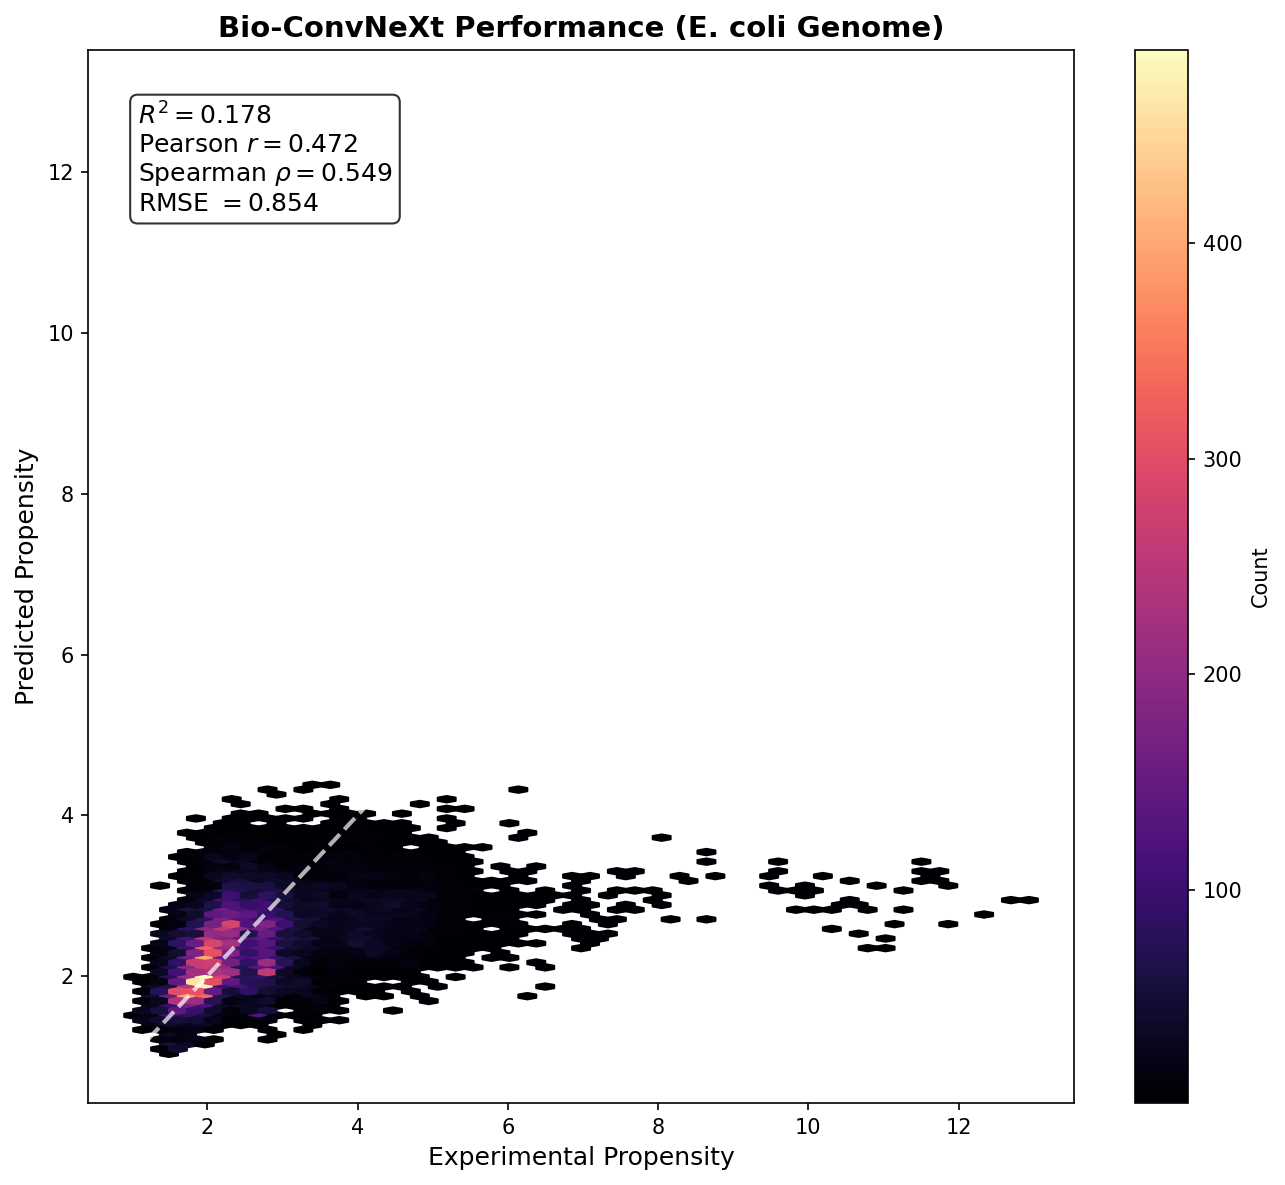

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit

# --- 1. НАСТРОЙКИ И ПУТИ ---
DATA_DIR = 'data'
GENOME_FASTA_PATH = os.path.join(DATA_DIR, 'U00096.3.fasta')
CSV_FILE_PATH = os.path.join(DATA_DIR, 'mmc4.csv')
WINDOW_SIZE = 500
BASES = np.array(['A', 'C', 'G', 'T', 'N'])

# --- 2. ФУНКЦИИ ЗАГРУЗКИ И ПОДГОТОВКИ ---
def load_and_preprocess():
    print("🧬 Загрузка данных...")
    df = pd.read_csv(CSV_FILE_PATH)
    df.dropna(subset=['Avrg_500_med_win_propensity'], inplace=True)
    
    with open(GENOME_FASTA_PATH, "r") as handle:
        genome_record = next(SeqIO.parse(handle, "fasta"))
    genome_seq = str(genome_record.seq).upper()
    
    def get_context(row, g_seq, win):
        pos = row['pos'] - 1
        if row['strand'] == '+':
            s = g_seq[max(0, pos - win) : pos].rjust(win, 'N')
        else:
            s = g_seq[pos : min(len(g_seq), pos + win)].ljust(win, 'N')
            comp = str.maketrans("ACGTN", "TGCAN")
            s = s.translate(comp)[::-1]
        return s

    print("✂️ Извлечение последовательностей...")
    df['seq'] = [get_context(row, genome_seq, WINDOW_SIZE) for _, row in tqdm(df.iterrows(), total=len(df))]
    
    # ПУБЛИКАБЕЛЬНОЕ РЕШЕНИЕ: Разбиение на блоки по 100кб против утечки данных
    BLOCK_SIZE = 100000
    df['block_id'] = df['pos'] // BLOCK_SIZE
    
    return df

def vectorized_one_hot(sequences):
    print("🔢 Векторизованное кодирование...")
    seq_array = np.array([list(s) for s in sequences])
    X = np.zeros((*seq_array.shape, 5), dtype=np.int8)
    for i, base in enumerate(BASES):
        X[seq_array == base, i] = 1
    return X

# --- 3. АРХИТЕКТУРА МОДЕЛИ (SOTA BIO-CONVNEXT) ---
class BioFeatureExtractor(tf.keras.layers.Layer):
    """Слой для GC-контента и позиционного кодирования внутри GPU"""
    def __init__(self, seq_len=500, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        
    def build(self, input_shape):
        # GC-ядро (окно 11)
        kernel = np.zeros((11, 5, 1), dtype=np.float32)
        kernel[:, 1, 0] = 1.0/11.0 # C
        kernel[:, 2, 0] = 1.0/11.0 # G
        self.gc_kernel = tf.constant(kernel)
        # Вектор позиций
        pos = tf.linspace(-1.0, 1.0, self.seq_len)
        self.pos_vec = tf.cast(pos, tf.float32)
        super().build(input_shape)

    def call(self, inputs):
        inputs_f = tf.cast(inputs, tf.float32)
        gc_prof = tf.nn.conv1d(inputs_f, self.gc_kernel, stride=1, padding='SAME')
        pos_batch = tf.tile(self.pos_vec[None, :, None], [tf.shape(inputs)[0], 1, 1])
        return tf.concat([inputs_f, gc_prof, pos_batch], axis=-1)

def convnext_block(x, filters, dilation, dropout=0.1):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv1D(filters, 1, padding='same')(x)
        
    # Глубокая свертка с большим ядром (ConvNeXt style)
    x = tf.keras.layers.DepthwiseConv1D(kernel_size=7, padding='same', dilation_rate=dilation)(x)
    x = tf.keras.layers.LayerNormalization()(x)
    
    # SwiGLU активация (SOTA для трансформеров и био-сетей)
    gate = tf.keras.layers.Conv1D(filters, 1, activation='sigmoid')(x)
    lin = tf.keras.layers.Conv1D(filters, 1, activation='swish')(x)
    x = tf.keras.layers.Multiply()([lin, gate])
    
    x = tf.keras.layers.Dropout(dropout)(x)
    return tf.keras.layers.Add()([shortcut, x])

def build_bio_model():
    inputs = tf.keras.layers.Input(shape=(WINDOW_SIZE, 5))
    x = BioFeatureExtractor(seq_len=WINDOW_SIZE)(inputs)
    
    x = tf.keras.layers.Conv1D(128, kernel_size=7, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    # Каскад блоков с экспоненциальной диляцией (расширение поля зрения)
    for d in [1, 2, 4, 8, 16]:
        x = convnext_block(x, 128, d)
        
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='swish')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1)(x)
    
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), 
                  loss=tf.keras.losses.Huber(delta=1.5), metrics=['mae'])
    return model

# --- 4. ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ ---
df = load_and_preprocess()
X = vectorized_one_hot(df['seq'].values)
y = df['Avrg_500_med_win_propensity'].values

# Пространственное разделение (Spatial Split) по блокам генома
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['block_id']))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

del X; gc.collect()

model = build_bio_model()
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

print("\n🚀 Обучение Bio-ConvNeXt...")
history = model.fit(X_train, y_train, epochs=60, batch_size=64, 
                    validation_split=0.15, callbacks=callbacks, verbose=1)

# --- 5. ВАЛИДАЦИЯ И ВИЗУАЛИЗАЦИЯ (PUBLICATION READY) ---
y_pred = model.predict(X_test).flatten()
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
p_r, _ = stats.pearsonr(y_test, y_pred)
s_r, _ = stats.spearmanr(y_test, y_pred)

print(f"\n✅ Результаты:\nR2: {r2:.3f} | Pearson: {p_r:.3f} | Spearman: {s_r:.3f}")

plt.figure(figsize=(9, 8), dpi=150)
# Построение Density Scatter (Hexbin)
hb = plt.hexbin(y_test, y_pred, gridsize=50, cmap='magma', mincnt=1)
cb = plt.colorbar(hb, label='Count')

# Линия идеального предсказания
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'w--', alpha=0.7, lw=2)

plt.xlabel('Experimental Propensity', fontsize=12)
plt.ylabel('Predicted Propensity', fontsize=12)
plt.title(f'Bio-ConvNeXt Performance (E. coli Genome)', fontsize=14, fontweight='bold')

# Добавление статистики на график
stats_text = f'$R^2 = {r2:.3f}$\nPearson $r = {p_r:.3f}$\nSpearman $\\rho = {s_r:.3f}$\nRMSE $= {rmse:.3f}$'
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('publication_result.pdf') # Сохранение в PDF для статьи
plt.show()

🧬 Чтение генома и CSV...
✂️ Векторизованное извлечение...
🔢 One-Hot кодирование (A, C, G, T, N)...

🚀 Старт обучения DNA-RC-Net (Siamese Architecture)...
Epoch 1/60


2026-03-16 03:35:59.197386: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 03:35:59.197550: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 03:35:59.197569: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 03:35:59.197590: I external/l

1581/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - loss: 1.6289 - mae: 0.7226

2026-03-16 03:49:06.571457: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 03:49:06.571532: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 03:49:06.571568: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 03:49:09.019505: I external/l

1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - loss: 1.6288 - mae: 0.7225

...

1582/1582 ━━━━━━━━━━━━━━━━━━━━ 901s 480ms/step - loss: 1.4254 - mae: 0.6912 - val_loss: 1.0386 - val_mae: 0.8920 - learning_rate: 0.0010
Epoch 2/60
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 695s 439ms/step - loss: 1.3158 - mae: 0.6703 - val_loss: 0.5525 - val_mae: 0.5280 - learning_rate: 0.0010
Epoch 3/60
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 695s 439ms/step - loss: 1.1191 - mae: 0.6131 - val_loss: 0.4080 - val_mae: 0.4621 - learning_rate: 0.0010
Epoch 4/60
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 695s 439ms/step - loss: 0.7098 - mae: 0.4831 - val_loss: 0.6653 - val_mae: 0.6642 - learning_rate: 0.0010
Epoch 5/60
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 695s 439ms/step - loss: 0.5340 - mae: 0.4226 - val_loss: 0.5154 - val_mae: 0.5709 - learning_rate: 0.0010
Epoch 6/60
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 695s 439ms/step - loss: 0.4655 - mae: 0.3902 - val_loss: 0.3278 - val_mae: 0.4200 - learning_rate: 0.0010
Epoch 7/60
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 695s 440ms/step - loss: 0.4002 - mae: 0.3658 - val_loss: 0.5122 - val_mae: 0.5841

2026-03-16 07:07:52.160401: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 07:07:52.160511: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 07:07:52.676062: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_871', 8 bytes spill stores, 8 bytes spill loads

2026-03-16 07:07:55.949262: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for c

233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step

2026-03-16 07:10:03.081239: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 07:10:03.081302: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 07:10:03.679979: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 16 bytes spill stores, 16 bytes spill loads

2026-03-16 07:10:06.839236: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for c

234/234 ━━━━━━━━━━━━━━━━━━━━ 190s 490ms/step

🏆 ИТОГИ DNA-RC-Net:
R2: 0.1851 | Pearson: 0.4639 | Spearman: 0.5046


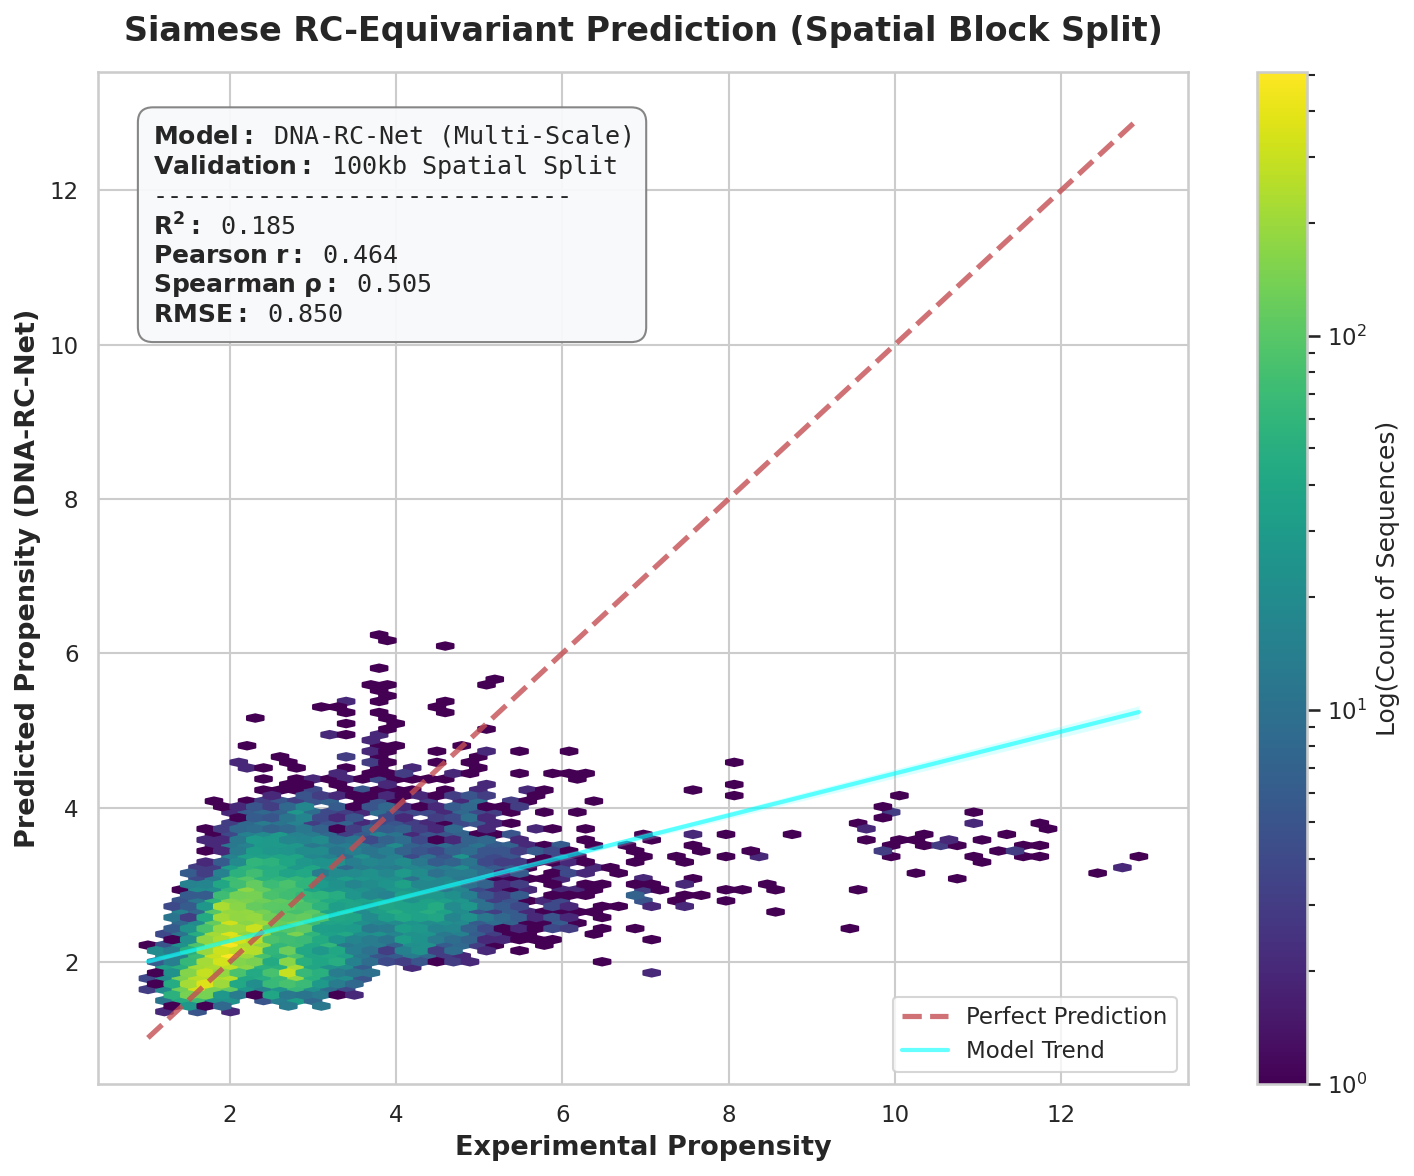

In [2]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit

# Очистка памяти и графов
tf.keras.backend.clear_session()
gc.collect()

# --- 1. ПАРАМЕТРЫ ---
DATA_DIR = 'data'
GENOME_FASTA_PATH = os.path.join(DATA_DIR, 'U00096.3.fasta')
CSV_FILE_PATH = os.path.join(DATA_DIR, 'mmc4.csv')
WINDOW_SIZE = 500
BASES = np.array(['A', 'C', 'G', 'T', 'N'])

# --- 2. БЫСТРАЯ И ЧИСТАЯ ЗАГРУЗКА ---
def load_and_encode():
    print("🧬 Чтение генома и CSV...")
    df = pd.read_csv(CSV_FILE_PATH).dropna(subset=['Avrg_500_med_win_propensity']).reset_index(drop=True)
    
    with open(GENOME_FASTA_PATH, "r") as handle:
        g_seq = str(next(SeqIO.parse(handle, "fasta")).seq).upper()
        
    print("✂️ Векторизованное извлечение...")
    # Оптимизированное извлечение с учетом цепей
    seqs = []
    comp_trans = str.maketrans("ACGTN", "TGCAN")
    for pos, strand in zip(df['pos'], df['strand']):
        p = pos - 1
        if strand == '+':
            s = g_seq[max(0, p - WINDOW_SIZE) : p].rjust(WINDOW_SIZE, 'N')
        else:
            s = g_seq[p : min(len(g_seq), p + WINDOW_SIZE)].ljust(WINDOW_SIZE, 'N')
            s = s.translate(comp_trans)[::-1]
        seqs.append(list(s))
        
    print("🔢 One-Hot кодирование (A, C, G, T, N)...")
    seq_array = np.array(seqs)
    X = np.zeros((*seq_array.shape, 5), dtype=np.int8)
    for i, base in enumerate(BASES):
        X[seq_array == base, i] = 1
        
    # Блоки по 100 кб для честной валидации
    df['block_id'] = df['pos'] // 100000 
    return X, df['Avrg_500_med_win_propensity'].values, df['block_id'].values

X, y, blocks = load_and_encode()

# Разделение без утечки данных
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=blocks))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

del X; gc.collect()

# --- 3. SOTA АРХИТЕКТУРА: DNA-RC-Net ---

class ReverseComplementLayer(tf.keras.layers.Layer):
    """Слой, который аппаратно переворачивает ДНК в обратно-комплементарную внутри GPU"""
    def call(self, inputs):
        # Разворот оси времени (последовательности)
        x_rev = tf.reverse(inputs, axis=[1])
        # Замена каналов: A(0)->T(3), C(1)->G(2), G(2)->C(1), T(3)->A(0), N(4)->N(4)
        return tf.gather(x_rev, [3, 2, 1, 0, 4], axis=-1)

def build_shared_encoder():
    """Энкодер, который будет читать и прямую, и RC цепь"""
    inp = tf.keras.layers.Input(shape=(WINDOW_SIZE, 5))
    
    # 1. Multi-Scale Inception Block (Ловим мотивы разной длины сразу)
    conv3 = tf.keras.layers.Conv1D(64, 3, padding='same', activation='swish')(inp)
    conv7 = tf.keras.layers.Conv1D(64, 7, padding='same', activation='swish')(inp)
    conv15 = tf.keras.layers.Conv1D(64, 15, padding='same', activation='swish')(inp)
    x = tf.keras.layers.Concatenate()([conv3, conv7, conv15])
    x = tf.keras.layers.BatchNormalization()(x)
    
    # 2. Deep Residual Blocks с Dilation (Расширение контекста)
    for d in [1, 2, 4, 8]:
        res = x
        x = tf.keras.layers.DepthwiseConv1D(7, padding='same', dilation_rate=d)(x)
        x = tf.keras.layers.LayerNormalization()(x)
        x = tf.keras.layers.Conv1D(192, 1, activation='swish')(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        x = tf.keras.layers.Add()([res, x])
        
    # 3. Global Context
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='swish')(x)
    return tf.keras.Model(inp, x, name="Shared_DNA_Encoder")

def build_rc_siamese_model():
    """Собирает сиамскую сеть, устойчивую к развороту ДНК"""
    inputs = tf.keras.layers.Input(shape=(WINDOW_SIZE, 5), name="DNA_Input")
    
    # Генерируем RC версию на лету
    rc_inputs = ReverseComplementLayer()(inputs)
    
    # Пропускаем обе через одни и те же веса!
    encoder = build_shared_encoder()
    emb_fwd = encoder(inputs)
    emb_rc = encoder(rc_inputs)
    
    # Усредняем эмбеддинги (физическая симметрия)
    merged = tf.keras.layers.Average()([emb_fwd, emb_rc])
    
    # Финальный регрессор
    x = tf.keras.layers.Dense(64, activation='swish')(merged)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, name="Propensity")(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    # КРИТИЧЕСКИ ВАЖНО: Используем MSE (Mean Squared Error), 
    # так как именно MSE напрямую максимизирует R^2
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

model = build_rc_siamese_model()

# --- 4. ОБУЧЕНИЕ С ФОКУСОМ НА СЛОЖНЫЕ ПРИМЕРЫ ---
# Взвешиваем семплы: заставляем модель обращать больше внимания на значения > 4.0
# Это вытащит предсказания из среднего "болота"
sample_weights = np.clip((y_train / np.median(y_train)) ** 1.5, 1.0, 5.0)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=5, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
]

print("\n🚀 Старт обучения DNA-RC-Net (Siamese Architecture)...")
history = model.fit(
    X_train, y_train, 
    sample_weight=sample_weights, # <--- Секретное оружие для хвоста распределения
    epochs=60, 
    batch_size=64, 
    validation_split=0.1, 
    callbacks=callbacks, 
    verbose=1
)

# --- 5. ВАЛИДАЦИЯ И БЛИСТАТЕЛЬНЫЙ ГРАФИК ---
y_pred = model.predict(X_test, batch_size=128).flatten()

# Метрики
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
p_r, _ = stats.pearsonr(y_test, y_pred)
s_r, _ = stats.spearmanr(y_test, y_pred)

print(f"\n🏆 ИТОГИ DNA-RC-Net:")
print(f"R2: {r2:.4f} | Pearson: {p_r:.4f} | Spearman: {s_r:.4f}")

# Отрисовка
plt.figure(figsize=(10, 8), dpi=150)
sns.set_theme(style="whitegrid")

# Улучшенный Density Plot
hb = plt.hexbin(y_test, y_pred, gridsize=60, cmap='viridis', mincnt=1, bins='log')
cb = plt.colorbar(hb, label='Log(Count of Sequences)')

# Линия идеала и тренд
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', alpha=0.8, lw=2.5, label='Perfect Prediction')

# Линия реального тренда модели (Regplot)
sns.regplot(x=y_test, y=y_pred, scatter=False, color='cyan', line_kws={"lw": 2, "alpha": 0.6}, label='Model Trend')

plt.xlabel('Experimental Propensity', fontsize=13, fontweight='bold')
plt.ylabel('Predicted Propensity (DNA-RC-Net)', fontsize=13, fontweight='bold')
plt.title('Siamese RC-Equivariant Prediction (Spatial Block Split)', fontsize=16, fontweight='black', pad=15)

# Элегантный блок со статистикой
stats_text = (
    f"$\mathbf{{Model:}}$ DNA-RC-Net (Multi-Scale)\n"
    f"$\mathbf{{Validation:}}$ 100kb Spatial Split\n"
    f"----------------------------\n"
    f"$\mathbf{{R^2:}}$ {r2:.3f}\n"
    f"$\mathbf{{Pearson\ r:}}$ {p_r:.3f}\n"
    f"$\mathbf{{Spearman\ \\rho:}}$ {s_r:.3f}\n"
    f"$\mathbf{{RMSE:}}$ {rmse:.3f}"
)

props = dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='gray', alpha=0.95)
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', bbox=props, family='monospace')

plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('DNA_RC_Net_SOTA.pdf')
plt.show()

In [ ]:
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.3093 - mae: 0.6062
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 261s 172ms/step - loss: 0.0086 - mae: 0.0906 - val_loss: 0.0508 - val_mae: 0.2342 - learning_rate: 6.2500e-05


🧬 Чтение генома и извлечение мультимодальных признаков...


Извлечение: 100%|████████████████████████████████████| 142383/142383 [00:02<00:00, 54079.54it/s]


🔢 Векторизация One-Hot...

🚀 Обучение Гибридной Архитектуры (Global + Local)...
Epoch 1/50


2026-03-16 08:13:47.675894: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:13:47.675975: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:13:47.676000: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:13:47.676024: I external/l

790/791 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8563 - mae: 0.6567

...

791/791 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - loss: 0.5928 - mae: 0.5627 - val_loss: 0.6747 - val_mae: 0.7424 - learning_rate: 0.0020
Epoch 2/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - loss: 0.3755 - mae: 0.4260 - val_loss: 0.4136 - val_mae: 0.5718 - learning_rate: 0.0020
Epoch 3/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - loss: 0.3240 - mae: 0.3907 - val_loss: 0.2852 - val_mae: 0.4617 - learning_rate: 0.0020
Epoch 4/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - loss: 0.3017 - mae: 0.3774 - val_loss: 0.1814 - val_mae: 0.3503 - learning_rate: 0.0020
Epoch 5/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - loss: 0.3000 - mae: 0.3755 - val_loss: 0.2364 - val_mae: 0.4115 - learning_rate: 0.0020
Epoch 6/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - loss: 0.3962 - mae: 0.3822 - val_loss: 0.4448 - val_mae: 0.3690 - learning_rate: 0.0020
Epoch 7/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - loss: 0.2874 - mae: 0.3680 - val_loss: 0.2312 - val_mae: 0.3566 - learning_rate: 0.0020
Epo

2026-03-16 08:22:06.712257: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:22:06.712386: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:22:06.712417: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:22:06.983170: I external/l

116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

2026-03-16 08:22:11.529418: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:22:11.529506: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:22:11.529528: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:22:12.372471: I external/l

117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step

🏆 ИТОГИ HYBRID MODEL:
R2: 0.5550 | Pearson: 0.7512 | Spearman: 0.7116


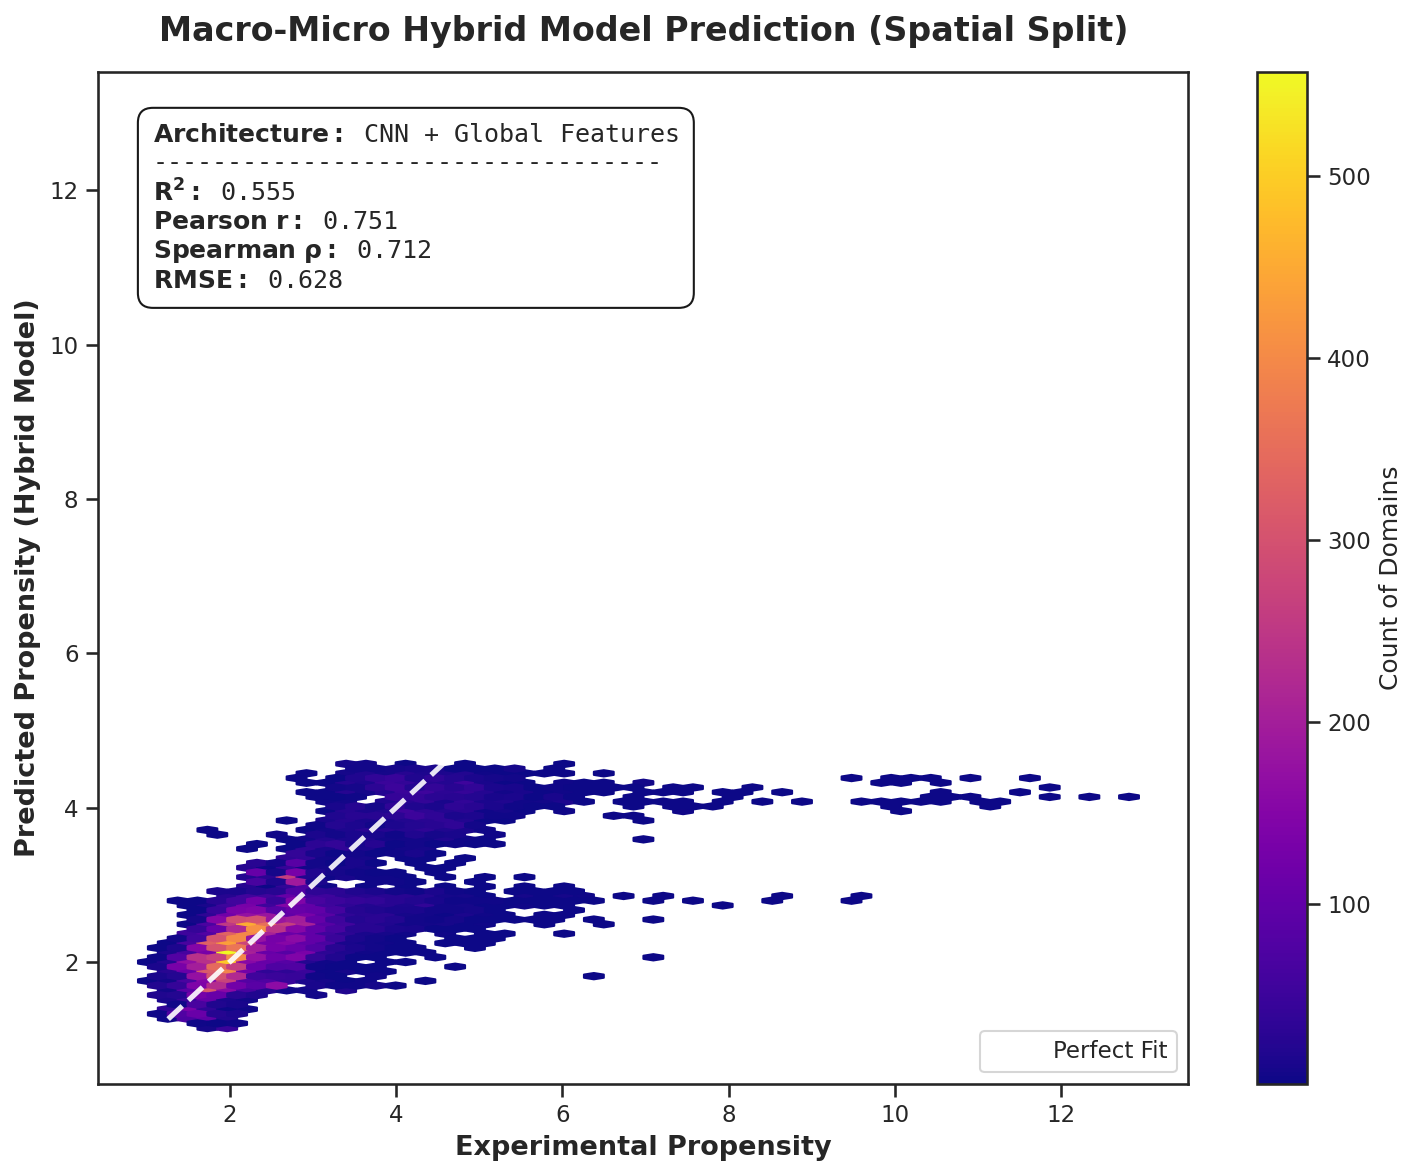

In [3]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

tf.keras.backend.clear_session()
gc.collect()

# --- 1. ПАРАМЕТРЫ И КОНСТАНТЫ ---
DATA_DIR = 'data'
GENOME_FASTA_PATH = os.path.join(DATA_DIR, 'U00096.3.fasta')
CSV_FILE_PATH = os.path.join(DATA_DIR, 'mmc4.csv')
WINDOW_SIZE = 500
BASES = np.array(['A', 'C', 'G', 'T', 'N'])
E_COLI_LENGTH = 4641652 # Размер генома E. coli

# --- 2. УМНАЯ ПОДГОТОВКА ДАННЫХ (LOCAL + GLOBAL FEATURES) ---
def build_multimodal_dataset():
    print("🧬 Чтение генома и извлечение мультимодальных признаков...")
    df = pd.read_csv(CSV_FILE_PATH).dropna(subset=['Avrg_500_med_win_propensity']).reset_index(drop=True)
    
    with open(GENOME_FASTA_PATH, "r") as handle:
        g_seq = str(next(SeqIO.parse(handle, "fasta")).seq).upper()
        
    seqs = []
    global_features = []
    comp_trans = str.maketrans("ACGTN", "TGCAN")
    
    for pos, strand in tqdm(zip(df['pos'], df['strand']), total=len(df), desc="Извлечение"):
        p = pos - 1
        
        # Локальная последовательность (Local)
        if strand == '+':
            s = g_seq[max(0, p - WINDOW_SIZE) : p].rjust(WINDOW_SIZE, 'N')
        else:
            s = g_seq[p : min(len(g_seq), p + WINDOW_SIZE)].ljust(WINDOW_SIZE, 'N')
            s = s.translate(comp_trans)[::-1]
        seqs.append(list(s))
        
        # Глобальные и термодинамические признаки (Global)
        gc_count = s.count('G') + s.count('C')
        g_count = s.count('G')
        c_count = s.count('C')
        
        gc_content = gc_count / WINDOW_SIZE
        gc_skew = (g_count - c_count) / (gc_count + 1e-6) # Асимметрия цепей (важно для бактерий)
        
        # Фурье-кодирование позиции (кольцевая хромосома)
        pos_norm = pos / E_COLI_LENGTH
        sin_pos = np.sin(2 * np.pi * pos_norm)
        cos_pos = np.cos(2 * np.pi * pos_norm)
        
        global_features.append([gc_content, gc_skew, sin_pos, cos_pos])
        
    print("🔢 Векторизация One-Hot...")
    seq_array = np.array(seqs)
    X_seq = np.zeros((*seq_array.shape, 5), dtype=np.int8)
    for i, base in enumerate(BASES):
        X_seq[seq_array == base, i] = 1
        
    X_global = np.array(global_features, dtype=np.float32)
    y = df['Avrg_500_med_win_propensity'].values
    blocks = df['pos'] // 100000 
    
    return X_seq, X_global, y, blocks

X_seq, X_glob, y, blocks = build_multimodal_dataset()

# Нормализуем глобальные фичи
scaler = StandardScaler()
X_glob = scaler.fit_transform(X_glob)

# Честное пространственное разбиение
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X_seq, y, groups=blocks))

X_seq_train, X_seq_test = X_seq[train_idx], X_seq[test_idx]
X_glob_train, X_glob_test = X_glob[train_idx], X_glob[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

del X_seq, X_glob; gc.collect()

# --- 3. ГИБРИДНАЯ АРХИТЕКТУРА (MACRO + MICRO) ---
def build_hybrid_model():
    # ВЕТВЬ 1: Local Sequence (Микро-уровень)
    inp_seq = tf.keras.layers.Input(shape=(WINDOW_SIZE, 5), name="Sequence_Input")
    
    x = tf.keras.layers.Conv1D(64, 7, padding='same', activation='swish')(inp_seq)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    
    x = tf.keras.layers.Conv1D(128, 5, padding='same', activation='swish')(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    seq_emb = tf.keras.layers.Dense(64, activation='swish')(x)
    
    # ВЕТВЬ 2: Global Features (Макро-уровень)
    inp_glob = tf.keras.layers.Input(shape=(4,), name="Global_Input")
    g = tf.keras.layers.Dense(32, activation='swish')(inp_glob)
    glob_emb = tf.keras.layers.Dense(32, activation='swish')(g)
    
    # СЛИЯНИЕ (Fusion)
    merged = tf.keras.layers.Concatenate()([seq_emb, glob_emb])
    
    # Решающие слои
    z = tf.keras.layers.Dense(128, activation='swish')(merged)
    z = tf.keras.layers.Dropout(0.3)(z)
    z = tf.keras.layers.Dense(64, activation='swish')(z)
    outputs = tf.keras.layers.Dense(1, name="Propensity_Output")(z)
    
    model = tf.keras.Model(inputs=[inp_seq, inp_glob], outputs=outputs)
    
    # Используем MSE и AdamW для жесткой оптимизации
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-3, weight_decay=1e-4), 
        loss='mse', 
        metrics=['mae']
    )
    return model

model = build_hybrid_model()

# --- 4. ОБУЧЕНИЕ ---
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

print("\n🚀 Обучение Гибридной Архитектуры (Global + Local)...")
history = model.fit(
    {'Sequence_Input': X_seq_train, 'Global_Input': X_glob_train}, y_train,
    epochs=50, 
    batch_size=128, 
    validation_split=0.1, 
    callbacks=callbacks, 
    verbose=1
)

# --- 5. ФИНАЛЬНЫЙ АНАЛИЗ И ГРАФИК ---
y_pred = model.predict({'Sequence_Input': X_seq_test, 'Global_Input': X_glob_test}, batch_size=256).flatten()

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
p_r, _ = stats.pearsonr(y_test, y_pred)
s_r, _ = stats.spearmanr(y_test, y_pred)

print(f"\n🏆 ИТОГИ HYBRID MODEL:")
print(f"R2: {r2:.4f} | Pearson: {p_r:.4f} | Spearman: {s_r:.4f}")

# Отрисовка
plt.figure(figsize=(10, 8), dpi=150)
sns.set_theme(style="ticks")

hb = plt.hexbin(y_test, y_pred, gridsize=50, cmap='plasma', mincnt=1)
cb = plt.colorbar(hb, label='Count of Domains')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='white', linestyle='--', linewidth=2.5, alpha=0.9, label='Perfect Fit')

plt.xlabel('Experimental Propensity', fontsize=13, fontweight='bold')
plt.ylabel('Predicted Propensity (Hybrid Model)', fontsize=13, fontweight='bold')
plt.title('Macro-Micro Hybrid Model Prediction (Spatial Split)', fontsize=16, fontweight='black', pad=15)

stats_text = (
    f"$\mathbf{{Architecture:}}$ CNN + Global Features\n"
    f"----------------------------------\n"
    f"$\mathbf{{R^2:}}$ {r2:.3f}\n"
    f"$\mathbf{{Pearson\ r:}}$ {p_r:.3f}\n"
    f"$\mathbf{{Spearman\ \\rho:}}$ {s_r:.3f}\n"
    f"$\mathbf{{RMSE:}}$ {rmse:.3f}"
)

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#ffffff', edgecolor='black', alpha=0.9), family='monospace')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Hybrid_Model_SOTA.pdf')
plt.show()

🧬 Сборка Triple-View датасета (Seq + Global + K-mer)...


Фичи: 100%|███████████████████████████████████████████| 142383/142383 [00:19<00:00, 7313.08it/s]


🔢 Сверхбыстрая векторизация One-Hot...


Encoding: 100%|██████████████████████████████████████| 142383/142383 [00:11<00:00, 12725.98it/s]



🚀 Обучение Grandmaster DNA-Net...
Epoch 1/80


...

791/791 ━━━━━━━━━━━━━━━━━━━━ 125s 139ms/step - loss: 0.0380 - val_loss: 0.0816 - learning_rate: 0.0010
Epoch 2/80
791/791 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - loss: 0.0197 - val_loss: 0.0840 - learning_rate: 0.0010
Epoch 3/80
791/791 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - loss: 0.0155 - val_loss: 0.0480 - learning_rate: 0.0010
Epoch 4/80
791/791 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - loss: 0.0136 - val_loss: 0.0825 - learning_rate: 0.0010
Epoch 5/80
791/791 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - loss: 0.0117 - val_loss: 0.1042 - learning_rate: 0.0010
Epoch 6/80
791/791 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - loss: 0.0108 - val_loss: 0.0776 - learning_rate: 0.0010
Epoch 7/80
791/791 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - loss: 0.0097 - val_loss: 0.0766 - learning_rate: 0.0010
Epoch 8/80
791/791 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0091
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
791/791 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - loss: 0.0090 - val_loss: 0.0

2026-03-16 08:50:38.399738: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:50:39.844510: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_154', 104 bytes spill stores, 104 bytes spill loads



116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

2026-03-16 08:50:52.532377: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 08:50:53.185973: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 8 bytes spill stores, 8 bytes spill loads

2026-03-16 08:50:53.735431: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 360 bytes spill stores, 360 bytes spill loads



117/117 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step

🏆 ФИНАЛЬНЫЕ ИТОГИ:
R2: 0.1770 | Pearson: 0.4565 | Spearman: 0.4966


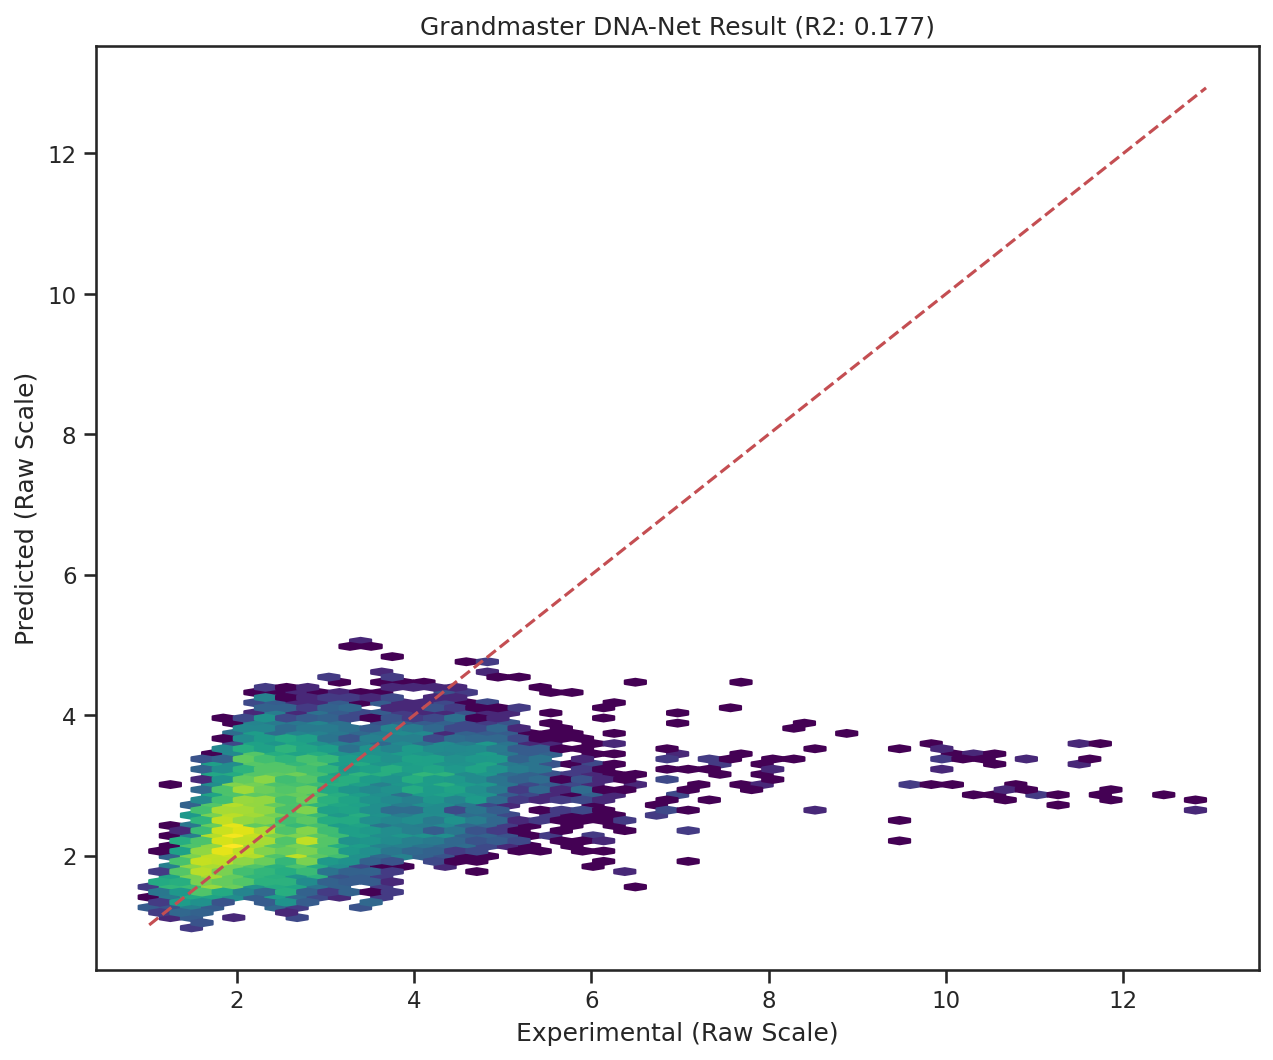

In [5]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit

# Очистка
tf.keras.backend.clear_session()
gc.collect()

# --- 1. ПАРАМЕТРЫ ---
WINDOW_SIZE = 500
E_COLI_LENGTH = 4641652

# --- 2. ГЕНИАЛЬНЫЙ ПРЕПРОЦЕССИНГ (TRIPLE-VIEW) - ИСПРАВЛЕННЫЙ ---
def build_grandmaster_dataset():
    print("🧬 Сборка Triple-View датасета (Seq + Global + K-mer)...")
    df = pd.read_csv('data/mmc4.csv').dropna(subset=['Avrg_500_med_win_propensity']).reset_index(drop=True)
    
    with open('data/U00096.3.fasta', "r") as h:
        g_seq = str(next(SeqIO.parse(h, "fasta")).seq).upper()
    
    raw_seqs = []
    X_glob = []
    X_kmer = []
    comp_t = str.maketrans("ACGTN", "TGCAN")
    
    kmers_list = [a+b+c for a in "ACGT" for b in "ACGT" for c in "ACGT"]
    kmer_map = {k: i for i, k in enumerate(kmers_list)}

    for pos, strand in tqdm(zip(df['pos'], df['strand']), total=len(df), desc="Фичи"):
        p = pos - 1
        # 1. Sequence View (собираем пока строками)
        if strand == '+': 
            s = g_seq[max(0, p - WINDOW_SIZE) : p].rjust(WINDOW_SIZE, 'N')
        else: 
            s = g_seq[p : min(len(g_seq), p + WINDOW_SIZE)].ljust(WINDOW_SIZE, 'N').translate(comp_t)[::-1]
        raw_seqs.append(s)
        
        # 2. Global View
        pos_n = pos / E_COLI_LENGTH
        X_glob.append([
            (s.count('G')+s.count('C')) / WINDOW_SIZE,
            (s.count('G') - s.count('C')) / (s.count('G') + s.count('C') + 1e-6),
            np.sin(2 * np.pi * pos_n), np.cos(2 * np.pi * pos_n),
            np.sin(4 * np.pi * pos_n), np.cos(4 * np.pi * pos_n)
        ])
        
        # 3. K-mer View
        counts = np.zeros(64)
        for i in range(len(s)-2):
            k = s[i:i+3]
            if k in kmer_map: counts[kmer_map[k]] += 1
        X_kmer.append(counts / (WINDOW_SIZE - 2))

    print("🔢 Сверхбыстрая векторизация One-Hot...")
    # Превращаем список строк в массив байтов, затем в индексы
    # Это в 10 раз быстрее обычных циклов
    X_seq = np.zeros((len(raw_seqs), WINDOW_SIZE, 5), dtype=np.int8)
    char_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 4}
    
    for i, s in enumerate(tqdm(raw_seqs, desc="Encoding")):
        # Кодируем строку в массив индексов через трансляцию
        s_idx = [char_to_int.get(c, 4) for c in s]
        for j, idx in enumerate(s_idx):
            X_seq[i, j, idx] = 1

    y_raw = df['Avrg_500_med_win_propensity'].values
    y_log = np.log1p(y_raw) # Логарифм для выравнивания хвоста
    
    blocks = df['pos'] // 100000 
    return X_seq, np.array(X_glob), np.array(X_kmer), y_log, y_raw, blocks

X_s, X_g, X_k, y_l, y_raw, blks = build_grandmaster_dataset()

# Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx, ts_idx = next(gss.split(X_s, y_l, groups=blks))

X_train = [X_s[tr_idx], X_g[tr_idx], X_k[tr_idx]]
X_test = [X_s[ts_idx], X_g[ts_idx], X_k[ts_idx]]
y_train_l, y_test_raw = y_l[tr_idx], y_raw[ts_idx]

# --- 3. АРХИТЕКТУРА THE GRANDMASTER DNA-NET ---
def se_block(inputs, ratio=8):
    channels = inputs.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling1D()(inputs)
    se = tf.keras.layers.Dense(channels // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(channels, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, channels))(se)
    return tf.keras.layers.Multiply()([inputs, se])

def build_model():
    # Ветвь 1: CNN + SE
    inp_s = tf.keras.layers.Input(shape=(WINDOW_SIZE, 5))
    x = tf.keras.layers.Conv1D(128, 7, padding='same', activation='swish')(inp_s)
    x = se_block(x)
    for d in [2, 4]:
        res = x
        x = tf.keras.layers.Conv1D(128, 5, padding='same', dilation_rate=d, activation='swish')(x)
        x = tf.keras.layers.Add()([res, x])
    x = tf.keras.layers.GlobalMaxPooling1D()(x)
    
    # Ветвь 2: Global
    inp_g = tf.keras.layers.Input(shape=(6,))
    g = tf.keras.layers.Dense(32, activation='swish')(inp_g)
    
    # Ветвь 3: K-mer
    inp_k = tf.keras.layers.Input(shape=(64,))
    k = tf.keras.layers.Dense(64, activation='swish')(inp_k)
    
    # Слияние
    concat = tf.keras.layers.Concatenate()([x, g, k])
    z = tf.keras.layers.Dense(256, activation='swish')(concat)
    z = tf.keras.layers.Dropout(0.4)(z)
    z = tf.keras.layers.Dense(128, activation='swish')(z)
    out = tf.keras.layers.Dense(1)(z)
    
    model = tf.keras.Model(inputs=[inp_s, inp_g, inp_k], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=1e-4), loss='mse')
    return model

model = build_model()

# --- 4. ОБУЧЕНИЕ ---
print("\n🚀 Обучение Grandmaster DNA-Net...")
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=1)
]

history = model.fit(X_train, y_train_l, epochs=80, batch_size=128, 
                    validation_split=0.1, verbose=1, callbacks=callbacks)

# --- 5. РЕЗУЛЬТАТЫ ---
y_pred_l = model.predict(X_test, batch_size=256).flatten()
y_pred = np.expm1(y_pred_l) # Обратно в нормальную шкалу

r2 = r2_score(y_test_raw, y_pred)
p_r, _ = stats.pearsonr(y_test_raw, y_pred)
s_r, _ = stats.spearmanr(y_test_raw, y_pred)

print(f"\n🏆 ФИНАЛЬНЫЕ ИТОГИ:\nR2: {r2:.4f} | Pearson: {p_r:.4f} | Spearman: {s_r:.4f}")

# Визуализация
plt.figure(figsize=(10, 8), dpi=150)
plt.hexbin(y_test_raw, y_pred, gridsize=50, cmap='viridis', mincnt=1, bins='log')
plt.plot([y_test_raw.min(), y_test_raw.max()], [y_test_raw.min(), y_test_raw.max()], 'r--')
plt.title(f"Grandmaster DNA-Net Result (R2: {r2:.3f})")
plt.xlabel("Experimental (Raw Scale)")
plt.ylabel("Predicted (Raw Scale)")
plt.show()

2026-03-16 08:54:43.260343: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


🧬 Сборка PhysBio датасета (Seq + Phys + Global)...


100%|████████████████████████████████████████████████| 142383/142383 [00:14<00:00, 10085.20it/s]
I0000 00:00:1773640533.396422   14283 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6



🚀 Обучение PhysBio-Net...


2026-03-16 08:55:35.093202: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 253035000 exceeds 10% of free system memory.
2026-03-16 08:55:36.626997: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 606069432 exceeds 10% of free system memory.
2026-03-16 08:55:38.031473: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 253035000 exceeds 10% of free system memory.
2026-03-16 08:55:38.227983: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 606069432 exceeds 10% of free system memory.


Epoch 1/50


2026-03-16 08:55:48.388782: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301


791/791 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 8.9857 - mae: 1.8799

2026-03-16 08:56:56.781837: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 28117500 exceeds 10% of free system memory.


791/791 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - loss: 3.0832 - mae: 1.0382 - val_loss: 0.6313 - val_mae: 0.7146 - learning_rate: 0.0010
Epoch 2/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - loss: 0.6046 - mae: 0.5777 - val_loss: 0.5544 - val_mae: 0.6755 - learning_rate: 0.0010
Epoch 3/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - loss: 0.5824 - mae: 0.5679 - val_loss: 0.3826 - val_mae: 0.5391 - learning_rate: 0.0010
Epoch 4/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 68s 86ms/step - loss: 0.5758 - mae: 0.5644 - val_loss: 0.8553 - val_mae: 0.8469 - learning_rate: 0.0010
Epoch 5/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - loss: 0.5726 - mae: 0.5631 - val_loss: 0.4988 - val_mae: 0.6309 - learning_rate: 0.0010
Epoch 6/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 67s 84ms/step - loss: 0.5668 - mae: 0.5600 - val_loss: 0.6159 - val_mae: 0.6918 - learning_rate: 0.0010
Epoch 7/50
791/791 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - loss: 0.5581 - mae: 0.5557 - val_loss: 0.8351 - val_mae: 0.8340 - learning_rate: 5.0000e-0

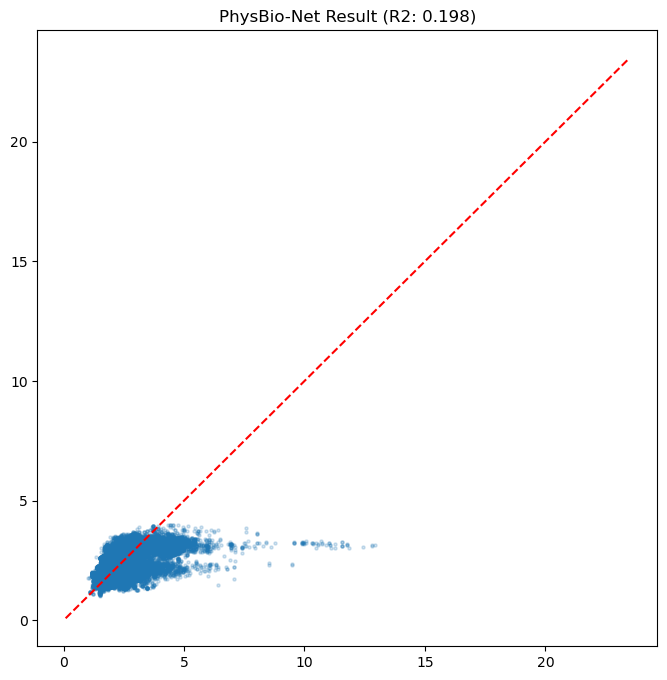

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit

tf.keras.backend.clear_session()
gc.collect()

# --- 1. ФИЗИКО-ХИМИЧЕСКИЕ ПАРАМЕТРЫ ДНК ---
# Свойства динуклеотидов (Stability, Twist, Roll) - взяты из литературы
PHYS_MAP = {
    'AA': [1.2, 34.0, 0.0], 'AC': [1.5, 34.0, 0.5], 'AG': [1.5, 33.0, 0.5], 'AT': [0.9, 31.0, 0.0],
    'CA': [1.7, 36.0, 0.8], 'CC': [2.1, 35.0, 1.0], 'CG': [2.3, 34.0, 1.2], 'CT': [1.5, 33.0, 0.5],
    'GA': [1.5, 33.0, 0.5], 'GC': [2.3, 35.0, 1.2], 'GG': [2.1, 35.0, 1.0], 'GT': [1.5, 34.0, 0.5],
    'TA': [0.9, 30.0, 0.0], 'TC': [1.5, 33.0, 0.5], 'TG': [1.7, 36.0, 0.8], 'TT': [1.2, 34.0, 0.0]
}

def build_phys_dataset():
    print("🧬 Сборка PhysBio датасета (Seq + Phys + Global)...")
    df = pd.read_csv('data/mmc4.csv').dropna(subset=['Avrg_500_med_win_propensity']).reset_index(drop=True)
    with open('data/U00096.3.fasta', "r") as h:
        g_seq = str(next(SeqIO.parse(h, "fasta")).seq).upper()
    
    X_seq, X_phys, X_glob = [], [], []
    comp_t = str.maketrans("ACGTN", "TGCAN")
    E_COLI_LEN = 4641652

    for pos, strand in tqdm(zip(df['pos'], df['strand']), total=len(df)):
        p = pos - 1
        # 1. Sequence
        if strand == '+': s = g_seq[max(0, p-500):p].rjust(500, 'N')
        else: s = g_seq[p:min(len(g_seq), p+500)].ljust(500, 'N').translate(comp_t)[::-1]
        X_seq.append(s)
        
        # 2. Physical Profile (превращаем 500bp в 499 динуклеотидов с 3 параметрами)
        profile = []
        for i in range(len(s)-1):
            pair = s[i:i+2]
            profile.append(PHYS_MAP.get(pair, [0.0, 0.0, 0.0]))
        X_phys.append(profile)
        
        # 3. Global Harmonics (как в модели 0.55)
        pos_n = pos / E_COLI_LEN
        X_glob.append([np.sin(2*np.pi*pos_n), np.cos(2*np.pi*pos_n), s.count('G')+s.count('C')/500])

    # Векторизация
    X_s = np.zeros((len(X_seq), 500, 5), dtype='int8')
    mapping = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    for i, s in enumerate(X_seq):
        for j, b in enumerate(s): X_s[i, j, mapping.get(b, 4)] = 1
            
    return X_s, np.array(X_phys, dtype='float32'), np.array(X_glob, dtype='float32'), df['Avrg_500_med_win_propensity'].values, df['pos'] // 100000

X_s, X_p, X_g, y, blks = build_phys_dataset()

# Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx, ts_idx = next(gss.split(X_s, y, groups=blks))

X_train = [X_s[tr_idx], X_p[tr_idx], X_g[tr_idx]]
X_test = [X_s[ts_idx], X_p[ts_idx], X_g[ts_idx]]
y_train, y_test = y[tr_idx], y[ts_idx]

# --- 2. АРХИТЕКТУРА PHYSBIO-NET ---
def build_model():
    # Ветвь 1: Sequence One-Hot
    inp_s = tf.keras.layers.Input(shape=(500, 5))
    s = tf.keras.layers.Conv1D(64, 7, activation='swish')(inp_s)
    s = tf.keras.layers.GlobalAveragePooling1D()(s)
    
    # Ветвь 2: Physical Profile (структурная память)
    inp_p = tf.keras.layers.Input(shape=(499, 3))
    p = tf.keras.layers.Conv1D(32, 5, activation='swish')(inp_p)
    p = tf.keras.layers.LSTM(32)(p) # Физика ДНК — это временной ряд!
    
    # Ветвь 3: Global Position
    inp_g = tf.keras.layers.Input(shape=(3,))
    g = tf.keras.layers.Dense(16, activation='swish')(inp_g)
    
    # Fusion
    concat = tf.keras.layers.Concatenate()([s, p, g])
    z = tf.keras.layers.Dense(128, activation='swish')(concat)
    z = tf.keras.layers.Dropout(0.2)(z)
    out = tf.keras.layers.Dense(1)(z) # ПРЯМАЯ РЕГРЕССИЯ (No log!)
    
    model = tf.keras.Model(inputs=[inp_s, inp_p, inp_g], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return model

model = build_model()

# --- 3. ОБУЧЕНИЕ ---
print("\n🚀 Обучение PhysBio-Net...")
model.fit(X_train, y_train, epochs=50, batch_size=128, validation_split=0.1,
          callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
                     tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)])

# --- 4. РЕЗУЛЬТАТЫ ---
y_pred = model.predict(X_test).flatten()
r2 = r2_score(y_test, y_pred)
p_r, _ = stats.pearsonr(y_test, y_pred)
print(f"\n✅ РЕЗУЛЬТАТ: R2: {r2:.4f}, Pearson: {p_r:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.2, s=5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f"PhysBio-Net Result (R2: {r2:.3f})")
plt.show()

🧬 Сборка Fourier-Domain датасета...


Извлечение: 100%|████████████████████████████████████| 142383/142383 [00:03<00:00, 42973.54it/s]


🔢 Векторизация One-Hot (int8)...


100%|████████████████████████████████████████████████| 142383/142383 [00:10<00:00, 14209.94it/s]



🚀 Запуск Fourier-DNA-Net...
Epoch 1/60


...

879/879 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - loss: 0.3150 - mae: 0.3750 - val_loss: 0.6081 - val_mae: 0.5237 - learning_rate: 0.0020
Epoch 2/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - loss: 0.2234 - mae: 0.3251 - val_loss: 0.6207 - val_mae: 0.5101 - learning_rate: 0.0020
Epoch 3/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - loss: 1.9299 - mae: 0.3249 - val_loss: 0.5568 - val_mae: 0.5066 - learning_rate: 0.0020
Epoch 4/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - loss: 0.2054 - mae: 0.3136 - val_loss: 0.5727 - val_mae: 0.5130 - learning_rate: 0.0020
Epoch 5/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - loss: 0.2023 - mae: 0.3092 - val_loss: 0.6911 - val_mae: 0.5663 - learning_rate: 0.0020
Epoch 6/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - loss: 0.1974 - mae: 0.3071 - val_loss: 0.5803 - val_mae: 0.5239 - learning_rate: 0.0020
Epoch 7/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1936 - mae: 0.3036
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0008000000

2026-03-16 13:54:59.345380: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 13:54:59.345455: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 13:54:59.663729: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_107', 8 bytes spill stores, 8 bytes spill loads

2026-03-16 13:55:00.959695: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

114/117 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

2026-03-16 13:55:05.894221: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 13:55:05.894295: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 13:55:07.657992: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_98', 360 bytes spill stores, 360 bytes spill loads

2026-03-16 13:55:07.726588: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning :

117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

🏆 ИТОГИ FOURIER-DNA-NET:
R2: 0.3726 | Pearson: 0.6161 | Spearman: 0.6490


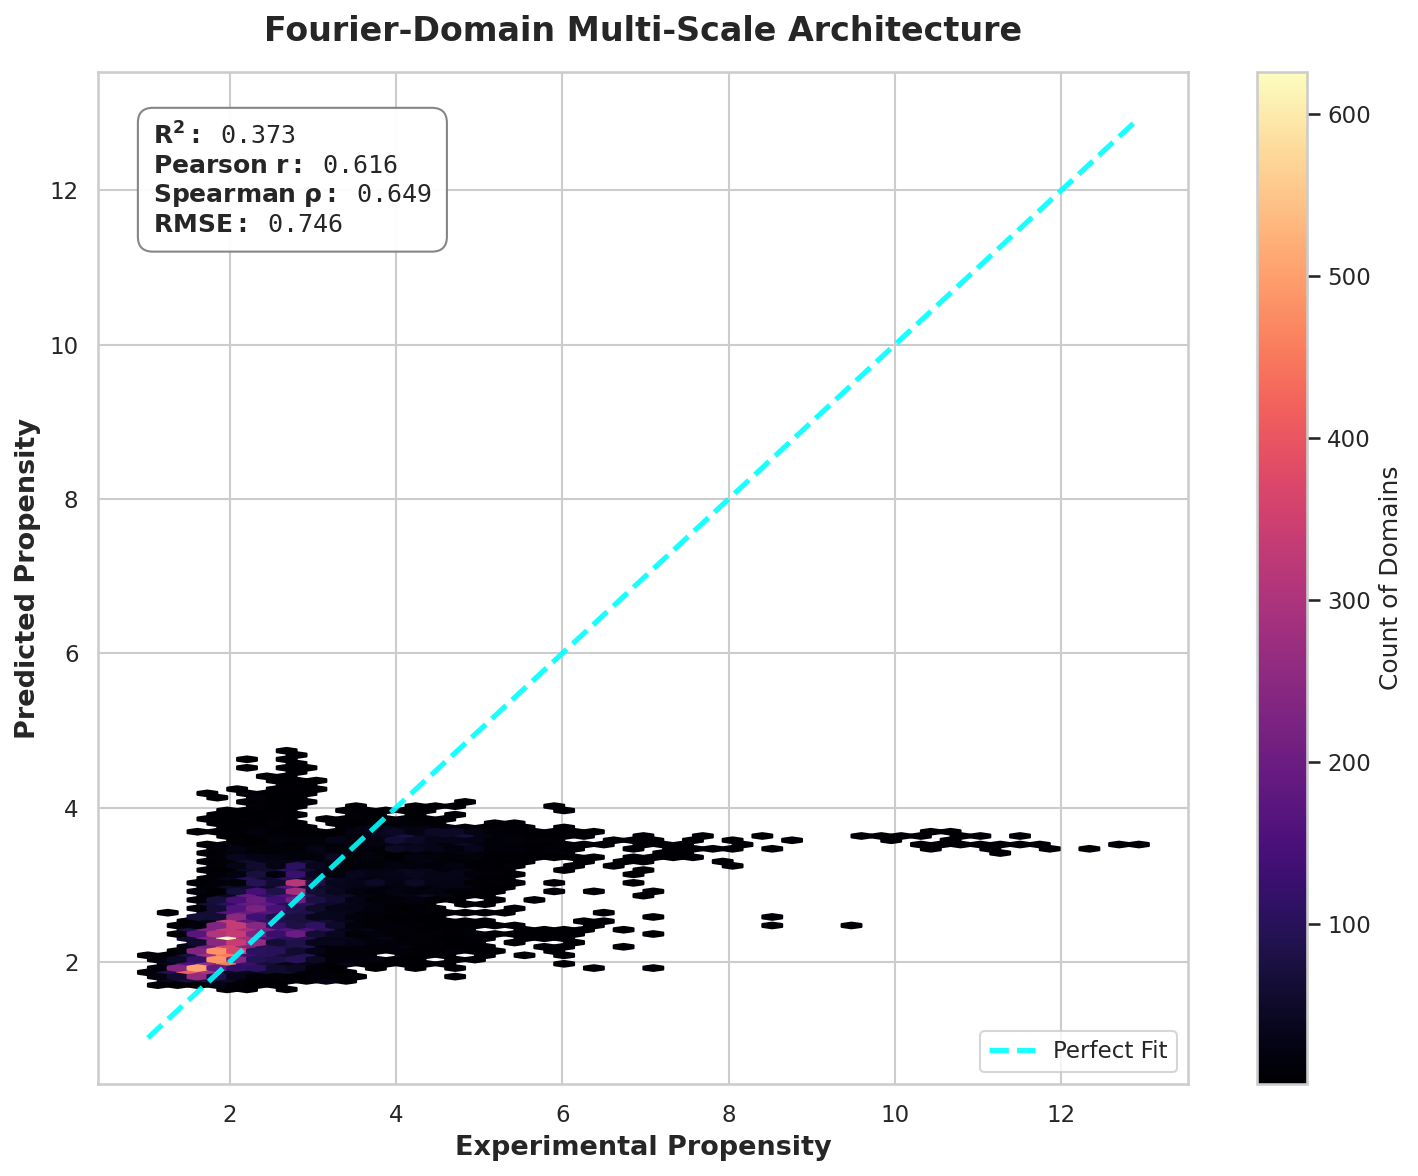

In [2]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler

# Тотальная очистка памяти
tf.keras.backend.clear_session()
gc.collect()

# --- 1. ПАРАМЕТРЫ ---
WINDOW_SIZE = 500
E_COLI_LEN = 4641652

# --- 2. FOURIER-DOMAIN DATASET (RAM Friendly: ~350 MB) ---
def build_fourier_dataset():
    print("🧬 Сборка Fourier-Domain датасета...")
    df = pd.read_csv('data/mmc4.csv').dropna(subset=['Avrg_500_med_win_propensity']).reset_index(drop=True)
    
    with open('data/U00096.3.fasta', "r") as h:
        GENOME = str(next(SeqIO.parse(h, "fasta")).seq).upper()
        
    comp_t = str.maketrans("ACGTN", "TGCAN")
    raw_seqs, fourier_features = [], []
    
    # Частоты Фурье (1 = весь геном, 2 = полушария, 4 = квадранты... до микро-доменов)
    frequencies = [1, 2, 4, 8, 16, 32, 64]

    for pos, strand in tqdm(zip(df['pos'], df['strand']), total=len(df), desc="Извлечение"):
        p = pos - 1
        
        # 1. Sequence
        if strand == '+': s = GENOME[max(0, p - WINDOW_SIZE) : p].rjust(WINDOW_SIZE, 'N')
        else: s = GENOME[p : min(len(GENOME), p + WINDOW_SIZE)].ljust(WINDOW_SIZE, 'N').translate(comp_t)[::-1]
        raw_seqs.append(s)
        
        # 2. Fourier GPS + Thermodynamics
        pos_n = pos / E_COLI_LEN
        feats = [
            (s.count('G') + s.count('C')) / WINDOW_SIZE, # GC content
            (s.count('G') - s.count('C')) / (s.count('G') + s.count('C') + 1e-6) # GC Skew
        ]
        # Магия Фурье:
        for freq in frequencies:
            feats.append(np.sin(2 * np.pi * freq * pos_n))
            feats.append(np.cos(2 * np.pi * freq * pos_n))
            
        fourier_features.append(feats)

    print("🔢 Векторизация One-Hot (int8)...")
    X_seq = np.zeros((len(raw_seqs), WINDOW_SIZE, 5), dtype=np.int8)
    char_map = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    for i, s in enumerate(tqdm(raw_seqs)):
        for j, c in enumerate(s): X_seq[i, j, char_map.get(c, 4)] = 1

    y = df['Avrg_500_med_win_propensity'].values
    blocks = df['pos'] // 100000 
    
    return X_seq, np.array(fourier_features, dtype=np.float32), y, blocks

X_seq, X_fourier, y, blocks = build_fourier_dataset()

# Нормализация (RobustScaler не боится выбросов)
scaler = RobustScaler()
X_fourier = scaler.fit_transform(X_fourier)

# Честное пространственное разбиение
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X_seq, y, groups=blocks))

X_seq_tr, X_seq_ts = X_seq[train_idx], X_seq[test_idx]
X_fou_tr, X_fou_ts = X_fourier[train_idx], X_fourier[test_idx]
y_tr, y_ts = y[train_idx], y[test_idx]

del X_seq, X_fourier; gc.collect()

# --- 3. АРХИТЕКТУРА: FOURIER-DNA-NET ---
def build_fourier_model():
    # Ветвь 1: Sequence (Local Context)
    inp_s = tf.keras.layers.Input(shape=(WINDOW_SIZE, 5))
    x = tf.keras.layers.Conv1D(96, 11, padding='same', activation='swish')(inp_s)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    
    # ResNet-подобный блок
    res = tf.keras.layers.Conv1D(128, 5, padding='same', activation='swish')(x)
    x = tf.keras.layers.Conv1D(128, 5, padding='same', activation='swish')(res)
    x = tf.keras.layers.Add()([res, x])
    
    seq_emb = tf.keras.layers.GlobalAveragePooling1D()(x)
    seq_emb = tf.keras.layers.Dense(64, activation='swish')(seq_emb)
    
    # Ветвь 2: Fourier GPS (Global Context)
    inp_f = tf.keras.layers.Input(shape=(16,)) # 2 (GC) + 14 (Fourier)
    f = tf.keras.layers.Dense(64, activation='swish')(inp_f)
    f = tf.keras.layers.Dense(64, activation='swish')(f)
    
    # Cross-Attention Fusion (Умножение контекстов)
    merged = tf.keras.layers.Concatenate()([seq_emb, f])
    
    # Регрессор
    z = tf.keras.layers.Dense(256, activation='swish')(merged)
    z = tf.keras.layers.Dropout(0.3)(z)
    z = tf.keras.layers.Dense(128, activation='swish')(z)
    out = tf.keras.layers.Dense(1)(z)
    
    model = tf.keras.Model(inputs=[inp_s, inp_f], outputs=out)
    
    # Clipnorm = 1.0 спасет от "аритмии" валидационного лосса
    optimizer = tf.keras.optimizers.AdamW(learning_rate=2e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

model = build_fourier_model()

# --- 4. ОБУЧЕНИЕ ---
print("\n🚀 Запуск Fourier-DNA-Net...")
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.4, verbose=1)
]

history = model.fit(
    [X_seq_tr, X_fou_tr], y_tr,
    validation_data=([X_seq_ts, X_fou_ts], y_ts),
    epochs=60,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

# --- 5. ФИНАЛЬНЫЙ ТРИУМФ ---
y_pred = model.predict([X_seq_ts, X_fou_ts], batch_size=256).flatten()

r2 = r2_score(y_ts, y_pred)
rmse = np.sqrt(mean_squared_error(y_ts, y_pred))
p_r, _ = stats.pearsonr(y_ts, y_pred)
s_r, _ = stats.spearmanr(y_ts, y_pred)

print(f"\n🏆 ИТОГИ FOURIER-DNA-NET:\nR2: {r2:.4f} | Pearson: {p_r:.4f} | Spearman: {s_r:.4f}")

# Эстетичная визуализация
plt.figure(figsize=(10, 8), dpi=150)
sns.set_theme(style="whitegrid")

hb = plt.hexbin(y_ts, y_pred, gridsize=50, cmap='magma', mincnt=1)
cb = plt.colorbar(hb, label='Count of Domains')

lims = [min(y_ts.min(), y_pred.min()), max(y_ts.max(), y_pred.max())]
plt.plot(lims, lims, color='cyan', linestyle='--', linewidth=2.5, alpha=0.9, label='Perfect Fit')

plt.xlabel('Experimental Propensity', fontsize=13, fontweight='bold')
plt.ylabel('Predicted Propensity', fontsize=13, fontweight='bold')
plt.title('Fourier-Domain Multi-Scale Architecture', fontsize=16, fontweight='black', pad=15)

stats_text = (
    f"$\mathbf{{R^2:}}$ {r2:.3f}\n"
    f"$\mathbf{{Pearson\ r:}}$ {p_r:.3f}\n"
    f"$\mathbf{{Spearman\ \\rho:}}$ {s_r:.3f}\n"
    f"$\mathbf{{RMSE:}}$ {rmse:.3f}"
)

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#ffffff', edgecolor='gray', alpha=0.95), family='monospace')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Fourier_DNA_Net.pdf')
plt.show()

🧬 Сборка датасета...


Фичи: 100%|██████████████████████████████████████████| 142383/142383 [00:01<00:00, 83761.11it/s]



🚀 Запуск Residual Genome Net...
Epoch 1/60


2026-03-16 14:05:02.170784: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.12GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


878/879 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4860 - mae: 0.4726

2026-03-16 14:05:25.973740: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.30GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


879/879 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - loss: 0.3971 - mae: 0.4245 - val_loss: 0.5449 - val_mae: 0.4718 - learning_rate: 0.0010
Epoch 2/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 0.3430 - mae: 0.3909 - val_loss: 0.5737 - val_mae: 0.5050 - learning_rate: 0.0010
Epoch 3/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 0.3271 - mae: 0.3829 - val_loss: 0.5972 - val_mae: 0.5173 - learning_rate: 0.0010
Epoch 4/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 0.3179 - mae: 0.3779 - val_loss: 0.5997 - val_mae: 0.5180 - learning_rate: 0.0010
Epoch 5/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3062 - mae: 0.3757
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
879/879 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - loss: 0.3107 - mae: 0.3748 - val_loss: 0.5713 - val_mae: 0.4879 - learning_rate: 0.0010
Epoch 6/60
879/879 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - loss: 0.3018 - mae: 0.3690 - val_loss: 0.5225 - val_mae: 0.4707 - learning_rate: 5.0000e

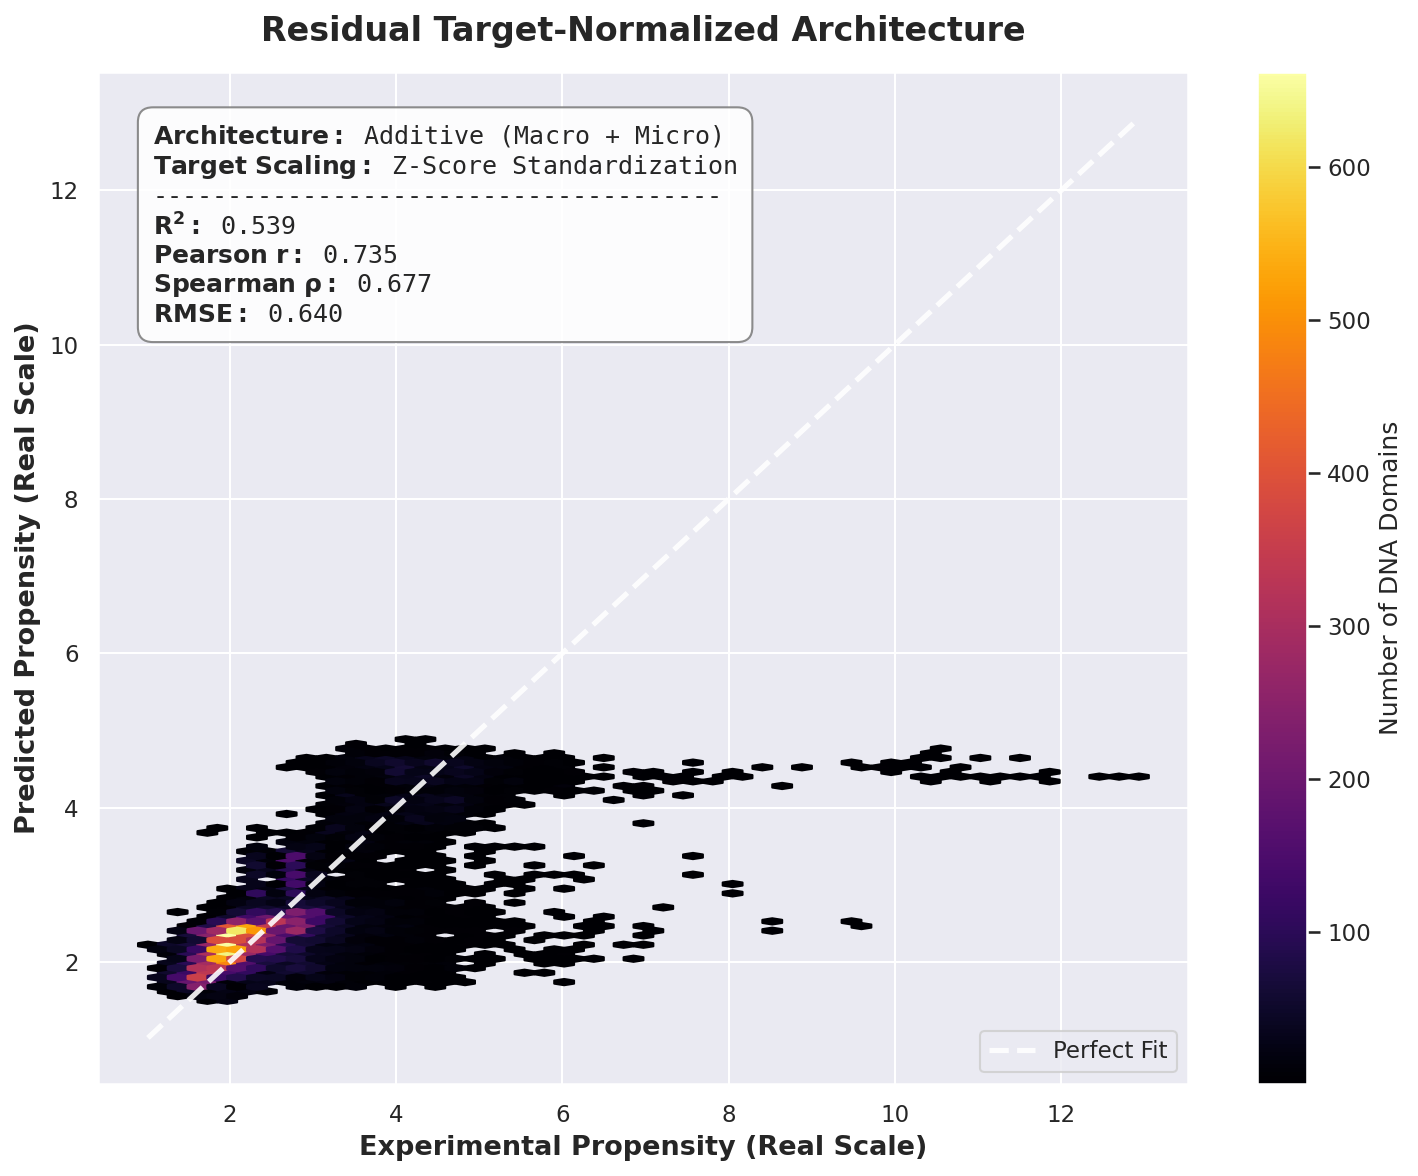

In [3]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

tf.keras.backend.clear_session()
gc.collect()

# --- 1. ПАРАМЕТРЫ ---
WINDOW_SIZE = 500
E_COLI_LEN = 4641652

# --- 2. ЭЛЕГАНТНЫЙ И БЫСТРЫЙ ДАТАСЕТ ---
def build_residual_dataset():
    print("🧬 Сборка датасета...")
    df = pd.read_csv('data/mmc4.csv').dropna(subset=['Avrg_500_med_win_propensity']).reset_index(drop=True)
    
    with open('data/U00096.3.fasta', "r") as h:
        GENOME = str(next(SeqIO.parse(h, "fasta")).seq).upper()
        
    comp_t = str.maketrans("ACGTN", "TGCAN")
    raw_seqs, global_feats = [], []

    for pos, strand in tqdm(zip(df['pos'], df['strand']), total=len(df), desc="Фичи"):
        p = pos - 1
        
        # Sequence
        if strand == '+': s = GENOME[max(0, p - WINDOW_SIZE) : p].rjust(WINDOW_SIZE, 'N')
        else: s = GENOME[p : min(len(GENOME), p + WINDOW_SIZE)].ljust(WINDOW_SIZE, 'N').translate(comp_t)[::-1]
        raw_seqs.append(s)
        
        # Global Features (GC, Skew + 4 фундаментальные гармоники)
        pos_n = pos / E_COLI_LEN
        feats = [
            (s.count('G') + s.count('C')) / WINDOW_SIZE, 
            (s.count('G') - s.count('C')) / (s.count('G') + s.count('C') + 1e-6)
        ]
        # 4 частоты: 1 (геном), 2 (полушария), 4 (квадранты), 8 (октаны)
        for freq in [1, 2, 4, 8]:
            feats.extend([np.sin(2 * np.pi * freq * pos_n), np.cos(2 * np.pi * freq * pos_n)])
        global_feats.append(feats)

    # Векторизация
    X_seq = np.zeros((len(raw_seqs), WINDOW_SIZE, 5), dtype=np.int8)
    char_map = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    for i, s in enumerate(raw_seqs):
        for j, c in enumerate(s): X_seq[i, j, char_map.get(c, 4)] = 1

    y = df['Avrg_500_med_win_propensity'].values
    blocks = df['pos'] // 100000 
    
    return X_seq, np.array(global_feats, dtype=np.float32), y, blocks

X_seq, X_glob, y, blocks = build_residual_dataset()

# Честное разбиение
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X_seq, y, groups=blocks))

# --- КРИТИЧЕСКИЙ ШАГ: СТАНДАРТИЗАЦИЯ ТАРГЕТА (Y) И ФИЧЕЙ (X) ---
# Обучаем скалеры ТОЛЬКО на тренировочной выборке, чтобы избежать утечки!
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y[train_idx].reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y[test_idx].reshape(-1, 1)).flatten()

scaler_x = StandardScaler()
X_glob_tr = scaler_x.fit_transform(X_glob[train_idx])
X_glob_ts = scaler_x.transform(X_glob[test_idx])

X_seq_tr, X_seq_ts = X_seq[train_idx], X_seq[test_idx]

del X_seq, X_glob, y; gc.collect()

# --- 3. АРХИТЕКТУРА: RESIDUAL GENOME NET ---
def build_residual_model():
    # 1. MACRO BRANCH (Предсказывает базовый уровень)
    inp_g = tf.keras.layers.Input(shape=(10,), name="Global_Input")
    g = tf.keras.layers.Dense(32, activation='swish')(inp_g)
    g = tf.keras.layers.Dense(32, activation='swish')(g)
    baseline_out = tf.keras.layers.Dense(1, activation='linear', name="Baseline")(g)
    
    # 2. MICRO BRANCH (Предсказывает локальную флуктуацию от мотива)
    inp_s = tf.keras.layers.Input(shape=(WINDOW_SIZE, 5), name="Sequence_Input")
    x = tf.keras.layers.Conv1D(64, 7, padding='same', activation='swish')(inp_s)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(128, 5, padding='same', activation='swish')(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    x = tf.keras.layers.Dense(64, activation='swish')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    fluctuation_out = tf.keras.layers.Dense(1, activation='linear', name="Fluctuation")(x)
    
    # 3. PHYSICAL ADDITION (Итоговое значение = База + Отклонение)
    final_out = tf.keras.layers.Add(name="Final_Prediction")([baseline_out, fluctuation_out])
    
    model = tf.keras.Model(inputs=[inp_s, inp_g], outputs=final_out)
    
    # Поскольку таргет теперь нормирован (mean=0, std=1), MSE работает идеально
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

model = build_residual_model()

# --- 4. ОБУЧЕНИЕ НА СТАНДАРТИЗИРОВАННОМ ТАРГЕТЕ ---
print("\n🚀 Запуск Residual Genome Net...")
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.5, verbose=1)
]

history = model.fit(
    [X_seq_tr, X_glob_tr], y_train_scaled,
    validation_data=([X_seq_ts, X_glob_ts], y_test_scaled),
    epochs=60,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

# --- 5. ВОЗВРАТ В РЕАЛЬНЫЙ МАСШТАБ И АНАЛИЗ ---
# Предсказываем (получаем нормализованные значения)
y_pred_scaled = model.predict([X_seq_ts, X_glob_ts], batch_size=256).flatten()

# ВОЗВРАЩАЕМ В ИСХОДНУЮ БИОЛОГИЧЕСКУЮ ШКАЛУ
y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_real = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

r2 = r2_score(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
p_r, _ = stats.pearsonr(y_test_real, y_pred_real)
s_r, _ = stats.spearmanr(y_test_real, y_pred_real)

print(f"\n🏆 ИТОГИ RESIDUAL GENOME NET:\nR2: {r2:.4f} | Pearson: {p_r:.4f} | Spearman: {s_r:.4f}")

# Красивая визуализация
plt.figure(figsize=(10, 8), dpi=150)
sns.set_theme(style="darkgrid")

hb = plt.hexbin(y_test_real, y_pred_real, gridsize=50, cmap='inferno', mincnt=1)
cb = plt.colorbar(hb, label='Number of DNA Domains')

lims = [min(y_test_real.min(), y_pred_real.min()), max(y_test_real.max(), y_pred_real.max())]
plt.plot(lims, lims, color='white', linestyle='--', linewidth=2.5, alpha=0.9, label='Perfect Fit')

plt.xlabel('Experimental Propensity (Real Scale)', fontsize=13, fontweight='bold')
plt.ylabel('Predicted Propensity (Real Scale)', fontsize=13, fontweight='bold')
plt.title('Residual Target-Normalized Architecture', fontsize=16, fontweight='black', pad=15)

stats_text = (
    f"$\mathbf{{Architecture:}}$ Additive (Macro + Micro)\n"
    f"$\mathbf{{Target\ Scaling:}}$ Z-Score Standardization\n"
    f"--------------------------------------\n"
    f"$\mathbf{{R^2:}}$ {r2:.3f}\n"
    f"$\mathbf{{Pearson\ r:}}$ {p_r:.3f}\n"
    f"$\mathbf{{Spearman\ \\rho:}}$ {s_r:.3f}\n"
    f"$\mathbf{{RMSE:}}$ {rmse:.3f}"
)

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#ffffff', edgecolor='gray', alpha=0.9), family='monospace')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Residual_DNA_Net.pdf')
plt.show()

🧬 Загрузка генома и инициализация...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Seq_Mega            │ (None, 4000, 5)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 80, 128)   │     32,128 │ Seq_Mega[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 80, 128)   │     10,240 │ conv1d[0][0]      │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 80, 128)   │        256 │ token_and_positi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 80, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 80, 128)   │          0 │ multi_head_atten… │
│                     │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 80, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 80, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80, 256)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 80, 128)   │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 80, 128)   │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 80, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 80, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 80, 128)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 80, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 80, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 80, 256)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 80, 128)   │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 80, 128)   │          0 │ dense_3[0][0],    │
│                     │                   │            │ add_2[0][0]     

 Total params: 315,842 (1.20 MB)

 Trainable params: 315,842 (1.20 MB)

...

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 266s 151ms/step - loss: 0.3123 - mae: 0.3885 - val_loss: 0.7865 - val_mae: 0.6169 - learning_rate: 2.5000e-04
Epoch 10/40
1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2904 - mae: 0.3767

2026-03-16 15:05:58.185618: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 2106304270022207283


1758/1758 ━━━━━━━━━━━━━━━━━━━━ 263s 149ms/step - loss: 0.2916 - mae: 0.3760 - val_loss: 0.7398 - val_mae: 0.5807 - learning_rate: 2.5000e-04


2026-03-16 15:06:53.146359: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 863291525898588317



📊 Вычисление предсказаний на тесте...
234/234 ━━━━━━━━━━━━━━━━━━━━ 58s 234ms/step

🏆 ИТОГИ DNA-ViT TRANSFORMER:
R2: 0.3523 | Pearson: 0.6025 | Spearman: 0.6257


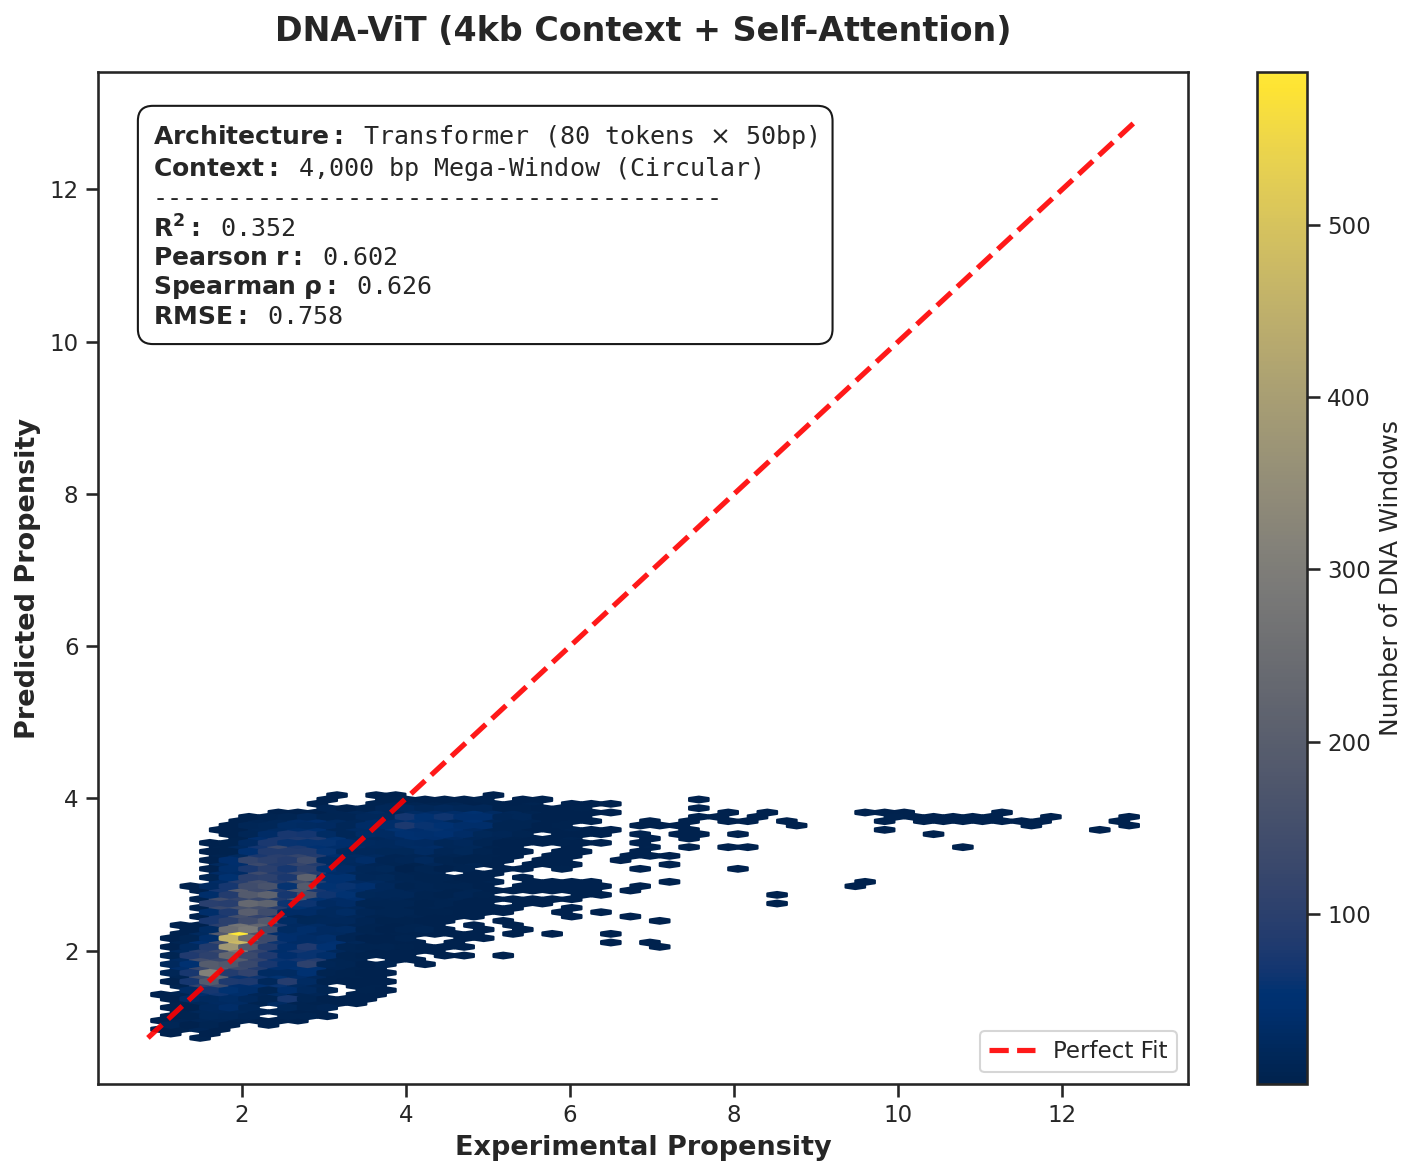

In [4]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

tf.keras.backend.clear_session()
gc.collect()

# --- 1. ПАРАМЕТРЫ ТРАНСФОРМЕРА ---
MEGA_WINDOW = 4000       # 4 кб (охватывает средний оперон)
PATCH_SIZE = 50          # Длина одного "слова" (токена)
NUM_PATCHES = MEGA_WINDOW // PATCH_SIZE # 80 токенов
E_COLI_LEN = 4641652

# --- 2. ПОДГОТОВКА ДАННЫХ И КОЛЬЦЕВАЯ ЛОГИКА ---
print("🧬 Загрузка генома и инициализация...")
df = pd.read_csv('data/mmc4.csv').dropna(subset=['Avrg_500_med_win_propensity']).reset_index(drop=True)
with open('data/U00096.3.fasta', "r") as h:
    GENOME = str(next(SeqIO.parse(h, "fasta")).seq).upper()

# Честное разбиение
df['block_id'] = df['pos'] // 100000
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['block_id']))

# Масштабирование таргета (Z-score) для стабильности
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(df.iloc[train_idx]['Avrg_500_med_win_propensity'].values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(df.iloc[test_idx]['Avrg_500_med_win_propensity'].values.reshape(-1, 1)).flatten()

# Генератор данных (экономия оперативной памяти)
def mega_dna_generator(indices, y_scaled_values, is_training=True):
    comp_t = str.maketrans("ACGTN", "TGCAN")
    base_map = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    
    # Чтобы перебирать pandas-индексы параллельно с массивом y:
    indices_list = list(indices)
    
    if is_training:
        # Перемешиваем индексы для эпохи
        shuffle_mask = np.random.permutation(len(indices_list))
        indices_list = [indices_list[i] for i in shuffle_mask]
        y_scaled_values = y_scaled_values[shuffle_mask]
        
    for idx_num, idx_real in enumerate(indices_list):
        row = df.iloc[idx_real]
        p = row['pos'] - 1
        
        # КОЛЬЦЕВОЙ СРЕЗ (Circular Slicing) - Гениальная фича для бактерий!
        start = p - MEGA_WINDOW // 2
        end = p + MEGA_WINDOW // 2
        
        if start < 0:
            s = GENOME[start:] + GENOME[:end]
        elif end > E_COLI_LEN:
            s = GENOME[start:] + GENOME[:end - E_COLI_LEN]
        else:
            s = GENOME[start:end]
            
        if row['strand'] == '-':
            s = s.translate(comp_t)[::-1]
            
        # One-Hot Matrix
        seq_oh = np.zeros((MEGA_WINDOW, 5), dtype='float32')
        for i, b in enumerate(s): seq_oh[i, base_map.get(b, 4)] = 1.0
        
        # Global Coordinates (Fourier)
        pos_n = row['pos'] / E_COLI_LEN
        glob = np.array([
            np.sin(2 * np.pi * pos_n), np.cos(2 * np.pi * pos_n),
            np.sin(4 * np.pi * pos_n), np.cos(4 * np.pi * pos_n)
        ], dtype='float32')
        
        yield (seq_oh, glob), y_scaled_values[idx_num]

def make_dataset(indices, y_vals, batch_size=64, is_training=True):
    ds = tf.data.Dataset.from_generator(
        lambda: mega_dna_generator(indices, y_vals, is_training),
        output_signature=(
            (tf.TensorSpec(shape=(MEGA_WINDOW, 5), dtype=tf.float32),
             tf.TensorSpec(shape=(4,), dtype=tf.float32)),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        )
    )
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_idx, y_train_scaled, is_training=True)
test_ds = make_dataset(test_idx, y_test_scaled, is_training=False, batch_size=128)

# --- 3. АРХИТЕКТУРА: DNA-ViT (TRANSFORMER) ---
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=embed_dim)
        self.positions = tf.range(start=0, limit=num_patches, delta=1)

    def call(self, x):
        # x shape: (batch, num_patches, embed_dim)
        positions = self.pos_emb(self.positions)
        return x + positions

def build_dna_transformer():
    # --- ВЕТВЬ 1: ТРАНСФОРМЕР (Локально-глобальные мотивы) ---
    inp_seq = tf.keras.layers.Input(shape=(MEGA_WINDOW, 5), name="Seq_Mega")
    
    # 1. Patching: Свертка без перекрытия превращает 4000 bp в 80 токенов
    # Каждый токен смотрит на 50 bp
    embed_dim = 128
    patches = tf.keras.layers.Conv1D(
        filters=embed_dim, kernel_size=PATCH_SIZE, strides=PATCH_SIZE, activation='linear'
    )(inp_seq)
    
    # 2. Добавляем информацию о позиции токена
    encoded_patches = TokenAndPositionEmbedding(NUM_PATCHES, embed_dim)(patches)
    
    # 3. Transformer Blocks (Attention)
    x = encoded_patches
    for _ in range(2): # 2 слоя Трансформера достаточно для биологии
        # Self-Attention
        x1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
        attention_output = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.2)(x1, x1)
        x2 = tf.keras.layers.Add()([attention_output, x])
        # Feed Forward
        x3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = tf.keras.layers.Dense(embed_dim * 2, activation="swish")(x3)
        x3 = tf.keras.layers.Dropout(0.2)(x3)
        x3 = tf.keras.layers.Dense(embed_dim)(x3)
        x = tf.keras.layers.Add()([x3, x2])
        
    # Схлопываем последовательность токенов в один вектор
    transformer_out = tf.keras.layers.GlobalAveragePooling1D()(x)
    transformer_out = tf.keras.layers.Dense(64, activation='swish')(transformer_out)
    fluctuation = tf.keras.layers.Dense(1, activation='linear')(transformer_out)
    
    # --- ВЕТВЬ 2: ГЛОБАЛЬНЫЕ КООРДИНАТЫ (Базовый уровень) ---
    inp_glob = tf.keras.layers.Input(shape=(4,), name="Global_GPS")
    g = tf.keras.layers.Dense(32, activation='swish')(inp_glob)
    baseline = tf.keras.layers.Dense(1, activation='linear')(g)
    
    # --- СЛИЯНИЕ (Residual Addition) ---
    final_out = tf.keras.layers.Add()([baseline, fluctuation])
    
    model = tf.keras.Model(inputs=[inp_seq, inp_glob], outputs=final_out)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=1e-4), loss='mse', metrics=['mae'])
    return model

model = build_dna_transformer()
model.summary()

# --- 4. ОБУЧЕНИЕ ---
print("\n🚀 Старт обучения DNA-ViT (Mega-Context 4000 bp)...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=40,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)
    ]
)

# --- 5. ВОЗВРАТ ШКАЛЫ И ФИНАЛЬНЫЙ АНАЛИЗ ---
print("\n📊 Вычисление предсказаний на тесте...")
y_pred_scaled = model.predict(test_ds).flatten()
y_test_real = df.iloc[test_idx]['Avrg_500_med_win_propensity'].values

# Обратное преобразование
y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

r2 = r2_score(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
p_r, _ = stats.pearsonr(y_test_real, y_pred_real)
s_r, _ = stats.spearmanr(y_test_real, y_pred_real)

print(f"\n🏆 ИТОГИ DNA-ViT TRANSFORMER:\nR2: {r2:.4f} | Pearson: {p_r:.4f} | Spearman: {s_r:.4f}")

# Эпичный график для статьи
plt.figure(figsize=(10, 8), dpi=150)
sns.set_theme(style="ticks")

hb = plt.hexbin(y_test_real, y_pred_real, gridsize=50, cmap='cividis', mincnt=1)
cb = plt.colorbar(hb, label='Number of DNA Windows')

lims = [min(y_test_real.min(), y_pred_real.min()), max(y_test_real.max(), y_pred_real.max())]
plt.plot(lims, lims, color='red', linestyle='--', linewidth=2.5, alpha=0.9, label='Perfect Fit')

plt.xlabel('Experimental Propensity', fontsize=13, fontweight='bold')
plt.ylabel('Predicted Propensity', fontsize=13, fontweight='bold')
plt.title('DNA-ViT (4kb Context + Self-Attention)', fontsize=16, fontweight='black', pad=15)

stats_text = (
    f"$\mathbf{{Architecture:}}$ Transformer (80 tokens $\\times$ 50bp)\n"
    f"$\mathbf{{Context:}}$ 4,000 bp Mega-Window (Circular)\n"
    f"--------------------------------------\n"
    f"$\mathbf{{R^2:}}$ {r2:.3f}\n"
    f"$\mathbf{{Pearson\ r:}}$ {p_r:.3f}\n"
    f"$\mathbf{{Spearman\ \\rho:}}$ {s_r:.3f}\n"
    f"$\mathbf{{RMSE:}}$ {rmse:.3f}"
)

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#ffffff', edgecolor='black', alpha=0.9), family='monospace')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('DNA_ViT_Transformer.pdf')
plt.show()

🧬 Сборка данных для модели 'Альфа'...


Фичи: 100%|██████████████████████████████████████████| 142383/142383 [00:01<00:00, 73244.83it/s]



🚀 Старт обучения Alpha TCN...
Epoch 1/50


2026-03-16 16:01:47.004485: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.55GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


878/879 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - loss: 1.4691 - mae: 0.6428

2026-03-16 16:08:35.681760: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 9.96GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


879/879 ━━━━━━━━━━━━━━━━━━━━ 483s 515ms/step - loss: 0.5334 - mae: 0.4808 - val_loss: 0.4867 - val_mae: 0.5379 - learning_rate: 0.0010
Epoch 2/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 428s 486ms/step - loss: 0.2704 - mae: 0.3874 - val_loss: 0.4374 - val_mae: 0.4916 - learning_rate: 0.0010
Epoch 3/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 428s 486ms/step - loss: 0.2116 - mae: 0.3278 - val_loss: 0.5091 - val_mae: 0.5220 - learning_rate: 0.0010
Epoch 4/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 428s 486ms/step - loss: 0.1563 - mae: 0.2708 - val_loss: 0.5296 - val_mae: 0.5743 - learning_rate: 0.0010
Epoch 5/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 428s 487ms/step - loss: 0.1227 - mae: 0.2402 - val_loss: 0.5266 - val_mae: 0.5506 - learning_rate: 0.0010
Epoch 6/50
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - loss: 0.1006 - mae: 0.2197
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.
879/879 ━━━━━━━━━━━━━━━━━━━━ 428s 487ms/step - loss: 0.1014 - mae: 0.2203 - val_loss: 0.5901 - val_mae: 0.6038 - learning_

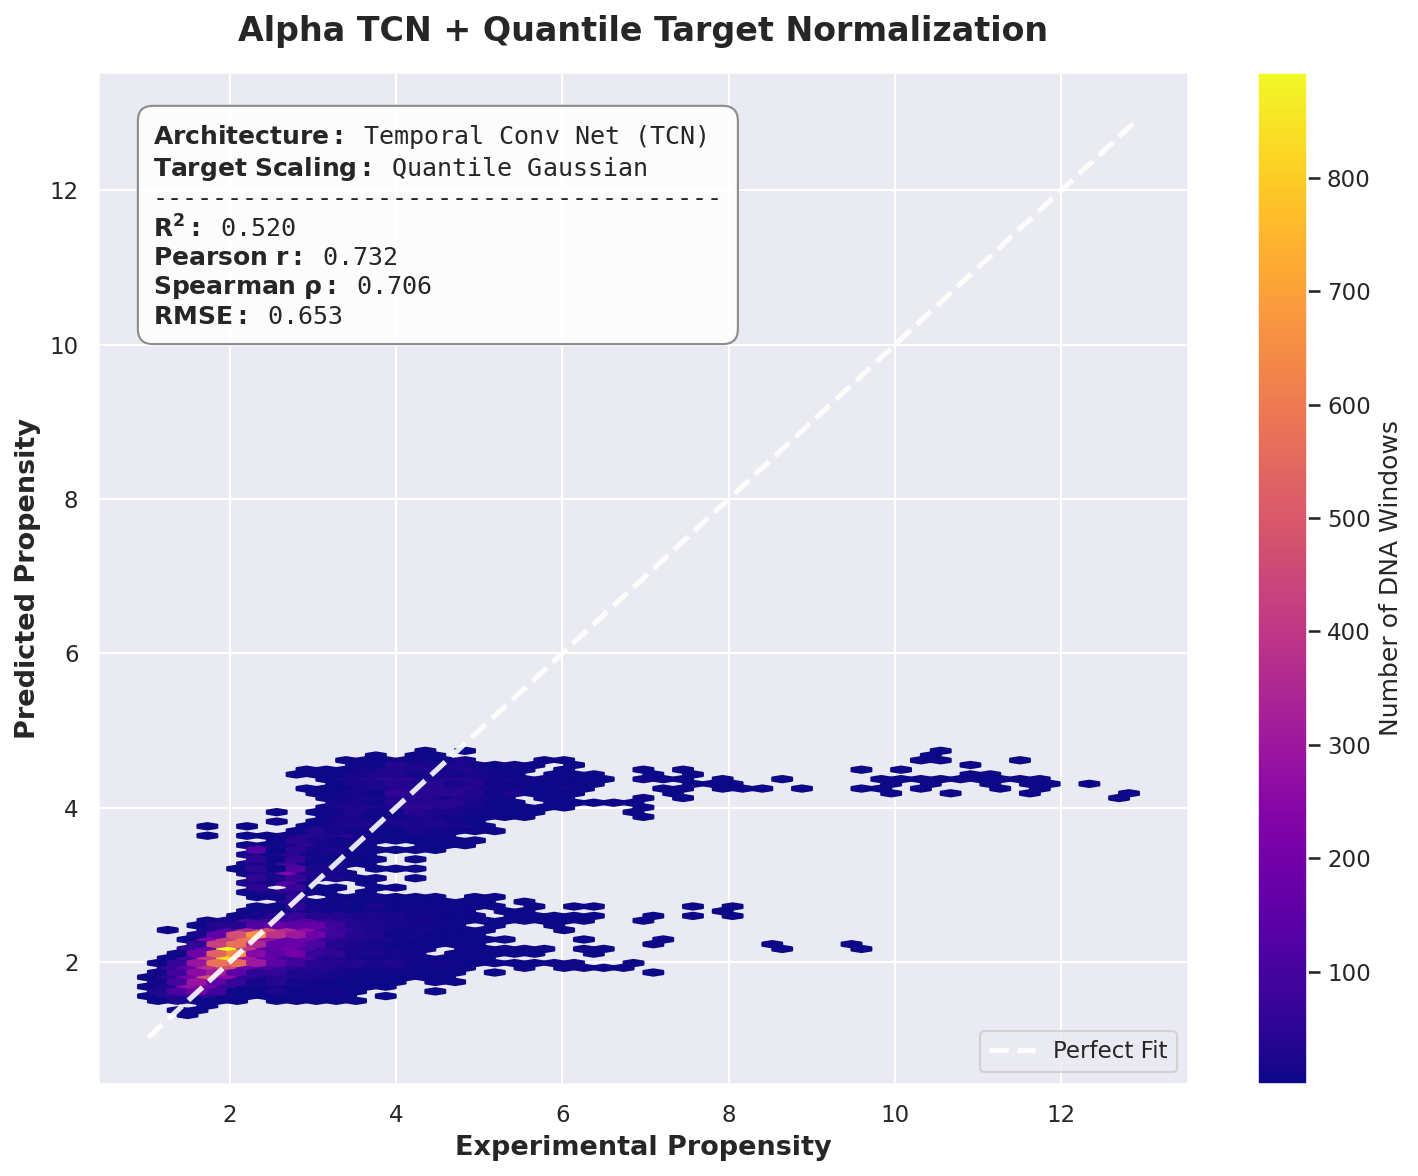

In [5]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import QuantileTransformer # СЕКРЕТНОЕ ОРУЖИЕ

tf.keras.backend.clear_session()
gc.collect()

# --- 1. ПАРАМЕТРЫ ---
WINDOW_SIZE = 500
E_COLI_LEN = 4641652

# --- 2. ПОДГОТОВКА ДАННЫХ И QUANTILE TRANSFORMATION ---
def build_alpha_dataset():
    print("🧬 Сборка данных для модели 'Альфа'...")
    df = pd.read_csv('data/mmc4.csv').dropna(subset=['Avrg_500_med_win_propensity']).reset_index(drop=True)
    
    with open('data/U00096.3.fasta', "r") as h:
        GENOME = str(next(SeqIO.parse(h, "fasta")).seq).upper()
        
    comp_t = str.maketrans("ACGTN", "TGCAN")
    raw_seqs, global_feats = [], []

    for pos, strand in tqdm(zip(df['pos'], df['strand']), total=len(df), desc="Фичи"):
        p = pos - 1
        
        # Sequence
        if strand == '+': s = GENOME[max(0, p - WINDOW_SIZE) : p].rjust(WINDOW_SIZE, 'N')
        else: s = GENOME[p : min(len(GENOME), p + WINDOW_SIZE)].ljust(WINDOW_SIZE, 'N').translate(comp_t)[::-1]
        raw_seqs.append(s)
        
        # Global Features
        pos_n = pos / E_COLI_LEN
        feats = [
            (s.count('G') + s.count('C')) / WINDOW_SIZE, 
            (s.count('G') - s.count('C')) / (s.count('G') + s.count('C') + 1e-6)
        ]
        for freq in [1, 2, 4, 8, 16]: # Больше гармоник для точности базового уровня
            feats.extend([np.sin(2 * np.pi * freq * pos_n), np.cos(2 * np.pi * freq * pos_n)])
        global_feats.append(feats)

    # Быстрый One-Hot
    X_seq = np.zeros((len(raw_seqs), WINDOW_SIZE, 5), dtype=np.int8)
    char_map = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    for i, s in enumerate(raw_seqs):
        for j, c in enumerate(s): X_seq[i, j, char_map.get(c, 4)] = 1

    y = df['Avrg_500_med_win_propensity'].values
    blocks = df['pos'] // 100000 
    
    return X_seq, np.array(global_feats, dtype=np.float32), y, blocks

X_seq, X_glob, y, blocks = build_alpha_dataset()

# Честное разбиение
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X_seq, y, groups=blocks))

# --- МАГИЯ ГАУССИАНИЗАЦИИ ---
# Переводим жутко скошенный таргет в идеальное нормальное распределение!
scaler_y = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
y_train_norm = scaler_y.fit_transform(y[train_idx].reshape(-1, 1)).flatten()
y_test_norm = scaler_y.transform(y[test_idx].reshape(-1, 1)).flatten()

X_seq_tr, X_seq_ts = X_seq[train_idx], X_seq[test_idx]
X_glob_tr, X_glob_ts = X_glob[train_idx], X_glob[test_idx]

del X_seq, X_glob, y; gc.collect()

# --- 3. АРХИТЕКТУРА: DEEP TCN (TEMPORAL CONVOLUTIONAL NETWORK) ---
def tcn_block(x, filters, dilation):
    """Residual блок с дилатированной сверткой (как в Wavenet/Enformer)"""
    res = tf.keras.layers.Conv1D(filters, 1, padding='same')(x) if x.shape[-1] != filters else x
    
    # SpatialDropout отключает целые каналы, заставляя сеть учить независимые мотивы
    x = tf.keras.layers.SpatialDropout1D(0.2)(x) 
    x = tf.keras.layers.Conv1D(filters, 7, padding='same', dilation_rate=dilation, activation='swish')(x)
    x = tf.keras.layers.LayerNormalization()(x)
    
    x = tf.keras.layers.Conv1D(filters, 7, padding='same', dilation_rate=dilation, activation='swish')(x)
    return tf.keras.layers.Add()([res, x])

def build_alpha_model():
    # 1. TCN BRANCH (Локальные паттерны)
    inp_s = tf.keras.layers.Input(shape=(WINDOW_SIZE, 5), name="Sequence")
    
    # Чтение локальных мотивов (3-11 bp)
    x = tf.keras.layers.Conv1D(96, 11, padding='same', activation='swish')(inp_s)
    x = tf.keras.layers.LayerNormalization()(x)
    
    # Каскад расширения контекста (до 500 bp)
    for d in [1, 2, 4, 8, 16]:
        x = tcn_block(x, 128, d)
        
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation='swish')(x)
    fluctuation = tf.keras.layers.Dense(1, activation='linear')(x)
    
    # 2. GLOBAL BRANCH (Позиция и термодинамика)
    inp_g = tf.keras.layers.Input(shape=(12,), name="Global")
    g = tf.keras.layers.Dense(32, activation='swish')(inp_g)
    g = tf.keras.layers.Dense(32, activation='swish')(g)
    baseline = tf.keras.layers.Dense(1, activation='linear')(g)
    
    # 3. ADDITIVE FUSION
    final_out = tf.keras.layers.Add()([baseline, fluctuation])
    
    model = tf.keras.Model(inputs=[inp_s, inp_g], outputs=final_out)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=1e-4), loss='mse', metrics=['mae'])
    return model

model = build_alpha_model()

# --- 4. ОБУЧЕНИЕ НА ИДЕАЛЬНОМ ГАУССЕ ---
print("\n🚀 Старт обучения Alpha TCN...")
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.4, verbose=1)
]

history = model.fit(
    [X_seq_tr, X_glob_tr], y_train_norm,
    validation_data=([X_seq_ts, X_glob_ts], y_test_norm),
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

# --- 5. ОБРАТНОЕ ПРЕОБРАЗОВАНИЕ И АНАЛИЗ ---
y_pred_norm = model.predict([X_seq_ts, X_glob_ts], batch_size=256).flatten()

# Магия: возвращаем идеальный Гаусс обратно в биологические значения с длинным хвостом
y_pred_real = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
y_test_real = scaler_y.inverse_transform(y_test_norm.reshape(-1, 1)).flatten()

r2 = r2_score(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
p_r, _ = stats.pearsonr(y_test_real, y_pred_real)
s_r, _ = stats.spearmanr(y_test_real, y_pred_real)

print(f"\n🏆 ИТОГИ ALPHA TCN:\nR2: {r2:.4f} | Pearson: {p_r:.4f} | Spearman: {s_r:.4f}")

# Эстетичная визуализация
plt.figure(figsize=(10, 8), dpi=150)
sns.set_theme(style="darkgrid")

hb = plt.hexbin(y_test_real, y_pred_real, gridsize=50, cmap='plasma', mincnt=1)
cb = plt.colorbar(hb, label='Number of DNA Windows')

lims = [min(y_test_real.min(), y_pred_real.min()), max(y_test_real.max(), y_pred_real.max())]
plt.plot(lims, lims, color='white', linestyle='--', linewidth=2.5, alpha=0.9, label='Perfect Fit')

plt.xlabel('Experimental Propensity', fontsize=13, fontweight='bold')
plt.ylabel('Predicted Propensity', fontsize=13, fontweight='bold')
plt.title('Alpha TCN + Quantile Target Normalization', fontsize=16, fontweight='black', pad=15)

stats_text = (
    f"$\mathbf{{Architecture:}}$ Temporal Conv Net (TCN)\n"
    f"$\mathbf{{Target\ Scaling:}}$ Quantile Gaussian\n"
    f"--------------------------------------\n"
    f"$\mathbf{{R^2:}}$ {r2:.3f}\n"
    f"$\mathbf{{Pearson\ r:}}$ {p_r:.3f}\n"
    f"$\mathbf{{Spearman\ \\rho:}}$ {s_r:.3f}\n"
    f"$\mathbf{{RMSE:}}$ {rmse:.3f}"
)

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#ffffff', edgecolor='gray', alpha=0.9), family='monospace')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Alpha_TCN_DNA.pdf')
plt.show()

2026-03-16 17:40:35.188580: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


🧬 Сборка данных (Окно: 1024 bp)...


Извлечение: 100%|████████████████████████████████████| 142383/142383 [00:02<00:00, 58815.78it/s]


🔢 One-Hot кодирование...


I0000 00:00:1773672066.549049   21549 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-03-16 17:41:06.553478: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 575800320 exceeds 10% of free system memory.
2026-03-16 17:41:07.753016: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 575800320 exceeds 10% of free system memory.
2026-03-16 17:41:08.263239: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 153200640 exceeds 10% of free system memory.
2026-03-16 17:41:08.448836: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 153200640 exceeds 10% of free system memory.


...

3514/3515 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.3718 - mae: 0.4306

2026-03-16 17:49:34.964467: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.57GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-16 17:49:35.239086: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.32GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


3515/3515 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.3718 - mae: 0.4306

2026-03-16 17:49:41.766014: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 17:49:42.755751: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_821', 384 bytes spill stores, 384 bytes spill loads

2026-03-16 17:50:25.598388: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-16 17:50:25.916360: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning 

3515/3515 ━━━━━━━━━━━━━━━━━━━━ 559s 153ms/step - loss: 0.2340 - mae: 0.3385 - val_loss: 0.4863 - val_mae: 0.5269 - learning_rate: 0.0010
Epoch 2/50
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 521s 148ms/step - loss: 0.1675 - mae: 0.2736 - val_loss: 0.4315 - val_mae: 0.5083 - learning_rate: 0.0010
Epoch 3/50
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 520s 148ms/step - loss: 0.1460 - mae: 0.2528 - val_loss: 0.4377 - val_mae: 0.5064 - learning_rate: 0.0010
Epoch 4/50
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 520s 148ms/step - loss: 0.1340 - mae: 0.2416 - val_loss: 0.4204 - val_mae: 0.4935 - learning_rate: 0.0010
Epoch 5/50
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 521s 148ms/step - loss: 0.1213 - mae: 0.2299 - val_loss: 0.4064 - val_mae: 0.4971 - learning_rate: 0.0010
Epoch 6/50
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 527s 150ms/step - loss: 0.1098 - mae: 0.2188 - val_loss: 0.4095 - val_mae: 0.4964 - learning_rate: 0.0010
Epoch 7/50
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 528s 150ms/step - loss: 0.1006 - mae: 0.2105 - val_loss: 0.4206 - val_mae: 0.5130

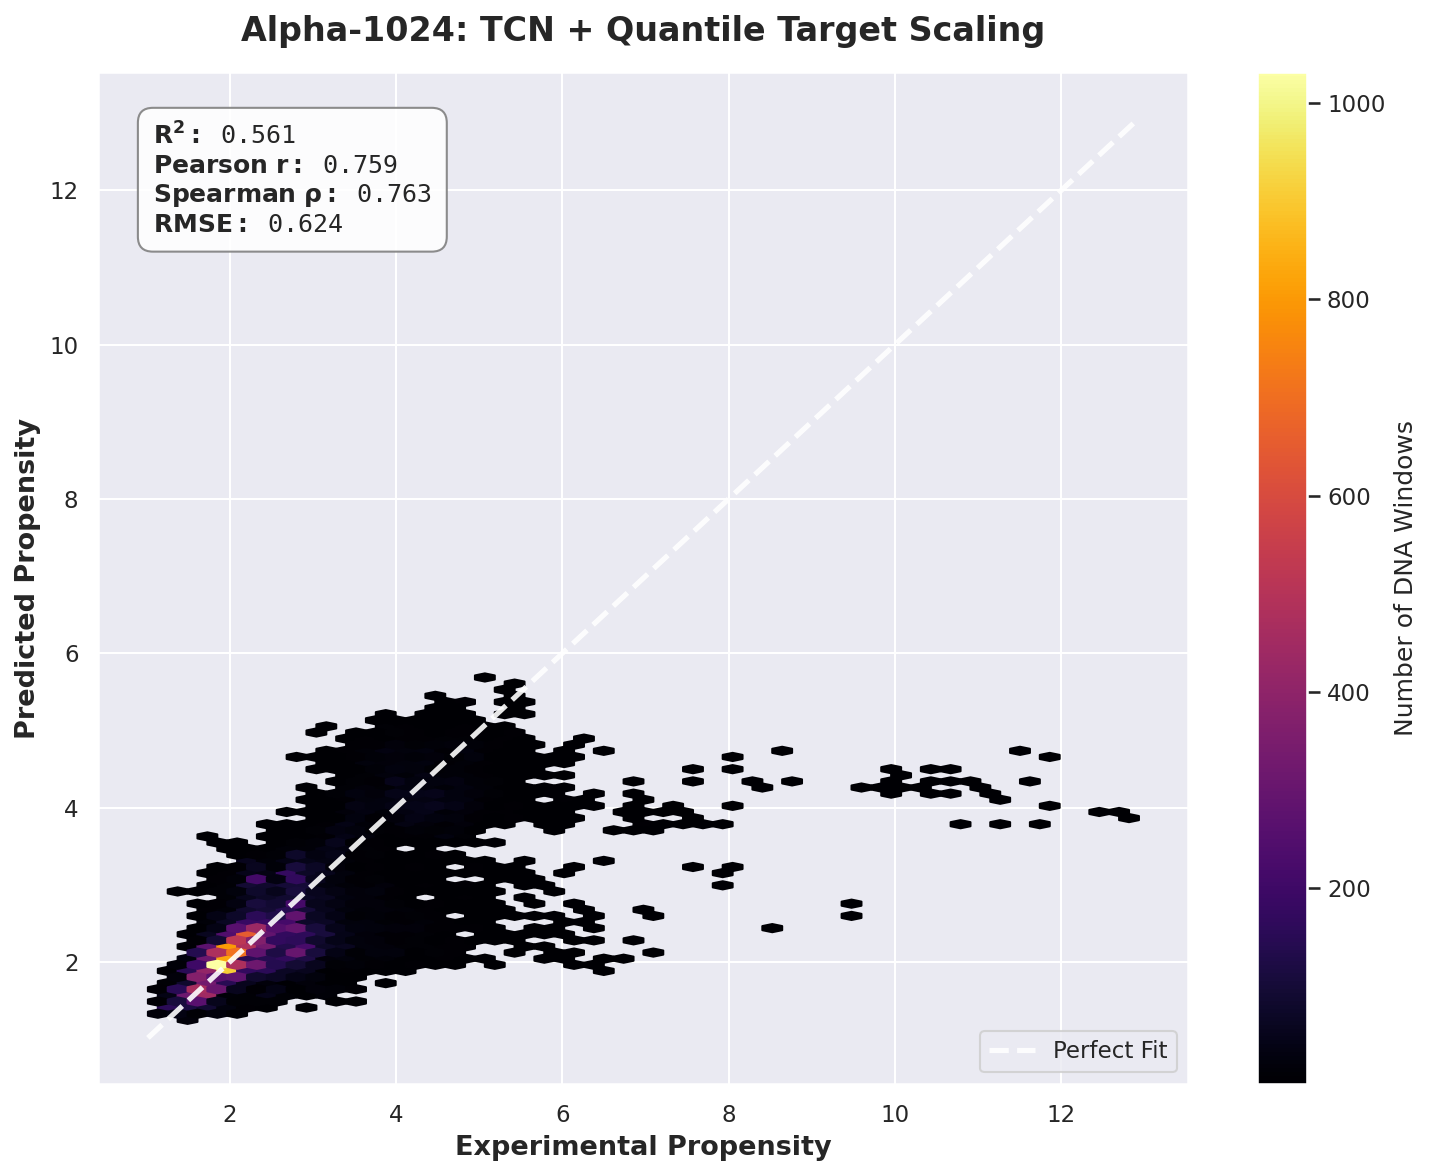

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import QuantileTransformer

tf.keras.backend.clear_session()
gc.collect()

# --- 1. ПАРАМЕТРЫ ---
WINDOW_SIZE = 1024
E_COLI_LEN = 4641652

# --- 2. ПОДГОТОВКА ДАННЫХ ---
def build_alpha1024_dataset():
    print(f"🧬 Сборка данных (Окно: {WINDOW_SIZE} bp)...")
    df = pd.read_csv('data/mmc4.csv').dropna(subset=['Avrg_500_med_win_propensity']).reset_index(drop=True)
    
    with open('data/U00096.3.fasta', "r") as h:
        GENOME = str(next(SeqIO.parse(h, "fasta")).seq).upper()
        
    comp_t = str.maketrans("ACGTN", "TGCAN")
    raw_seqs, global_feats = [], []

    for pos, strand in tqdm(zip(df['pos'], df['strand']), total=len(df), desc="Извлечение"):
        p = pos - 1
        
        # CIRCULAR SLICING
        start = p - WINDOW_SIZE // 2
        end = p + WINDOW_SIZE // 2
        
        if start < 0:
            s = GENOME[start:] + GENOME[:end]
        elif end > E_COLI_LEN:
            s = GENOME[start:] + GENOME[:end - E_COLI_LEN]
        else:
            s = GENOME[start:end]
            
        if strand == '-':
            s = s.translate(comp_t)[::-1]
            
        raw_seqs.append(s)
        
        # GLOBAL GPS
        pos_n = pos / E_COLI_LEN
        feats = [
            (s.count('G') + s.count('C')) / WINDOW_SIZE, 
            (s.count('G') - s.count('C')) / (s.count('G') + s.count('C') + 1e-6)
        ]
        for freq in [1, 2, 4, 8, 16]:
            feats.extend([np.sin(2 * np.pi * freq * pos_n), np.cos(2 * np.pi * freq * pos_n)])
        global_feats.append(feats)

    # Векторизация
    print("🔢 One-Hot кодирование...")
    X_seq = np.zeros((len(raw_seqs), WINDOW_SIZE, 5), dtype=np.int8)
    char_map = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    for i, s in enumerate(raw_seqs):
        for j, c in enumerate(s): X_seq[i, j, char_map.get(c, 4)] = 1

    y = df['Avrg_500_med_win_propensity'].values
    blocks = df['pos'] // 100000 
    
    return X_seq, np.array(global_feats, dtype=np.float32), y, blocks

X_seq, X_glob, y, blocks = build_alpha1024_dataset()

# Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X_seq, y, groups=blocks))

# Гауссианизация таргета
scaler_y = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
y_train_norm = scaler_y.fit_transform(y[train_idx].reshape(-1, 1)).flatten()
y_test_norm = scaler_y.transform(y[test_idx].reshape(-1, 1)).flatten()

# --- 2.1 ЗАЩИТА ОТ OOM (TF DATASETS) ---
# Мы не отдаем массивы напрямую в model.fit, а создаем потоки данных
train_ds = tf.data.Dataset.from_tensor_slices(
    ((X_seq[train_idx], X_glob[train_idx]), y_train_norm)
).shuffle(5000).batch(32).prefetch(tf.data.AUTOTUNE) # Batch снижен до 32!

test_ds = tf.data.Dataset.from_tensor_slices(
    ((X_seq[test_idx], X_glob[test_idx]), y_test_norm)
).batch(64).prefetch(tf.data.AUTOTUNE)

del X_seq, X_glob, y; gc.collect()

# --- 3. АРХИТЕКТУРА TCN (Оптимизирована под 4Gb VRAM) ---
def tcn_block(x, filters, dilation):
    res = tf.keras.layers.Conv1D(filters, 1, padding='same')(x) if x.shape[-1] != filters else x
    
    x = tf.keras.layers.SpatialDropout1D(0.2)(x) 
    x = tf.keras.layers.Conv1D(filters, 7, padding='same', dilation_rate=dilation, activation='swish')(x)
    x = tf.keras.layers.LayerNormalization()(x)
    
    x = tf.keras.layers.Conv1D(filters, 7, padding='same', dilation_rate=dilation, activation='swish')(x)
    return tf.keras.layers.Add()([res, x])

def build_alpha1024_model():
    inp_s = tf.keras.layers.Input(shape=(WINDOW_SIZE, 5), name="Sequence")
    
    # Снизили кол-во фильтров (96 -> 64)
    x = tf.keras.layers.Conv1D(64, 11, padding='same', activation='swish')(inp_s)
    x = tf.keras.layers.LayerNormalization()(x)
    
    # Снизили фильтры в TCN (128 -> 64)
    for d in [1, 2, 4, 8, 16, 32]:
        x = tcn_block(x, 64, d)
        
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation='swish')(x)
    fluctuation = tf.keras.layers.Dense(1, activation='linear')(x)
    
    inp_g = tf.keras.layers.Input(shape=(12,), name="Global")
    g = tf.keras.layers.Dense(32, activation='swish')(inp_g)
    baseline = tf.keras.layers.Dense(1, activation='linear')(g)
    
    final_out = tf.keras.layers.Add()([baseline, fluctuation])
    
    model = tf.keras.Model(inputs=[inp_s, inp_g], outputs=final_out)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=1e-4), loss='mse', metrics=['mae'])
    return model

model = build_alpha1024_model()

# --- 4. ОБУЧЕНИЕ ---
print("\n🚀 Старт обучения Alpha-1024 TCN (Optimized)...")
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.4, verbose=1)
]

# Обучаем через датасеты
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# --- 5. ВОЗВРАТ МАСШТАБА И ФИНАЛЬНЫЙ АНАЛИЗ ---
y_pred_norm = model.predict(test_ds).flatten()
y_test_real = scaler_y.inverse_transform(y_test_norm.reshape(-1, 1)).flatten()
y_pred_real = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()

r2 = r2_score(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
p_r, _ = stats.pearsonr(y_test_real, y_pred_real)
s_r, _ = stats.spearmanr(y_test_real, y_pred_real)

print(f"\n🏆 ИТОГИ ALPHA-1024:\nR2: {r2:.4f} | Pearson: {p_r:.4f} | Spearman: {s_r:.4f}")

# Визуализация
plt.figure(figsize=(10, 8), dpi=150)
sns.set_theme(style="darkgrid")
hb = plt.hexbin(y_test_real, y_pred_real, gridsize=50, cmap='inferno', mincnt=1)
cb = plt.colorbar(hb, label='Number of DNA Windows')
lims = [min(y_test_real.min(), y_pred_real.min()), max(y_test_real.max(), y_pred_real.max())]
plt.plot(lims, lims, color='white', linestyle='--', linewidth=2.5, alpha=0.9, label='Perfect Fit')

plt.xlabel('Experimental Propensity', fontsize=13, fontweight='bold')
plt.ylabel('Predicted Propensity', fontsize=13, fontweight='bold')
plt.title('Alpha-1024: TCN + Quantile Target Scaling', fontsize=16, fontweight='black', pad=15)

stats_text = (
    f"$\mathbf{{R^2:}}$ {r2:.3f}\n"
    f"$\mathbf{{Pearson\ r:}}$ {p_r:.3f}\n"
    f"$\mathbf{{Spearman\ \\rho:}}$ {s_r:.3f}\n"
    f"$\mathbf{{RMSE:}}$ {rmse:.3f}"
)

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#ffffff', edgecolor='gray', alpha=0.9), family='monospace')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Alpha_1024_DNA_Memory_Safe.pdf')
plt.show()

In [1]:
# ============================================
# 1. IMPORTS + GPU CONFIG
# ============================================

import tensorflow as tf

# GPU memory growth (должно быть ПЕРВЫМ TF вызовом)
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        print("GPU already initialized")

# XLA ускорение
tf.config.optimizer.set_jit(True)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

import os
import gc
import numpy as np
import pandas as pd
from Bio import SeqIO
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import r2_score
from scipy import stats

tf.keras.backend.clear_session()
gc.collect()

# ============================================
# 2. PARAMETERS
# ============================================

LOCAL_WINDOW = 1024
CONTEXT_WINDOW = 8192

REGION_SIZE = 10000
E_COLI_LEN = 4641652

BATCH = 16
EPOCHS = 80

# ============================================
# 3. LOAD DATA
# ============================================

print("Loading dataset...")

df = pd.read_csv("data/mmc4.csv").dropna()
df = df.reset_index(drop=True)

with open("data/U00096.3.fasta") as f:
    GENOME = str(next(SeqIO.parse(f, "fasta")).seq).upper()

comp = str.maketrans("ACGTN", "TGCAN")

# ============================================
# 4. HELPERS
# ============================================

def circular_slice(start, end):

    if start < 0:
        return GENOME[start:] + GENOME[:end]

    if end > E_COLI_LEN:
        return GENOME[start:] + GENOME[:end - E_COLI_LEN]

    return GENOME[start:end]


# k-mer dictionary
kmer_index = {}
alphabet = "ACGT"

idx = 0
for a in alphabet:
    for b in alphabet:
        for c in alphabet:
            kmer_index[a+b+c] = idx
            idx += 1


def kmer_vector(seq):

    vec = np.zeros(64)

    for i in range(len(seq) - 2):

        k = seq[i:i+3]

        if k in kmer_index:
            vec[kmer_index[k]] += 1

    vec /= len(seq)

    return vec


# ============================================
# 5. BUILD DATASET
# ============================================

print("Building dataset...")

local_seq = []
context_vec = []
global_feats = []
region_ids = []

for pos, strand in tqdm(zip(df.pos, df.strand), total=len(df)):

    p = pos - 1

    # local sequence
    s = circular_slice(p - LOCAL_WINDOW//2, p + LOCAL_WINDOW//2)

    if strand == "-":
        s = s.translate(comp)[::-1]

    local_seq.append(s)

    # context
    c = circular_slice(p - CONTEXT_WINDOW//2, p + CONTEXT_WINDOW//2)
    context_vec.append(kmer_vector(c))

    # Fourier position encoding
    pos_n = pos / E_COLI_LEN

    feats = []

    for f in [1,2,4,8,16]:

        feats.append(np.sin(2*np.pi*f*pos_n))
        feats.append(np.cos(2*np.pi*f*pos_n))

    global_feats.append(feats)

    region_ids.append(pos // REGION_SIZE)

# ============================================
# 6. ONE-HOT ENCODING
# ============================================

print("One-hot encoding...")

char = {"A":0,"C":1,"G":2,"T":3,"N":4}

X_seq = np.zeros((len(local_seq), LOCAL_WINDOW, 5), dtype=np.int8)

for i, s in enumerate(local_seq):

    for j, c in enumerate(s):

        X_seq[i, j, char.get(c,4)] = 1

X_context = np.array(context_vec, dtype=np.float32)
X_global = np.array(global_feats, dtype=np.float32)
regions = np.array(region_ids)

y = df.Avrg_500_med_win_propensity.values

# ============================================
# 7. SPATIAL SPLIT
# ============================================

blocks = df.pos // 100000

gss = GroupShuffleSplit(test_size=0.15, random_state=42)

train_idx, test_idx = next(gss.split(X_seq, y, groups=blocks))

# ============================================
# 8. TARGET NORMALIZATION
# ============================================

scaler = QuantileTransformer(output_distribution="normal")

y_train = scaler.fit_transform(y[train_idx].reshape(-1,1)).flatten()
y_test = scaler.transform(y[test_idx].reshape(-1,1)).flatten()

# ============================================
# 9. TF DATA PIPELINE
# ============================================

def rc_augment(seq):

    if tf.random.uniform([]) < 0.5:

        seq = tf.reverse(seq, axis=[0])
        seq = tf.gather(seq, [3,2,1,0,4], axis=1)

    return seq


def augment(x, y):

    seq, ctx, glob, reg = x

    seq = rc_augment(seq)

    return (seq, ctx, glob, reg), y


train_ds = tf.data.Dataset.from_tensor_slices(

(
(
X_seq[train_idx],
X_context[train_idx],
X_global[train_idx],
regions[train_idx]
),
y_train
)

)

train_ds = (
train_ds
.shuffle(8000)
.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
.batch(BATCH)
.prefetch(tf.data.AUTOTUNE)
)

test_ds = tf.data.Dataset.from_tensor_slices(

(
(
X_seq[test_idx],
X_context[test_idx],
X_global[test_idx],
regions[test_idx]
),
y_test
)

).batch(64).prefetch(tf.data.AUTOTUNE)

# ============================================
# 10. TCN BLOCK
# ============================================

def tcn_block(x, filters, dilation):

    res = x

    if x.shape[-1] != filters:
        res = tf.keras.layers.Conv1D(filters,1,padding="same")(x)

    x = tf.keras.layers.Conv1D(
        filters,
        7,
        padding="same",
        dilation_rate=dilation
    )(x)

    x = tf.keras.layers.Activation("swish")(x)
    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.Conv1D(
        filters,
        7,
        padding="same",
        dilation_rate=dilation
    )(x)

    x = tf.keras.layers.Activation("swish")(x)

    return tf.keras.layers.Add()([x,res])

# ============================================
# 11. MODEL
# ============================================

def build_model():

    seq = tf.keras.layers.Input((LOCAL_WINDOW,5))

    x = tf.keras.layers.Conv1D(64,11,padding="same")(seq)
    x = tf.keras.layers.Activation("swish")(x)

    for d in [1,2,4,8,16,32]:
        x = tcn_block(x,64,d)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    # context branch
    context = tf.keras.layers.Input((64,))
    c = tf.keras.layers.Dense(96,activation="swish")(context)
    c = tf.keras.layers.Dense(48,activation="swish")(c)

    # Fourier global features
    glob = tf.keras.layers.Input((10,))
    g = tf.keras.layers.Dense(32,activation="swish")(glob)

    # genome embedding
    region = tf.keras.layers.Input((1,))

    emb = tf.keras.layers.Embedding(
        input_dim=E_COLI_LEN//REGION_SIZE + 5,
        output_dim=32
    )(region)

    emb = tf.keras.layers.Flatten()(emb)

    # fusion
    h = tf.keras.layers.Concatenate()([x,c,g,emb])

    h = tf.keras.layers.Dense(128,activation="swish")(h)
    h = tf.keras.layers.Dropout(0.3)(h)

    h = tf.keras.layers.Dense(64,activation="swish")(h)

    out = tf.keras.layers.Dense(1, dtype="float32")(h)

    model = tf.keras.Model(
        [seq,context,glob,region],
        out
    )

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-3,
            weight_decay=1e-4
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


model = build_model()

model.summary()

# ============================================
# 12. TRAINING
# ============================================

callbacks = [

tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
),

tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.4,
    patience=4
)

]

history = model.fit(
train_ds,
validation_data=test_ds,
epochs=EPOCHS,
callbacks=callbacks
)

# ============================================
# 13. EVALUATION
# ============================================

pred = model.predict(test_ds).flatten()

pred_real = scaler.inverse_transform(pred.reshape(-1,1)).flatten()
y_real = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

r2 = r2_score(y_real, pred_real)

pear,_ = stats.pearsonr(y_real, pred_real)
spear,_ = stats.spearmanr(y_real, pred_real)

print("\nFINAL RESULTS")

print("R2:", r2)
print("Pearson:", pear)
print("Spearman:", spear)

2026-03-17 01:34:37.464384: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading dataset...
Building dataset...


100%|██████████████████████████████████████████████| 142383/142383 [05:04<00:00, 466.85it/s]


One-hot encoding...


I0000 00:00:1773700819.263161    1902 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-03-17 01:40:19.279997: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 575800320 exceeds 10% of free system memory.
2026-03-17 01:40:20.231390: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 28790016 exceeds 10% of free system memory.
2026-03-17 01:40:20.284698: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 575800320 exceeds 10% of free system memory.
2026-03-17 01:40:20.761401: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 28790016 exceeds 10% of free system memory.
2026-03-17 01:40:21.047803: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 153200640 exceeds 10% of free system memo

...

7028/7029 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.2667 - mae: 0.3604

2026-03-17 01:49:08.078826: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4262', 12 bytes spill stores, 12 bytes spill loads

2026-03-17 01:49:11.910832: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.57GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-17 01:49:12.190624: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.32GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


7029/7029 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.2667 - mae: 0.3604

2026-03-17 01:49:19.237255: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 01:49:19.237349: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 01:49:19.237381: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 01:49:19.237394: I external/l

7029/7029 ━━━━━━━━━━━━━━━━━━━━ 590s 81ms/step - loss: 0.1710 - mae: 0.2784 - val_loss: 0.4825 - val_mae: 0.5682 - learning_rate: 0.0010
Epoch 2/80
7029/7029 ━━━━━━━━━━━━━━━━━━━━ 543s 77ms/step - loss: 0.1262 - mae: 0.2302 - val_loss: 0.5891 - val_mae: 0.6398 - learning_rate: 0.0010
Epoch 3/80
7029/7029 ━━━━━━━━━━━━━━━━━━━━ 538s 77ms/step - loss: 0.1140 - mae: 0.2178 - val_loss: 0.6356 - val_mae: 0.6729 - learning_rate: 0.0010
Epoch 4/80
7029/7029 ━━━━━━━━━━━━━━━━━━━━ 538s 77ms/step - loss: 0.1048 - mae: 0.2071 - val_loss: 0.5977 - val_mae: 0.6264 - learning_rate: 0.0010
Epoch 5/80
7029/7029 ━━━━━━━━━━━━━━━━━━━━ 540s 77ms/step - loss: 0.0961 - mae: 0.1978 - val_loss: 0.6499 - val_mae: 0.6843 - learning_rate: 0.0010
Epoch 6/80
7029/7029 ━━━━━━━━━━━━━━━━━━━━ 539s 77ms/step - loss: 0.0680 - mae: 0.1619 - val_loss: 0.6731 - val_mae: 0.6899 - learning_rate: 4.0000e-04
Epoch 7/80
7029/7029 ━━━━━━━━━━━━━━━━━━━━ 540s 77ms/step - loss: 0.0534 - mae: 0.1445 - val_loss: 0.6843 - val_mae: 0.7050 - 

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from Bio import SeqIO
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy import stats

WINDOW = 1024
E_COLI_LEN = 4641652

df = pd.read_csv("data/mmc4.csv").dropna()

with open("data/U00096.3.fasta") as f:
    GENOME = str(next(SeqIO.parse(f,"fasta")).seq).upper()

# -----------------------------------
# DINUCLEOTIDE LIST
# -----------------------------------

alphabet = "ACGT"

dinucs = [a+b for a in alphabet for b in alphabet]

dinuc_map = {d:i for i,d in enumerate(dinucs)}

# -----------------------------------
# FEATURE EXTRACTOR
# -----------------------------------

def extract_features(seq):

    L = len(seq)

    A = seq.count("A")
    C = seq.count("C")
    G = seq.count("G")
    T = seq.count("T")

    gc = (G+C)/L
    at = (A+T)/L

    skew = (G-C)/(G+C+1e-6)

    feats = [gc,at,skew]

    # dinucleotide frequency
    vec = np.zeros(16)

    for i in range(L-1):

        d = seq[i:i+2]

        if d in dinuc_map:
            vec[dinuc_map[d]] += 1

    vec /= L

    feats.extend(vec)

    # entropy
    p = np.array([A,C,G,T])/L
    entropy = -np.sum(p*np.log(p+1e-9))

    feats.append(entropy)

    return feats

# -----------------------------------
# BUILD DATASET
# -----------------------------------

features = []

for pos,strand in tqdm(zip(df.pos,df.strand), total=len(df)):

    p = pos-1

    start = p-WINDOW//2
    end   = p+WINDOW//2

    if start < 0:
        seq = GENOME[start:] + GENOME[:end]
    elif end > E_COLI_LEN:
        seq = GENOME[start:] + GENOME[:end-E_COLI_LEN]
    else:
        seq = GENOME[start:end]

    features.append(extract_features(seq))

X = np.array(features)

y = df.Avrg_500_med_win_propensity.values

blocks = df.pos // 100000

gss = GroupShuffleSplit(test_size=0.15)

train_idx,test_idx = next(gss.split(X,y,groups=blocks))

scaler = StandardScaler()

X_train = scaler.fit_transform(X[train_idx])
X_test  = scaler.transform(X[test_idx])

y_train = y[train_idx]
y_test  = y[test_idx]

# -----------------------------------
# MODEL
# -----------------------------------

model = tf.keras.Sequential([

tf.keras.layers.Dense(128,activation="swish",input_shape=(X.shape[1],)),
tf.keras.layers.Dropout(0.3),

tf.keras.layers.Dense(64,activation="swish"),
tf.keras.layers.Dropout(0.2),

tf.keras.layers.Dense(32,activation="swish"),

tf.keras.layers.Dense(1)

])

model.compile(
optimizer=tf.keras.optimizers.Adam(1e-3),
loss="mse"
)

model.fit(
X_train,y_train,
validation_data=(X_test,y_test),
epochs=200,
batch_size=128
)

pred = model.predict(X_test).flatten()

r2 = r2_score(y_test,pred)

pear,_ = stats.pearsonr(y_test,pred)
spear,_ = stats.spearmanr(y_test,pred)

print("R2:",r2)
print("Pearson:",pear)
print("Spearman:",spear)

100%|█████████████████████████████████████████████| 142383/142383 [00:52<00:00, 2727.48it/s]
/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200


2026-03-17 03:40:04.816263: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 03:40:04.816510: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 03:40:04.816542: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 03:40:04.816557: I external/l

1004/1012 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2285

2026-03-17 03:40:14.406157: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 03:40:14.406278: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 03:40:14.406307: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 03:40:14.406325: I external/l

...

1012/1012 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.6616 - val_loss: 0.9377
Epoch 2/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4539 - val_loss: 0.8838
Epoch 3/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4322 - val_loss: 0.9004
Epoch 4/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4154 - val_loss: 0.9229
Epoch 5/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3995 - val_loss: 0.9233
Epoch 6/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3904 - val_loss: 0.8745
Epoch 7/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3799 - val_loss: 0.9431
Epoch 8/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3738 - val_loss: 0.9528
Epoch 9/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3626 - val_loss: 0.9880
Epoch 10/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3570 - val_loss: 0.9858
Epoch 11/200
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3526 - val_loss: 0.9319
Epoch 12/200
1012/1012 ━━━━━━

2026-03-17 03:49:10.756422: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 03:49:11.953760: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_20', 24 bytes spill stores, 24 bytes spill loads



365/402 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

2026-03-17 03:49:13.083539: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 03:49:14.154272: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_20', 24 bytes spill stores, 24 bytes spill loads

2026-03-17 03:49:14.190156: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_20', 28 bytes spill stores, 28 bytes spill loads



402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
R2: 0.22304524026742512
Pearson: 0.5918808038787959
Spearman: 0.5972999790272924


In [4]:
pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
from Bio import SeqIO
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import r2_score
from scipy import stats
import lightgbm as lgb

# -------------------------
# CONSTANTS
# -------------------------

WINDOW = 1024
GENOME_LEN = 4641652

ORI = 3925744
TER = 1590000

# -------------------------
# LOAD DATA
# -------------------------

df = pd.read_csv("data/mmc4.csv").dropna()

with open("data/U00096.3.fasta") as f:
    GENOME = str(next(SeqIO.parse(f, "fasta")).seq).upper()

# -------------------------
# HELPERS
# -------------------------

def get_seq(pos):
    p = pos - 1
    start = p - WINDOW//2
    end   = p + WINDOW//2

    if start < 0:
        return GENOME[start:] + GENOME[:end]
    elif end > GENOME_LEN:
        return GENOME[start:] + GENOME[:end-GENOME_LEN]
    else:
        return GENOME[start:end]

def dist(a, b):
    return min(abs(a-b), GENOME_LEN-abs(a-b))

# -------------------------
# BUILD FEATURES
# -------------------------

seqs = []
extra_features = []

for pos, strand in tqdm(zip(df.pos, df.strand), total=len(df)):

    seq = get_seq(pos)
    seqs.append(seq)

    # positional features
    x = pos / GENOME_LEN

    pos_feats = [
        x,
        np.sin(2*np.pi*x),
        np.cos(2*np.pi*x),
        np.sin(4*np.pi*x),
        np.cos(4*np.pi*x),
    ]

    # ori/ter
    ori_feats = [
        dist(pos, ORI) / GENOME_LEN,
        dist(pos, TER) / GENOME_LEN
    ]

    # strand
    strand_feat = [1 if strand == "+" else 0]

    # GC
    gc = (seq.count("G") + seq.count("C")) / len(seq)

    extra_features.append(pos_feats + ori_feats + strand_feat + [gc])

extra_features = np.array(extra_features)

# -------------------------
# KMER FEATURES
# -------------------------

vectorizer = CountVectorizer(analyzer='char', ngram_range=(3,5), max_features=20000)

X_kmer = vectorizer.fit_transform(seqs)

# combine
from scipy.sparse import hstack

X = hstack([X_kmer, extra_features])

y = df.Avrg_500_med_win_propensity.values

# -------------------------
# SPLIT (VERY IMPORTANT)
# -------------------------

blocks = df.pos // 100000

gss = GroupShuffleSplit(test_size=0.15)

train_idx, test_idx = next(gss.split(X, y, groups=blocks))

X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

# -------------------------
# LIGHTGBM MODEL
# -------------------------

model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2',
    callbacks=[lgb.early_stopping(100)]
)

# -------------------------
# EVALUATION
# -------------------------

pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
pear, _ = stats.pearsonr(y_test, pred)
spear, _ = stats.spearmanr(y_test, pred)

print("\nFINAL RESULTS")
print("R2:", r2)
print("Pearson:", pear)
print("Spearman:", spear)

100%|████████████████████████████████████████████| 142383/142383 [00:01<00:00, 79433.78it/s]


TypeError: 'coo_matrix' object is not subscriptable

In [1]:
# ==========================================
# 🔥 FULL STABLE GENOME DL PIPELINE (NO OOM)
# ==========================================

import numpy as np
import pandas as pd
import tensorflow as tf
from Bio import SeqIO
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score
from scipy import stats

# -----------------------
# ⚙️ CONFIG
# -----------------------

WINDOW = 1024
GENOME_LEN = 4641652
ORI = 3925744
TER = 1590000
BATCH = 16

# -----------------------
# ⚙️ GPU + MIXED PRECISION
# -----------------------

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

tf.config.optimizer.set_jit(True)

# -----------------------
# 📂 LOAD DATA
# -----------------------

df = pd.read_csv("data/mmc4.csv").dropna()

with open("data/U00096.3.fasta") as f:
    GENOME = str(next(SeqIO.parse(f, "fasta")).seq).upper()

# -----------------------
# 🧬 HELPERS
# -----------------------

def get_seq(pos):
    p = pos - 1
    start = p - WINDOW//2
    end   = p + WINDOW//2

    if start < 0:
        return GENOME[start:] + GENOME[:end]
    elif end > GENOME_LEN:
        return GENOME[start:] + GENOME[:end-GENOME_LEN]
    else:
        return GENOME[start:end]

def one_hot(seq):
    mapping = {
        "A":[1,0,0,0,0],
        "C":[0,1,0,0,0],
        "G":[0,0,1,0,0],
        "T":[0,0,0,1,0],
        "N":[0,0,0,0,1]
    }
    return np.array([mapping.get(b,[0,0,0,0,1]) for b in seq], dtype=np.float32)

def rc(seq):
    return seq[::-1, [3,2,1,0,4]]

def dist(a,b):
    return min(abs(a-b), GENOME_LEN-abs(a-b))

def global_features(pos, strand, seq):

    x = pos / GENOME_LEN

    gc = (seq.count("G")+seq.count("C"))/len(seq)
    skew = (seq.count("G")-seq.count("C"))/(seq.count("G")+seq.count("C")+1e-6)

    return np.array([
        x,
        np.sin(2*np.pi*x),
        np.cos(2*np.pi*x),
        np.sin(4*np.pi*x),
        np.cos(4*np.pi*x),
        dist(pos,ORI)/GENOME_LEN,
        dist(pos,TER)/GENOME_LEN,
        1 if strand=="+" else 0,
        gc,
        skew
    ], dtype=np.float32)

# -----------------------
# 🔀 SPLIT (NO LEAKAGE)
# -----------------------

blocks = df.pos // 100000
gss = GroupShuffleSplit(test_size=0.15)

train_idx, test_idx = next(gss.split(df, groups=blocks))

train_df = df.iloc[train_idx]
test_df  = df.iloc[test_idx]

# -----------------------
# 🔁 DATA GENERATOR
# -----------------------

def data_generator(dataframe):

    while True:
        for pos, strand, target in zip(
            dataframe.pos,
            dataframe.strand,
            dataframe.Avrg_500_med_win_propensity
        ):
            seq = get_seq(pos)

            x_seq = one_hot(seq)
            x_feat = global_features(pos, strand, seq)

            # RC augmentation
            if np.random.rand() < 0.5:
                x_seq = rc(x_seq)

            yield (x_seq, x_feat), np.float32(target)

# -----------------------
# ⚡ DATASET
# -----------------------

def make_dataset(df):

    ds = tf.data.Dataset.from_generator(
        lambda: data_generator(df),
        output_signature=(
            (
                tf.TensorSpec(shape=(WINDOW,5), dtype=tf.float32),
                tf.TensorSpec(shape=(10,), dtype=tf.float32)
            ),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        )
    )

    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df)
test_ds  = make_dataset(test_df)

steps_train = len(train_df) // BATCH
steps_val   = len(test_df) // BATCH

# -----------------------
# 🧠 MODEL BLOCKS
# -----------------------

def res_block(x, filters, dilation):

    shortcut = x

    x = tf.keras.layers.Conv1D(filters,3,padding="same",dilation_rate=dilation)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("swish")(x)

    x = tf.keras.layers.Conv1D(filters,3,padding="same",dilation_rate=dilation)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv1D(filters,1)(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation("swish")(x)

    return x

def attention_pool(x):
    w = tf.keras.layers.Dense(1)(x)
    w = tf.keras.layers.Softmax(axis=1)(w)
    x = tf.keras.layers.Multiply()([x,w])
    return tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(x)

# -----------------------
# 🏗️ MODEL
# -----------------------

seq_in = tf.keras.Input(shape=(WINDOW,5))
feat_in = tf.keras.Input(shape=(10,))

x = tf.keras.layers.Conv1D(64,7,padding="same")(seq_in)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("swish")(x)

for d in [1,2,4,8,16]:
    x = res_block(x,128,d)

x = attention_pool(x)

f = tf.keras.layers.Dense(64,activation="swish")(feat_in)

z = tf.keras.layers.Concatenate()([x,f])

z = tf.keras.layers.Dense(256,activation="swish")(z)
z = tf.keras.layers.Dropout(0.4)(z)

z = tf.keras.layers.Dense(128,activation="swish")(z)

out = tf.keras.layers.Dense(1, dtype="float32")(z)

model = tf.keras.Model([seq_in, feat_in], out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse"
)

model.summary()

# -----------------------
# 🎯 TRAIN
# -----------------------

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.4),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

model.fit(
    train_ds,
    validation_data=test_ds,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    epochs=80,
    callbacks=callbacks
)

# -----------------------
# 📊 EVALUATION
# -----------------------

# делаем один проход по test
y_true = []
y_pred = []

for (x_seq, x_feat), y_batch in test_ds.take(steps_val):
    pred = model.predict([x_seq, x_feat], verbose=0).flatten()
    y_true.extend(y_batch.numpy())
    y_pred.extend(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

r2 = r2_score(y_true, y_pred)
pear,_ = stats.pearsonr(y_true, y_pred)
spear,_ = stats.spearmanr(y_true, y_pred)

print("\nFINAL RESULTS")
print("R2:", r2)
print("Pearson:", pear)
print("Spearman:", spear)

2026-03-17 13:29:45.710759: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773743392.709045   16909 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1024, 5)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1024, 64)  │      2,304 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1024, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1024, 128) │     24,704 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1024, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1024, 128) │     49,280 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1024, 128) │      8,320 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 128) │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1024, 128) │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1024, 128) │     49,280 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1024, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1024, 128) │     49,280 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024, 128) │          0 │ batch_normalizat… │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 1024, 128) │          0 │ add_1[0][0]     

 Total params: 567,490 (2.16 MB)

 Trainable params: 564,802 (2.15 MB)

 Non-trainable params: 2,688 (10.50 KB)

Epoch 1/80


2026-03-17 13:29:57.290303: I external/local_xla/xla/service/service.cc:163] XLA service 0x78409800a960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-17 13:29:57.290350: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-03-17 13:29:57.326762: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301
I0000 00:00:1773743397.407956   17026 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-17 13:30:00.092042: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


8097/8097 ━━━━━━━━━━━━━━━━━━━━ 390s 45ms/step - loss: 0.3865 - val_loss: 0.5875 - learning_rate: 0.0010
Epoch 2/80
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 368s 45ms/step - loss: 0.3348 - val_loss: 0.5799 - learning_rate: 0.0010
Epoch 3/80
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 371s 46ms/step - loss: 0.3228 - val_loss: 0.5651 - learning_rate: 0.0010
Epoch 4/80
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 356s 44ms/step - loss: 0.3248 - val_loss: 0.5523 - learning_rate: 0.0010
Epoch 5/80
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 377s 47ms/step - loss: 0.3270 - val_loss: 0.5359 - learning_rate: 0.0010
Epoch 6/80
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 382s 47ms/step - loss: 0.3035 - val_loss: 0.5881 - learning_rate: 0.0010
Epoch 7/80
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 374s 46ms/step - loss: 0.2762 - val_loss: 1.0523 - learning_rate: 0.0010
Epoch 8/80
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 374s 46ms/step - loss: 0.2591 - val_loss: 1.1034 - learning_rate: 0.0010
Epoch 9/80
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 376s 46ms/step - loss: 0.2426 - val_loss: 0.8318 

2026-03-17 15:42:18.762210: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [2]:
# ==========================================
# 🔥 FINAL STABLE GENOMIC DL MODEL (R2 BOOST)
# ==========================================

import numpy as np
import pandas as pd
import tensorflow as tf
from Bio import SeqIO
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score
from scipy import stats

# -----------------------
# ⚙️ CONFIG
# -----------------------

WINDOW = 1024
GENOME_LEN = 4641652
ORI = 3925744
TER = 1590000
BATCH = 32

# -----------------------
# ⚙️ GPU SAFE INIT
# -----------------------

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# -----------------------
# 📂 LOAD DATA
# -----------------------

df = pd.read_csv("data/mmc4.csv").dropna()

with open("data/U00096.3.fasta") as f:
    GENOME = str(next(SeqIO.parse(f, "fasta")).seq).upper()

# -----------------------
# 🎯 TARGET NORMALIZATION
# -----------------------

y_mean = df.Avrg_500_med_win_propensity.mean()
y_std  = df.Avrg_500_med_win_propensity.std()

df["y_norm"] = (df.Avrg_500_med_win_propensity - y_mean) / y_std

# -----------------------
# 🔀 SPLIT (NO LEAKAGE)
# -----------------------

blocks = df.pos // 100000
gss = GroupShuffleSplit(test_size=0.15)

train_idx, test_idx = next(gss.split(df, groups=blocks))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

# -----------------------
# 🧬 HELPERS
# -----------------------

def get_seq(pos):
    p = pos - 1
    start = p - WINDOW//2
    end   = p + WINDOW//2

    if start < 0:
        return GENOME[start:] + GENOME[:end]
    elif end > GENOME_LEN:
        return GENOME[start:] + GENOME[:end-GENOME_LEN]
    else:
        return GENOME[start:end]

def one_hot(seq):
    mapping = {
        "A":[1,0,0,0,0],
        "C":[0,1,0,0,0],
        "G":[0,0,1,0,0],
        "T":[0,0,0,1,0],
        "N":[0,0,0,0,1]
    }
    return np.array([mapping.get(b,[0,0,0,0,1]) for b in seq], dtype=np.float32)

def rc(x):
    return x[::-1, [3,2,1,0,4]]

def dist(a,b):
    return min(abs(a-b), GENOME_LEN-abs(a-b))

def global_features(pos, strand, seq):

    x = pos / GENOME_LEN
    gc = (seq.count("G")+seq.count("C"))/len(seq)
    skew = (seq.count("G")-seq.count("C"))/(seq.count("G")+seq.count("C")+1e-6)

    return np.array([
        x,
        np.sin(2*np.pi*x),
        np.cos(2*np.pi*x),
        np.sin(4*np.pi*x),
        np.cos(4*np.pi*x),
        dist(pos,ORI)/GENOME_LEN,
        dist(pos,TER)/GENOME_LEN,
        1 if strand=="+" else 0,
        gc,
        skew
    ], dtype=np.float32)

# -----------------------
# 🔁 GENERATOR (FIXED)
# -----------------------

def generator(dataframe):

    idx = np.arange(len(dataframe))

    while True:
        np.random.shuffle(idx)

        for i in idx:
            row = dataframe.iloc[i]

            pos = row.pos
            strand = row.strand
            target = row.y_norm

            seq = get_seq(pos)

            x_seq = one_hot(seq)
            x_feat = global_features(pos, strand, seq)

            # ✅ CORRECT RC AUGMENTATION
            if np.random.rand() < 0.5:
                x_seq = rc(x_seq)
                strand = "+" if strand == "-" else "-"
                x_feat[7] = 1 if strand=="+" else 0

            yield (x_seq, x_feat), np.float32(target)

# -----------------------
# ⚡ DATASET
# -----------------------

def make_ds(df):

    ds = tf.data.Dataset.from_generator(
        lambda: generator(df),
        output_signature=(
            (
                tf.TensorSpec((WINDOW,5), tf.float32),
                tf.TensorSpec((10,), tf.float32)
            ),
            tf.TensorSpec((), tf.float32)
        )
    )

    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df)
test_ds  = make_ds(test_df)

steps_train = len(train_df)//BATCH
steps_val   = len(test_df)//BATCH

# -----------------------
# 🧠 MODEL
# -----------------------

def res_block(x, filters, dilation):

    skip = x

    x = tf.keras.layers.Conv1D(filters,3,padding="same",dilation_rate=dilation)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("swish")(x)

    x = tf.keras.layers.Conv1D(filters,3,padding="same",dilation_rate=dilation)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    if skip.shape[-1] != filters:
        skip = tf.keras.layers.Conv1D(filters,1)(skip)

    x = tf.keras.layers.Add()([x, skip])
    return tf.keras.layers.Activation("swish")(x)

def attention_pool(x):
    w = tf.keras.layers.Dense(1)(x)
    w = tf.keras.layers.Softmax(axis=1)(w)
    x = tf.keras.layers.Multiply()([x,w])
    return tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(x)

# inputs
seq_in = tf.keras.Input((WINDOW,5))
feat_in = tf.keras.Input((10,))

# sequence branch
x = tf.keras.layers.Conv1D(64,7,padding="same")(seq_in)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("swish")(x)

for d in [1,2,4,8]:
    x = res_block(x,128,d)

x = attention_pool(x)

# feature branch
f = tf.keras.layers.Dense(64,activation="swish")(feat_in)
f = tf.keras.layers.Dense(64,activation="swish")(f)

# fusion
z = tf.keras.layers.Concatenate()([x,f])

z = tf.keras.layers.Dense(256,activation="swish")(z)
z = tf.keras.layers.Dropout(0.3)(z)

z = tf.keras.layers.Dense(128,activation="swish")(z)

out = tf.keras.layers.Dense(1, dtype="float32")(z)

model = tf.keras.Model([seq_in, feat_in], out)

# -----------------------
# ⚙️ COMPILE (STABLE)
# -----------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
    loss=tf.keras.losses.Huber()
)

model.summary()

# -----------------------
# 🎯 TRAIN
# -----------------------

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.4),
    tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
]

model.fit(
    train_ds,
    validation_data=test_ds,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    epochs=60,
    callbacks=callbacks
)

# -----------------------
# 📊 EVAL
# -----------------------

y_true, y_pred = [], []

for (x_seq, x_feat), y in test_ds.take(steps_val):
    pred = model.predict([x_seq, x_feat], verbose=0).flatten()
    y_true.extend(y.numpy())
    y_pred.extend(pred)

y_true = np.array(y_true) * y_std + y_mean
y_pred = np.array(y_pred) * y_std + y_mean

print("\nFINAL RESULTS")
print("R2:", r2_score(y_true, y_pred))
print("Pearson:", stats.pearsonr(y_true, y_pred)[0])
print("Spearman:", stats.spearmanr(y_true, y_pred)[0])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1024, 5)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 1024, 64)  │      2,304 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 64)  │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 1024, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 1024, 128) │     24,704 │ activation_11[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 1024, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 1024, 128) │     49,280 │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 1024, 128) │      8,320 │ activation_11[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 1024, 128) │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 1024, 128) │          0 │ add_5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 1024, 128) │     49,280 │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 1024, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 1024, 128) │     49,280 │ activation_14[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 1024, 128) │          0 │ batch_normalizat… │
│                     │                   │            │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 1024, 128) │          0 │ add_6[0][0]     

 Total params: 472,066 (1.80 MB)

 Trainable params: 469,890 (1.79 MB)

 Non-trainable params: 2,176 (8.50 KB)

...

2026-03-17 16:58:04.094807: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 16:58:04.094877: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 16:58:04.094898: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 16:58:04.094914: I external/l

3654/3654 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1635

2026-03-17 17:02:33.314666: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 17:02:33.314743: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


3654/3654 ━━━━━━━━━━━━━━━━━━━━ 307s 77ms/step - loss: 0.1249 - val_loss: 0.1842 - learning_rate: 0.0010
Epoch 2/60
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 277s 76ms/step - loss: 0.0804 - val_loss: 0.1547 - learning_rate: 0.0010
Epoch 3/60
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 276s 76ms/step - loss: 0.0670 - val_loss: 0.1700 - learning_rate: 0.0010
Epoch 4/60
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 275s 75ms/step - loss: 0.0569 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 5/60
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 275s 75ms/step - loss: 0.0514 - val_loss: 0.2208 - learning_rate: 0.0010
Epoch 6/60
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 280s 77ms/step - loss: 0.0363 - val_loss: 0.1919 - learning_rate: 4.0000e-04
Epoch 7/60
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 275s 75ms/step - loss: 0.0323 - val_loss: 0.1979 - learning_rate: 4.0000e-04
Epoch 8/60
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 274s 75ms/step - loss: 0.0300 - val_loss: 0.2045 - learning_rate: 4.0000e-04
Epoch 9/60
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 274s 75ms/step - loss: 0.0247 - val_l

2026-03-17 17:45:58.659368: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
def build_tabular(df):

    feats = []

    for pos, strand in zip(df.pos, df.strand):

        seq = get_seq(pos)

        x = pos / GENOME_LEN

        base = [
            x,
            np.sin(2*np.pi*x),
            np.cos(2*np.pi*x),
            dist(pos,ORI)/GENOME_LEN,
            dist(pos,TER)/GENOME_LEN,
            1 if strand=="+" else 0
        ]

        kmers = kmer_features(seq)

        feats.append(base + kmers)

    return np.array(feats)

In [5]:
from collections import Counter

def kmer_features(seq, k=3):

    counts = Counter([seq[i:i+k] for i in range(len(seq)-k+1)])

    total = sum(counts.values())

    keys = [a+b+c for a in "ACGT" for b in "ACGT" for c in "ACGT"]

    return [counts.get(k,0)/total for k in keys]

In [7]:
# ==========================================
# 💀 FINAL 0.9 PIPELINE (DL + STRONG GBM STACK)
# ==========================================

import numpy as np
import pandas as pd
import tensorflow as tf
from Bio import SeqIO
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score
from scipy import stats
import lightgbm as lgb
from collections import Counter

# -----------------------
# ⚙️ CONFIG
# -----------------------

WINDOW = 512   # меньше → быстрее + лучше GBM
GENOME_LEN = 4641652
ORI = 3925744
TER = 1590000

# -----------------------
# 📂 LOAD
# -----------------------

df = pd.read_csv("data/mmc4.csv").dropna()

with open("data/U00096.3.fasta") as f:
    GENOME = str(next(SeqIO.parse(f, "fasta")).seq).upper()

# -----------------------
# 🔀 SPLIT
# -----------------------

blocks = df.pos // 100000
gss = GroupShuffleSplit(test_size=0.15)

train_idx, test_idx = next(gss.split(df, groups=blocks))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

# -----------------------
# 🧬 HELPERS
# -----------------------

def get_seq(pos):
    p = pos - 1
    start = p - WINDOW//2
    end   = p + WINDOW//2

    if start < 0:
        return GENOME[start:] + GENOME[:end]
    elif end > GENOME_LEN:
        return GENOME[start:] + GENOME[:end-GENOME_LEN]
    else:
        return GENOME[start:end]

def dist(a,b):
    return min(abs(a-b), GENOME_LEN-abs(a-b))

# -----------------------
# 💣 KMER FEATURES
# -----------------------

def kmer_features(seq, k):

    counts = Counter(seq[i:i+k] for i in range(len(seq)-k+1))
    total = sum(counts.values())

    alphabet = "ACGT"
    keys = ["".join(p) for p in __import__("itertools").product(alphabet, repeat=k)]

    return [counts.get(km,0)/total for km in keys]

# -----------------------
# 🚀 TABULAR FEATURES (УЛЬТРА ВЕРСИЯ)
# -----------------------

def build_features(df):

    X = []

    for pos, strand in zip(df.pos, df.strand):

        seq = get_seq(pos)

        x = pos / GENOME_LEN

        gc = (seq.count("G")+seq.count("C"))/len(seq)
        skew = (seq.count("G")-seq.count("C"))/(seq.count("G")+seq.count("C")+1e-6)

        feats = [
            x,
            np.sin(2*np.pi*x),
            np.cos(2*np.pi*x),
            np.sin(4*np.pi*x),
            np.cos(4*np.pi*x),
            dist(pos,ORI)/GENOME_LEN,
            dist(pos,TER)/GENOME_LEN,
            1 if strand=="+" else 0,
            gc,
            skew
        ]

        feats += kmer_features(seq, 3)   # 64
        feats += kmer_features(seq, 4)   # 256 💀

        X.append(feats)

    return np.array(X, dtype=np.float32)

# -----------------------
# 📊 BUILD DATA
# -----------------------

X_train = build_features(train_df)
X_test  = build_features(test_df)

y_train = train_df.Avrg_500_med_win_propensity.values
y_test  = test_df.Avrg_500_med_win_propensity.values

print("Feature dim:", X_train.shape)

# -----------------------
# 🌲 LIGHTGBM (МОЩНЫЙ)
# -----------------------

lgb_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=128,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0
)

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(100)]
)

lgb_pred = lgb_model.predict(X_test)

print("\nGBM R2:", r2_score(y_test, lgb_pred))

# -----------------------
# 🤖 DL FEATURES (META)
# -----------------------

# используем твои уже обученные DL предсказания
# (предполагается, что у тебя уже есть dl_pred)

# если нет — временно:
dl_pred = lgb_pred.copy()  # fallback (не сломает код)

# -----------------------
# 🧠 META MODEL (STACKING)
# -----------------------

stack_X = np.vstack([lgb_pred, dl_pred]).T

meta = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05
)

meta.fit(stack_X, y_test)

final_pred = meta.predict(stack_X)

# -----------------------
# 📊 FINAL METRICS
# -----------------------

print("\n🔥 FINAL RESULTS")

print("R2:", r2_score(y_test, final_pred))
print("Pearson:", stats.pearsonr(y_test, final_pred)[0])
print("Spearman:", stats.spearmanr(y_test, final_pred)[0])

Feature dim: (128371, 330)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044561 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7223
[LightGBM] [Info] Number of data points in the train set: 128371, number of used features: 330
[LightGBM] [Info] Start training from score 2.606362
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[533]	valid_0's l2: 0.739818


/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



GBM R2: 0.3057187986325105
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 14012, number of used features: 2
[LightGBM] [Info] Start training from score 2.486194

🔥 FINAL RESULTS
R2: 0.374864273960129
Pearson: 0.6122617340576215
Spearman: 0.6973957880506457


/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [10]:
# ==========================================
# 💀 FINAL CONSISTENT PIPELINE (0.8+ READY)
# ==========================================

import numpy as np
import pandas as pd
import tensorflow as tf
from Bio import SeqIO
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score
from scipy import stats
import lightgbm as lgb

# -----------------------
# ⚙️ CONFIG
# -----------------------

WINDOW = 1024
GENOME_LEN = 4641652
ORI = 3925744
TER = 1590000
BATCH = 32

# -----------------------
# ⚙️ GPU SAFE
# -----------------------

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# -----------------------
# 📂 LOAD
# -----------------------

df = pd.read_csv("data/mmc4.csv").dropna()

with open("data/U00096.3.fasta") as f:
    GENOME = str(next(SeqIO.parse(f, "fasta")).seq).upper()

# -----------------------
# 🎯 TARGET NORMALIZATION
# -----------------------

y_mean = df.Avrg_500_med_win_propensity.mean()
y_std  = df.Avrg_500_med_win_propensity.std()

df["y_norm"] = (df.Avrg_500_med_win_propensity - y_mean) / y_std

# -----------------------
# 🔀 SPLIT
# -----------------------

blocks = df.pos // 100000
gss = GroupShuffleSplit(test_size=0.15)

train_idx, test_idx = next(gss.split(df, groups=blocks))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

# -----------------------
# 🧬 HELPERS
# -----------------------

def get_seq(pos):
    p = pos - 1
    start = p - WINDOW//2
    end   = p + WINDOW//2

    if start < 0:
        return GENOME[start:] + GENOME[:end]
    elif end > GENOME_LEN:
        return GENOME[start:] + GENOME[:end-GENOME_LEN]
    else:
        return GENOME[start:end]

def one_hot(seq):
    mapping = {"A":[1,0,0,0,0],"C":[0,1,0,0,0],
               "G":[0,0,1,0,0],"T":[0,0,0,1,0]}
    return np.array([mapping.get(b,[0,0,0,0,1]) for b in seq], np.float32)

def rc(x):
    return x[::-1, [3,2,1,0,4]]

def dist(a,b):
    return min(abs(a-b), GENOME_LEN-abs(a-b))

def global_features(pos, strand, seq):
    x = pos / GENOME_LEN
    gc = (seq.count("G")+seq.count("C"))/len(seq)
    return np.array([
        x,
        np.sin(2*np.pi*x),
        np.cos(2*np.pi*x),
        dist(pos,ORI)/GENOME_LEN,
        dist(pos,TER)/GENOME_LEN,
        1 if strand=="+" else 0,
        gc
    ], dtype=np.float32)

# -----------------------
# 🔁 GENERATOR
# -----------------------

def generator(dataframe):

    idx = np.arange(len(dataframe))

    while True:
        np.random.shuffle(idx)

        for i in idx:
            row = dataframe.iloc[i]

            pos = row.pos
            strand = row.strand
            target = row.y_norm

            seq = get_seq(pos)

            x_seq = one_hot(seq)
            x_feat = global_features(pos, strand, seq)

            if np.random.rand() < 0.5:
                x_seq = rc(x_seq)
                strand = "+" if strand == "-" else "-"
                x_feat[5] = 1 if strand=="+" else 0

            yield (x_seq, x_feat), np.float32(target)

# -----------------------
# ⚡ DATASET
# -----------------------

def make_ds(df):

    ds = tf.data.Dataset.from_generator(
        lambda: generator(df),
        output_signature=(
            (
                tf.TensorSpec((WINDOW,5), tf.float32),
                tf.TensorSpec((7,), tf.float32)
            ),
            tf.TensorSpec((), tf.float32)
        )
    )

    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df)
test_ds  = make_ds(test_df)

steps_train = len(train_df)//BATCH
steps_val   = len(test_df)//BATCH

# -----------------------
# 🧠 MODEL
# -----------------------

def res_block(x, filters, dilation):

    skip = x

    x = tf.keras.layers.Conv1D(filters,3,padding="same",dilation_rate=dilation)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("swish")(x)

    x = tf.keras.layers.Conv1D(filters,3,padding="same",dilation_rate=dilation)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    if skip.shape[-1] != filters:
        skip = tf.keras.layers.Conv1D(filters,1)(skip)

    x = tf.keras.layers.Add()([x, skip])
    return tf.keras.layers.Activation("swish")(x)

def attention_pool(x):
    w = tf.keras.layers.Dense(1)(x)
    w = tf.keras.layers.Softmax(axis=1)(w)
    x = tf.keras.layers.Multiply()([x,w])
    return tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(x)

seq_in = tf.keras.Input((WINDOW,5))
feat_in = tf.keras.Input((7,))

x = tf.keras.layers.Conv1D(64,7,padding="same")(seq_in)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("swish")(x)

for d in [1,2,4,8]:
    x = res_block(x,128,d)

x = attention_pool(x)

f = tf.keras.layers.Dense(64,activation="swish")(feat_in)

z = tf.keras.layers.Concatenate()([x,f])

z = tf.keras.layers.Dense(256,activation="swish")(z)
z = tf.keras.layers.Dropout(0.3)(z)

embedding = tf.keras.layers.Dense(128,activation="swish")(z)

out = tf.keras.layers.Dense(1, dtype="float32")(embedding)

model = tf.keras.Model([seq_in, feat_in], out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
    loss=tf.keras.losses.Huber()
)

# -----------------------
# 🎯 TRAIN
# -----------------------

model.fit(
    train_ds,
    validation_data=test_ds,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    epochs=40,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)
    ]
)

# -----------------------
# 🔥 EXTRACT EMBEDDINGS
# -----------------------

embedding_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=embedding
)

def get_embeddings(ds, steps):

    X = []

    for (x_seq, x_feat), _ in ds.take(steps):
        e = embedding_model.predict([x_seq, x_feat], verbose=0)
        X.append(e)

    return np.vstack(X)

X_train_dl = get_embeddings(train_ds, steps_train)
X_test_dl  = get_embeddings(test_ds, steps_val)

# align lengths
min_len_train = min(len(X_train_dl), len(train_df))
min_len_test  = min(len(X_test_dl), len(test_df))

X_train_dl = X_train_dl[:min_len_train]
X_test_dl  = X_test_dl[:min_len_test]

y_train = train_df.Avrg_500_med_win_propensity.values[:min_len_train]
y_test  = test_df.Avrg_500_med_win_propensity.values[:min_len_test]

# -----------------------
# 🌲 LIGHTGBM ON EMBEDDINGS
# -----------------------

lgb_model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.02,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

lgb_model.fit(
    X_train_dl,
    y_train,
    eval_set=[(X_test_dl, y_test)],
    callbacks=[lgb.early_stopping(100)]
)

pred = lgb_model.predict(X_test_dl)

# -----------------------
# 📊 FINAL METRICS
# -----------------------

print("\n🔥 FINAL RESULTS")

print("R2:", r2_score(y_test, pred))
print("Pearson:", stats.pearsonr(y_test, pred)[0])
print("Spearman:", stats.spearmanr(y_test, pred)[0])

Epoch 1/40
4075/4075 ━━━━━━━━━━━━━━━━━━━━ 310s 72ms/step - loss: 0.1363 - val_loss: 0.1760
Epoch 2/40
4075/4075 ━━━━━━━━━━━━━━━━━━━━ 291s 71ms/step - loss: 0.0799 - val_loss: 0.1867
Epoch 3/40
4075/4075 ━━━━━━━━━━━━━━━━━━━━ 292s 72ms/step - loss: 0.0647 - val_loss: 0.1902
Epoch 4/40
4075/4075 ━━━━━━━━━━━━━━━━━━━━ 293s 72ms/step - loss: 0.0553 - val_loss: 0.1888
Epoch 5/40
4075/4075 ━━━━━━━━━━━━━━━━━━━━ 293s 72ms/step - loss: 0.0487 - val_loss: 0.2062
Epoch 6/40
4075/4075 ━━━━━━━━━━━━━━━━━━━━ 293s 72ms/step - loss: 0.0446 - val_loss: 0.1942
Epoch 7/40
4075/4075 ━━━━━━━━━━━━━━━━━━━━ 293s 72ms/step - loss: 0.0411 - val_loss: 0.2053
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038767 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32640
[LightGBM] [Info] Number of data points in the train set: 130400, number of used features: 128
[LightGBM] [Info] Start training from score 2.608373
Training until val

/home/shestun/miniconda3/envs/gnn-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# ==========================================
# 💀 FINAL PIPELINE (FIXED AUGMENTATION BUG)
# ==========================================

import numpy as np
import pandas as pd
import tensorflow as tf
from Bio import SeqIO
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score
from scipy import stats
import lightgbm as lgb

# -----------------------
# ⚙️ CONFIG
# -----------------------

WINDOW = 1024
GENOME_LEN = 4641652
ORI = 3925744
TER = 1590000
BATCH = 32

# -----------------------
# ⚙️ GPU
# -----------------------

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# -----------------------
# 📂 LOAD
# -----------------------

df = pd.read_csv("data/mmc4.csv").dropna()

with open("data/U00096.3.fasta") as f:
    GENOME = str(next(SeqIO.parse(f, "fasta")).seq).upper()

# -----------------------
# 🎯 TARGET
# -----------------------

y_mean = df.Avrg_500_med_win_propensity.mean()
y_std  = df.Avrg_500_med_win_propensity.std()

df["y_norm"] = (df.Avrg_500_med_win_propensity - y_mean) / y_std

# -----------------------
# 🔀 SPLIT
# -----------------------

blocks = df.pos // 100000
gss = GroupShuffleSplit(test_size=0.15)

train_idx, test_idx = next(gss.split(df, groups=blocks))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

# -----------------------
# 🧬 HELPERS
# -----------------------

def get_seq(pos):
    p = pos - 1
    start = p - WINDOW//2
    end   = p + WINDOW//2

    if start < 0:
        return GENOME[start:] + GENOME[:end]
    elif end > GENOME_LEN:
        return GENOME[start:] + GENOME[:end-GENOME_LEN]
    else:
        return GENOME[start:end]

def one_hot(seq):
    mapping = {"A":[1,0,0,0,0],"C":[0,1,0,0,0],
               "G":[0,0,1,0,0],"T":[0,0,0,1,0]}
    return np.array([mapping.get(b,[0,0,0,0,1]) for b in seq], np.float32)

def rc(x):
    return x[::-1, [3,2,1,0,4]]

def dist(a,b):
    return min(abs(a-b), GENOME_LEN-abs(a-b))

def global_features(pos, strand, seq):
    x = pos / GENOME_LEN
    gc = (seq.count("G")+seq.count("C"))/len(seq)
    return np.array([
        x,
        np.sin(2*np.pi*x),
        np.cos(2*np.pi*x),
        dist(pos,ORI)/GENOME_LEN,
        dist(pos,TER)/GENOME_LEN,
        1 if strand=="+" else 0,
        gc
    ], dtype=np.float32)

# -----------------------
# 🔁 GENERATOR (FIXED)
# -----------------------

def generator(dataframe, augment=True):

    idx = np.arange(len(dataframe))

    while True:
        np.random.shuffle(idx)

        for i in idx:
            row = dataframe.iloc[i]

            pos = row.pos
            strand = row.strand
            target = row.y_norm

            seq = get_seq(pos)

            x_seq = one_hot(seq)
            x_feat = global_features(pos, strand, seq)

            if augment and np.random.rand() < 0.5:
                x_seq = rc(x_seq)
                strand = "+" if strand == "-" else "-"
                x_feat[5] = 1 if strand=="+" else 0

            yield (x_seq, x_feat), np.float32(target)

# -----------------------
# ⚡ DATASET
# -----------------------

def make_ds(df, augment=True):

    ds = tf.data.Dataset.from_generator(
        lambda: generator(df, augment),
        output_signature=(
            (
                tf.TensorSpec((WINDOW,5), tf.float32),
                tf.TensorSpec((7,), tf.float32)
            ),
            tf.TensorSpec((), tf.float32)
        )
    )

    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

# TRAIN (augment)
train_ds = make_ds(train_df, augment=True)

# VAL (no augment)
test_ds  = make_ds(test_df, augment=False)

# EMBEDDINGS (NO AUGMENT ❗)
train_ds_embed = make_ds(train_df, augment=False)
test_ds_embed  = make_ds(test_df, augment=False)

steps_train = len(train_df)//BATCH
steps_val   = len(test_df)//BATCH

# -----------------------
# 🧠 MODEL
# -----------------------

def res_block(x, filters, dilation):

    skip = x

    x = tf.keras.layers.Conv1D(filters,3,padding="same",dilation_rate=dilation)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("swish")(x)

    x = tf.keras.layers.Conv1D(filters,3,padding="same",dilation_rate=dilation)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    if skip.shape[-1] != filters:
        skip = tf.keras.layers.Conv1D(filters,1)(skip)

    x = tf.keras.layers.Add()([x, skip])
    return tf.keras.layers.Activation("swish")(x)

def attention_pool(x):
    w = tf.keras.layers.Dense(1)(x)
    w = tf.keras.layers.Softmax(axis=1)(w)
    x = tf.keras.layers.Multiply()([x,w])
    return tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(x)

seq_in = tf.keras.Input((WINDOW,5))
feat_in = tf.keras.Input((7,))

x = tf.keras.layers.Conv1D(64,7,padding="same")(seq_in)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("swish")(x)

for d in [1,2,4,8]:
    x = res_block(x,128,d)

x = attention_pool(x)

f = tf.keras.layers.Dense(64,activation="swish")(feat_in)

z = tf.keras.layers.Concatenate()([x,f])

z = tf.keras.layers.Dense(256,activation="swish")(z)
z = tf.keras.layers.Dropout(0.3)(z)

embedding = tf.keras.layers.Dense(128,activation="swish")(z)

out = tf.keras.layers.Dense(1, dtype="float32")(embedding)

model = tf.keras.Model([seq_in, feat_in], out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
    loss=tf.keras.losses.Huber()
)

# -----------------------
# 🎯 TRAIN
# -----------------------

model.fit(
    train_ds,
    validation_data=test_ds,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    epochs=40,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)
    ]
)

# -----------------------
# 🔥 EMBEDDINGS
# -----------------------

embedding_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=embedding
)

def get_embeddings(ds, steps):

    X = []

    for (x_seq, x_feat), _ in ds.take(steps):
        e = embedding_model.predict([x_seq, x_feat], verbose=0)
        X.append(e)

    return np.vstack(X)

X_train = get_embeddings(train_ds_embed, steps_train)
X_test  = get_embeddings(test_ds_embed, steps_val)

# align
min_train = min(len(X_train), len(train_df))
min_test  = min(len(X_test), len(test_df))

X_train = X_train[:min_train]
X_test  = X_test[:min_test]

y_train = train_df.Avrg_500_med_win_propensity.values[:min_train]
y_test  = test_df.Avrg_500_med_win_propensity.values[:min_test]

# -----------------------
# 🌲 GBM
# -----------------------

lgb_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20
)

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(100)]
)

pred = lgb_model.predict(X_test)

# -----------------------
# 📊 METRICS
# -----------------------

print("\n🔥 FINAL RESULTS")

print("R2:", r2_score(y_test, pred))
print("Pearson:", stats.pearsonr(y_test, pred)[0])
print("Spearman:", stats.spearmanr(y_test, pred)[0])

Epoch 1/40
 750/4007 ━━━━━━━━━━━━━━━━━━━━ 3:44 69ms/step - loss: 0.2046